# Adversarial Examples vs. Lipschitz Bounds

## Motivation

The sibling notebook (`notebook_distance_measures.ipynb`) asks which *distance metric* best
predicts a classifier's margin sensitivity. This notebook asks a different question: does a
network's own theoretical Lipschitz bound actually predict how much a REAL adversarial attack
(FGSM, PGD) can move its output?

**Layer decomposition** (Section 1 below) builds the bound machinery this whole notebook
depends on: split a CNN `f = head o extractor`, and check the classic submultiplicative bound
(Szegedy et al., 2014) `L_extractor * L_head >= L_full`. `L_full_estimated` (the network's own
measured Lipschitz constant) is the TIGHT bound; `product_bound = L_extractor * L_head_exact`
is the LOOSE, per-layer bound.

**SmallCNN adversarial** (Section 2) generates real FGSM/PGD adversarial examples against a
trained `SmallCNN` and checks whether their achieved sensitivity approaches the tight bound,
the loose bound, or neither -- under Euclidean distance, a CNN-width sweep, Mahalanobis
distance, and a multi-seed pilot sweep.

**StrongCNN adversarial** (Section 3) repeats the same comparison for the higher-capacity
`StrongCNN` (BatchNorm, dropout, augmentation), which has no `.extractor`/`.head` split like
`SmallCNN` -- an externally-built extractor/head split is used instead (`adversarial_strong_cnn.py`).

**StrongCNN multi-seed sweep** (Section 4) extends that StrongCNN comparison to five
independently-trained seeds, checking whether the Euclidean-vs-Mahalanobis gap-narrowing
effect reproduces and how much adversarial sensitivity varies given matched clean accuracy.

This is a thin driver notebook -- all reusable logic lives in the sibling `.py` modules
(`layer_decomposition.py`, `attacks.py`, `adversarial_run_experiment.py`,
`adversarial_strong_cnn.py`, `adversarial_seed_sweep.py`, `adversarial_strong_cnn_seed_sweep.py`,
`adversarial_plots.py`); this notebook only calls into them and displays the results. See
`README.md` for a plain file-by-file reference and `adversarial.md` for the full write-up of
what was found.

## Section 1: layer decomposition

## Motivation

Every Lipschitz estimate elsewhere in this project treats the CNN as one
opaque function: pixels in, a scalar margin out. This sub-experiment opens
the box. Split the network `f = head o extractor`, where:

- `extractor` -- the conv -> relu -> max-pool stack, up to and including
  flatten (pixels -> a 1568-d feature vector).
- `head` -- the final `nn.Linear` layer (features -> 10 raw logits,
  pre-softmax).

For a composition of layers, there's a classic **per-layer Lipschitz
bound** (Szegedy et al., 2014, *"Intriguing Properties of Neural
Networks"*): the Lipschitz constant of the whole network is at most the
*product* of each layer's own Lipschitz constant --
`L_full <= L_extractor * L_head`. This bound is trivial to state and easy
to compute (multiply per-layer numbers together), which is exactly why
it's used so often as a cheap robustness certificate in practice. But
"an upper bound" says nothing about how *tight* that bound actually is
for a real, trained model -- a bound that's 50x too large is technically
correct and practically useless.

This notebook computes all three quantities directly and reports the
**looseness ratio**, `(L_extractor * L_head) / L_full`, on an actual
trained CNN -- and how that ratio moves as the CNN gets wider.

**Note on `L_full` here specifically**: elsewhere in this project (the
sibling `notebook_distance_measures.ipynb`), "the network's Lipschitz constant"
means the Lipschitz constant of the scalar *margin* function
(`models.margin_fn`), since that's what a classifier's robustness actually
depends on. `L_full` in *this* notebook is different on purpose: it's the
Lipschitz constant of the full 10-d **logit vector**, `f = head o extractor`
exactly as defined above -- that's the function the per-layer bound
actually bounds, and the margin (a further, smaller-Lipschitz reduction of
the logits) isn't the same quantity. See `layer_decomposition.py`'s module
docstring for the full explanation.

## What's computed

- **`L_head`**, two ways: **exact** (the closed-form spectral norm of the
  head's weight matrix -- a linear layer's Lipschitz constant has no
  approximation error) and **estimated** (via this project's existing
  pairwise / local-perturbation / gradient-norm estimator machinery,
  applied to the head instead of the margin -- a direct calibration check
  on those estimators: do they actually recover the known-exact answer?).
- **`L_extractor`**: estimated only (no closed form for a nonlinear
  conv/relu/pool stack), `||extractor(x1)-extractor(x2)|| / ||x1-x2||` in
  raw pixel space.
- **`L_full`**: estimated only, on the full logit vector (see note above).

This is a thin driver notebook -- all reusable logic lives in
`layer_decomposition.py` (the orchestration function and the CNN-width
sweep) and `estimators.py` (generalized to accept vector-valued outputs,
not just scalar margins -- see both modules' docstrings for the full
design rationale). This notebook only calls into them and displays
results.

In [1]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt

import torch

from mnist_example.data import load_mnist, get_dev_subset, make_loader
from mnist_example.models import SmallCNN, train_classifier
from mnist_example import layer_decomposition, plots

## Train a CNN

The project's default `SmallCNN` (`conv_channels=(16, 32)`), trained on
full MNIST -- the same configuration `notebook_distance_measures.ipynb` uses
for its own CNN, so the numbers below are representative of the model
actually analyzed elsewhere in this project, not a toy stand-in.

In [3]:
torch.manual_seed(0)
train = load_mnist(train=True)
test = load_mnist(train=False)

train_loader = make_loader(train.x_image, train.y, batch_size=256, shuffle=True, seed=0)
test_loader = make_loader(test.x_image, test.y, batch_size=1000, shuffle=False)

model, train_acc, test_acc = train_classifier(SmallCNN(), train_loader, test_loader, epochs=8, lr=1e-3, verbose=True)
print(f"train_acc={train_acc:.4f}  test_acc={test_acc:.4f}")

  epoch  1/8  train loss 0.5189


  epoch  2/8  train loss 0.1305


  epoch  3/8  train loss 0.0859


  epoch  4/8  train loss 0.0680


  epoch  5/8  train loss 0.0593


  epoch  6/8  train loss 0.0523


  epoch  7/8  train loss 0.0473


  epoch  8/8  train loss 0.0433


train_acc=0.9889  test_acc=0.9860


## Layer decomposition on the trained CNN

Fixed held-out query points and a training-set sample for fitting the
feature standardizer (`normalize_features=True` -- extractor outputs
aren't naturally scaled like `[0,1]` pixels, so standardizing keeps one
badly-scaled feature dimension from dominating `L_extractor`; `L_head_exact`
is adjusted to match, see `layer_decomposition._effective_head_lipschitz_exact`).

Run at all three estimation methods this project supports:
**pairwise**, **grid** (finite-difference, `local_perturbation_lipschitz`
elsewhere in this codebase), and **gradient** (autograd -- exact per-example
Jacobian spectral norm for the vector-valued `L_head`/`L_extractor`, see
`estimators.gradient_norm_estimate`'s docstring). The gradient method is
the slowest (one full Jacobian per query point, looped) so it gets a
smaller query set below.

In [4]:
generator = torch.Generator().manual_seed(0)
query_idx = torch.randperm(len(test), generator=generator)[:200]
x_query = test.x_flat[query_idx]
y_query = test.y[query_idx]
x_train_for_norm = train.x_flat[torch.randperm(len(train), generator=generator)[:1000]]

results_by_method = {}
for method in ["pairwise", "grid", "gradient"]:
    n_pts = 20 if method == "gradient" else 200  # gradient: one Jacobian per point, looped -- keep it small
    results_by_method[method] = layer_decomposition.layer_decomposition_experiment(
        model, x_query[:n_pts], y_query[:n_pts], x_train_for_norm=x_train_for_norm,
        method=method, normalize_features=True, seed=0, verbose=True)

  [pairwise] L_head_exact=2.8661  L_head_est=1.1453  L_extractor_est=18.5053  L_full_est=5.5641  looseness_ratio=9.5320  looseness_ratio_estimated=3.8092


  [grid] L_head_exact=2.8661  L_head_est=0.3432  L_extractor_est=81.8114  L_full_est=1.5165  looseness_ratio=154.6117  looseness_ratio_estimated=18.5131


  [gradient] L_head_exact=2.8661  L_head_est=2.8661  L_extractor_est=397.3234  L_full_est=9.7872  looseness_ratio=116.3516  looseness_ratio_estimated=116.3516


In [5]:
print(f"{'method':10s}{'L_head_exact':>14}{'L_head_est':>12}{'L_extractor':>13}{'L_full':>10}"
      f"{'product':>10}{'looseness':>11}{'product_est':>13}{'looseness_est':>15}")
for method, r in results_by_method.items():
    print(f"{method:10s}{r['L_head_exact']:>14.4f}{r['L_head_estimated']:>12.4f}"
          f"{r['L_extractor_estimated']:>13.4f}{r['L_full_estimated']:>10.4f}"
          f"{r['product']:>10.4f}{r['looseness_ratio']:>11.4f}"
          f"{r['product_estimated']:>13.4f}{r['looseness_ratio_estimated']:>15.4f}")

method      L_head_exact  L_head_est  L_extractor    L_full   product  looseness  product_est  looseness_est
pairwise          2.8661      1.1453      18.5053    5.5641   53.0371     9.5320      21.1945         3.8092
grid              2.8661      0.3432      81.8114    1.5165  234.4759   154.6117      28.0759        18.5131
gradient          2.8661      2.8661     397.3234    9.7872 1138.7510   116.3516    1138.7510       116.3516


**What to look for**: `L_head_est` should sit close to `L_head_exact` for
`pairwise` and especially `gradient` (which is exact for a linear layer
regardless of sample size -- see `tests/test_layer_decomposition.py`).
`looseness_ratio` should be `>= 1` for every method (the theoretical floor,
marked in the plot below) -- if any method comes in under 1, that's a
sampling-issue flag, not a real violation of the bound (see
`layer_decomposition_experiment`'s docstring).

The table also reports `product_est`/`looseness_est`: the same product and
ratio but built from `L_head_estimated` instead of the exact spectral norm.
This is *not* the quantity the Szegedy et al. bound guarantees `>= 1` --
`L_head_estimated` is itself only ever a lower bound on the true `L_head`
(same Cauchy-Schwarz argument as `L_extractor_estimated`), so
`looseness_est <= looseness_ratio` always, and it dropping below 1 is
expected/normal rather than a red flag.

## CNN-width sweep

Does the bound get tighter or looser as the network gets wider? No
existing capacity sweep was available to extend for this (unlike
`toy_example`'s MLP-width sweep) -- `run_cnn_width_sweep` trains a fresh
`SmallCNN` at each width (`conv_channels=(width, 2*width)`, preserving the
default 16/32 ratio) on a dev subset (fast enough to sweep several widths;
this is a diagnostics check of how looseness moves with capacity, not an
accuracy benchmark) and runs the same layer decomposition at each.

In [6]:
sweep_df = layer_decomposition.run_cnn_width_sweep(
    widths=(4, 8, 16, 32, 64), epochs=6, train_subset_size=5000,
    n_query_points=60, n_train_norm_points=500,
    method="pairwise", normalize_features=True, seed=0, verbose=True)
sweep_df

=== width=4 (conv_channels=(4, 8)) ===


  train_acc=0.8960  test_acc=0.8973
  [pairwise] L_head_exact=1.5897  L_head_est=1.0843  L_extractor_est=4.5710  L_full_est=3.0515  looseness_ratio=2.3812  looseness_ratio_estimated=1.6241
=== width=8 (conv_channels=(8, 16)) ===


  train_acc=0.9228  test_acc=0.9228
  [pairwise] L_head_exact=1.3356  L_head_est=0.8885  L_extractor_est=6.7621  L_full_est=3.3753  looseness_ratio=2.6757  looseness_ratio_estimated=1.7800
=== width=16 (conv_channels=(16, 32)) ===


  train_acc=0.9462  test_acc=0.9393
  [pairwise] L_head_exact=1.0904  L_head_est=0.6542  L_extractor_est=9.6893  L_full_est=3.3826  looseness_ratio=3.1234  looseness_ratio_estimated=1.8740
=== width=32 (conv_channels=(32, 64)) ===


  train_acc=0.9756  test_acc=0.9646
  [pairwise] L_head_exact=0.9920  L_head_est=0.5210  L_extractor_est=13.9839  L_full_est=4.0082  looseness_ratio=3.4608  looseness_ratio_estimated=1.8177
=== width=64 (conv_channels=(64, 128)) ===


  train_acc=0.9916  test_acc=0.9706


  [pairwise] L_head_exact=1.0049  L_head_est=0.4356  L_extractor_est=26.6808  L_full_est=4.4945  looseness_ratio=5.9657  looseness_ratio_estimated=2.5860

Saved width-sweep results to /Users/swarn2/Downloads/Datasig-1/mnist_example/results/layer_decomposition_width_sweep.csv


,width,train_acc,test_acc,L_head_exact,L_head_estimated,L_extractor_estimated,L_full_estimated,product,looseness_ratio,product_estimated,looseness_ratio_estimated
0,4,0.8960,0.8973,1.589659,1.084259,4.570988,3.051536,7.266313,2.381199,4.956135,1.624145
1,8,0.9228,0.9228,1.335553,0.888480,6.762145,3.375279,9.031206,2.675691,6.008027,1.780009
2,16,0.9462,0.9393,1.090398,0.654215,9.689311,3.382611,10.565205,3.123388,6.338889,1.873964
3,32,0.9756,0.9646,0.991980,0.520996,13.983936,4.008214,13.871780,3.460839,7.285569,1.817660
4,64,0.9916,0.9706,1.004947,0.435630,26.680769,4.494481,26.812752,5.965705,11.622942,2.586047


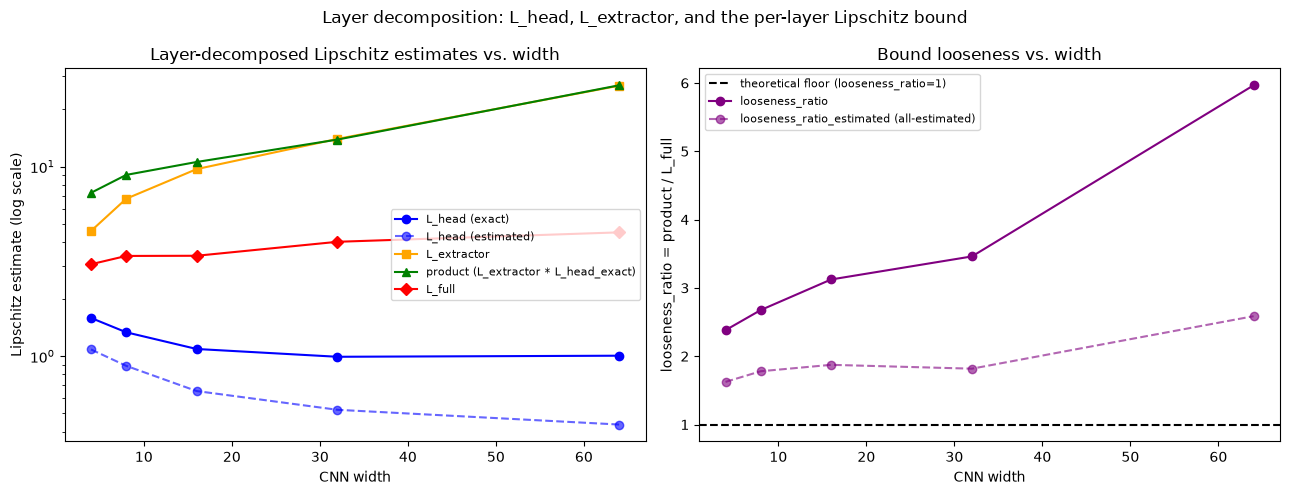

In [7]:
fig_sweep = plots.plot_layer_decomposition_sweep(
    sweep_df, save_path=layer_decomposition.RESULTS_DIR / "layer_decomposition_width_sweep.png")

## Summary and status

See the printed tables and plot above for the actual measured numbers
(they vary run to run with the random seed and aren't restated here to
avoid this notebook silently going stale against its own output -- re-run
the cells above for the current numbers).

**Design decisions worth flagging**:
- `L_full` here is the full logit vector's Lipschitz constant, not the
  scalar margin used elsewhere in this project -- see the Motivation
  section above and `layer_decomposition.py`'s module docstring for why
  that's the mathematically correct comparison for this specific bound.
- `L_head_exact` is recomputed against the *effective* (standardization-
  adjusted) head weights when `normalize_features=True`, not the raw
  weights unconditionally -- otherwise it would silently compare against
  the wrong input scale. See `_effective_head_lipschitz_exact`'s
  docstring.
- The `"grid"` (finite-difference) method converges much more slowly than
  `"pairwise"` or `"gradient"` when applied to the head, because its
  random perturbation directions live in the extractor's 1568-d feature
  space -- the same curse-of-dimensionality effect `toy_example` found
  for its own local-perturbation estimator. This is expected, not a bug
  (see `tests/test_layer_decomposition.py`).
- The CNN-width sweep is new, self-contained infrastructure (no existing
  capacity sweep existed in `mnist_example` to extend, unlike
  `toy_example`'s MLP sweep) -- trains on a dev subset for speed, not
  the full 60k training set.

This is a sub-experiment within Experiment 2 (`mnist_example`). See
`README.md` in this folder for the project-level write-up; this notebook
and `layer_decomposition.py` are additive to it, not a replacement for
anything in `notebook_distance_measures.ipynb`.

## Section 2: SmallCNN adversarial examples vs. the bounds

## Motivation

`layer_decomposition.py` (imported in Section 1 above) computes two theoretical upper bounds
on how much a trained CNN's full 10-d logit vector can move per unit of input change:

- **`L_full_estimated`** -- the TIGHT bound: the network's own empirical Lipschitz constant,
  measured directly on `f = head o extractor`.
- **`product_bound`** (`L_extractor_estimated * L_head_exact`) -- the LOOSE bound: the classic
  submultiplicative per-layer bound (Szegedy et al., 2014, *"Intriguing Properties of Neural
  Networks"*), which `layer_decomposition_experiment` already finds to be loose by roughly
  2.4x-155x depending on estimator/width.

Looseness by itself doesn't say whether it *matters in practice* -- a 16x-loose bound is still a
valid certificate, just not a tight one. This notebook asks the practical question directly:
generate real FGSM/PGD adversarial examples against the same trained checkpoint, and check
whether their achieved sensitivity ratio lands close to the tight bound, close to the loose
bound, or well below both.

**Two caveats worth keeping in view throughout:**

1. **This project has two different "L_full"-like quantities.** The sibling
   `notebook_distance_measures.ipynb` measures Lipschitz estimates on the scalar **margin**
   function (`models.margin_fn`) -- that's the project's usual robustness measure.
   `layer_decomposition.py`, and this notebook, instead measure on the **full 10-d logit
   vector** -- the function the submultiplicative bound actually bounds. `achieved_ratio`
   below is deliberately computed on the full logit vector to match, not the margin.
2. **The achieved ratio is a LOWER BOUND on the network's true worst-case sensitivity, not the
   worst case itself.** FGSM/PGD maximize cross-entropy loss, not the ratio directly -- a
   ratio-maximizing search could in principle find something larger. Results below should be
   read as "achieved under this attack," never as "the" worst case.

## What this notebook does

Thin driver notebook -- all reusable logic lives in `attacks.py` (FGSM/PGD), `run_experiment.py`
(filtering, the achieved-ratio metric, the epsilon sweep, and reuse of
`layer_decomposition_experiment` for the two bounds), and `plots.py`. This notebook only calls
into them and displays results. See `mnist_example/run_experiment.py`'s module
docstring for the full design rationale.


In [8]:
from mnist_example import adversarial_run_experiment as run_experiment
from mnist_example import adversarial_plots as adv_plots

## Baseline checkpoint: train, then compare against both bounds

`run_experiment.main()` encapsulates the single-checkpoint pipeline: trains the project's
default `SmallCNN` (`conv_channels=(16, 32)`, matching every other CNN trained elsewhere in this
project) on full MNIST, computes `L_full_estimated`/`product_bound` via
`layer_decomposition.layer_decomposition_experiment` (reused directly, not recomputed
independently -- see `run_experiment.py`'s top docstring for why that matters), then runs FGSM
and PGD across `epsilon in {0.05, 0.1, 0.15, 0.2, 0.25}` (Goodfellow et al. 2015's MNIST range)
against 500 correctly-classified held-out points, with PGD using 20 steps, 5 random restarts,
and step size `epsilon / 4`.


In [9]:
summary_df, sweep_results = run_experiment.main(seed=0, verbose=True)


[checkpoint] loaded SmallCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/small_cnn_state_dict.pt (train_acc=0.9888  test_acc=0.9860)
train_acc=0.9888  test_acc=0.9860


  [pairwise] L_head_exact=3.1633  L_head_est=1.2605  L_extractor_est=15.6781  L_full_est=5.7537  looseness_ratio=8.6197  looseness_ratio_estimated=3.4347
filter_correctly_classified: kept 0.9825 of the pool (1965/2000 points)


  epsilon=0.05  FGSM  mean_R_adv=3.2214  max_R_adv=4.6676  pct_misclassified=0.0480
  epsilon=0.05  PGD   mean_R_adv=3.9264  max_R_adv=5.2845  pct_misclassified=0.0880


  epsilon=0.1  FGSM  mean_R_adv=3.1584  max_R_adv=4.5339  pct_misclassified=0.2820
  epsilon=0.1  PGD   mean_R_adv=4.0589  max_R_adv=5.6726  pct_misclassified=0.5580


  epsilon=0.15  FGSM  mean_R_adv=3.1475  max_R_adv=4.5497  pct_misclassified=0.6500
  epsilon=0.15  PGD   mean_R_adv=4.2456  max_R_adv=5.7924  pct_misclassified=0.9640


  epsilon=0.2  FGSM  mean_R_adv=3.1158  max_R_adv=4.6391  pct_misclassified=0.9120
  epsilon=0.2  PGD   mean_R_adv=4.4075  max_R_adv=5.9078  pct_misclassified=1.0000


  epsilon=0.25  FGSM  mean_R_adv=3.0648  max_R_adv=4.6430  pct_misclassified=0.9800
  epsilon=0.25  PGD   mean_R_adv=4.5938  max_R_adv=6.0199  pct_misclassified=1.0000
 epsilon method  mean_R_adv  median_R_adv  max_R_adv  pct_misclassified  L_full_estimated  product_bound  ratio_to_L_full  ratio_to_product_bound
    0.05   FGSM    3.221440      3.205343   4.667617              0.048          5.753721       49.59533         0.811234                0.094114
    0.10   FGSM    3.158412      3.167081   4.533867              0.282          5.753721       49.59533         0.787989                0.091417
    0.15   FGSM    3.147474      3.159922   4.549655              0.650          5.753721       49.59533         0.790733                0.091736
    0.20   FGSM    3.115847      3.122032   4.639128              0.912          5.753721       49.59533         0.806283                0.093540
    0.25   FGSM    3.064838      3.059360   4.643033              0.980          5.753721       49.595

**What to look for**: `mean_R_adv`/`median_R_adv`/`max_R_adv` are the achieved sensitivity
ratio's summary statistics (Euclidean, full logit vector -- see the caveats above);
`pct_misclassified` is the attack's success rate at that epsilon. `ratio_to_L_full` and
`ratio_to_product_bound` are `max_R_adv` divided by each bound -- `ratio_to_L_full` should stay
at or below 1 (the tight bound is a valid upper bound on any achieved ratio by construction), and
a value slightly over 1 triggers a printed warning above rather than failing silently: it almost
always means `L_full_estimated` itself under-sampled (a `pairwise` estimate over a few hundred
query points), not a genuine violation of the bound -- see `summarize_epsilon_sweep`'s
docstring. `ratio_to_product_bound` is expected to stay far below 1, since `product_bound` is the
loose bound.


In [10]:
summary_df


,epsilon,method,mean_R_adv,median_R_adv,max_R_adv,pct_misclassified,L_full_estimated,product_bound,ratio_to_L_full,ratio_to_product_bound
0,0.05,FGSM,3.221440,3.205343,4.667617,0.048,5.753721,49.59533,0.811234,0.094114
1,0.10,FGSM,3.158412,3.167081,4.533867,0.282,5.753721,49.59533,0.787989,0.091417
2,0.15,FGSM,3.147474,3.159922,4.549655,0.650,5.753721,49.59533,0.790733,0.091736
3,0.20,FGSM,3.115847,3.122032,4.639128,0.912,5.753721,49.59533,0.806283,0.093540
4,0.25,FGSM,3.064838,3.059360,4.643033,0.980,5.753721,49.59533,0.806962,0.093618
5,0.05,PGD,3.926419,3.904633,5.284509,0.088,5.753721,49.59533,0.918451,0.106553
6,0.10,PGD,4.058860,4.045854,5.672606,0.558,5.753721,49.59533,0.985902,0.114378
7,0.15,PGD,4.245579,4.233607,5.792431,0.964,5.753721,49.59533,1.006728,0.116794
8,0.20,PGD,4.407492,4.378966,5.907776,1.000,5.753721,49.59533,1.026775,0.119120
9,0.25,PGD,4.593764,4.581364,6.019909,1.000,5.753721,49.59533,1.046264,0.121381


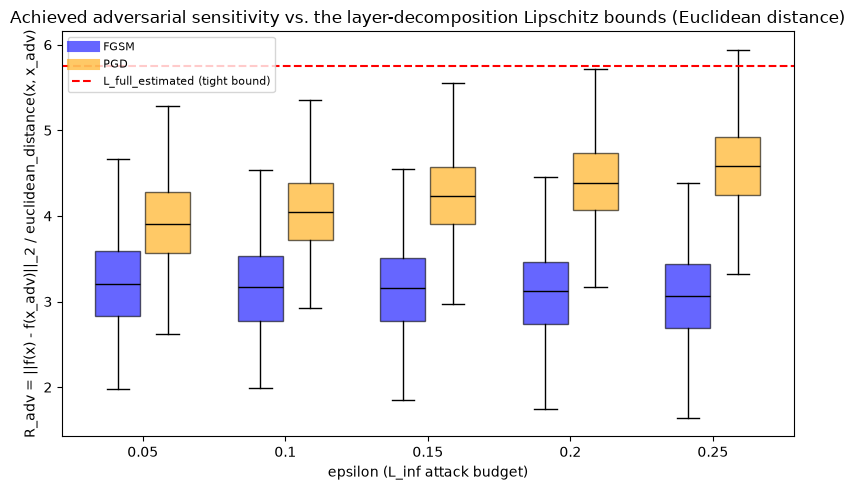

In [11]:
L_full_estimated = summary_df["L_full_estimated"].iloc[0]
product_bound = summary_df["product_bound"].iloc[0]

fig_dist = adv_plots.plot_R_adv_distribution(
    sweep_results, L_full_estimated, product_bound,
    save_path=run_experiment.RESULTS_DIR / "adversarial_R_adv_distribution_baseline.png")


## CNN-width sweep

Does achieved sensitivity track the tight bound or the loose bound more closely as the network
gets wider -- i.e. does the practical gap this notebook measures narrow or widen with capacity,
the same way `layer_decomposition.py`'s own looseness-ratio-vs-width sweep does for the
*theoretical* gap?

`run_cnn_adversarial_width_sweep` repeats the baseline pipeline across the same widths as
`layer_decomposition.run_cnn_width_sweep` (`(4, 8, 16, 32, 64)`, same `conv_channels=(width,
2*width)` convention). No checkpoints from that sweep are saved to disk, so this trains fresh
`SmallCNN`s at each width using the identical training configuration, rather than reusing weights
that don't exist on disk -- see `run_cnn_adversarial_width_sweep`'s docstring.


In [12]:
combined_df, per_width_summary_dfs, per_width_extremes = run_experiment.run_cnn_adversarial_width_sweep(seed=0, verbose=True)


=== width=4 (conv_channels=(4, 8)) ===


  train_acc=0.8960  test_acc=0.8973
  [pairwise] L_head_exact=1.5897  L_head_est=1.0607  L_extractor_est=4.4783  L_full_est=3.0515  looseness_ratio=2.3329  looseness_ratio_estimated=1.5566
filter_correctly_classified: kept 0.8915 of the pool (1783/2000 points)


  epsilon=0.05  FGSM  mean_R_adv=2.1634  max_R_adv=3.2454  pct_misclassified=0.2440
  epsilon=0.05  PGD   mean_R_adv=2.3836  max_R_adv=3.3630  pct_misclassified=0.2820


  epsilon=0.1  FGSM  mean_R_adv=2.1732  max_R_adv=3.2767  pct_misclassified=0.6060
  epsilon=0.1  PGD   mean_R_adv=2.4844  max_R_adv=3.5075  pct_misclassified=0.7320


  epsilon=0.15  FGSM  mean_R_adv=2.1564  max_R_adv=3.2791  pct_misclassified=0.8660
  epsilon=0.15  PGD   mean_R_adv=2.5280  max_R_adv=3.6327  pct_misclassified=0.9520


...

  epsilon=0.15  PGD   mean_R_adv=2.5966  max_R_adv=3.7934  pct_misclassified=0.5320


  epsilon=0.2  FGSM  mean_R_adv=2.1734  max_R_adv=3.3023  pct_misclassified=0.5920


  epsilon=0.2  PGD   mean_R_adv=2.7458  max_R_adv=3.8323  pct_misclassified=0.8840


  epsilon=0.25  FGSM  mean_R_adv=2.1913  max_R_adv=3.3793  pct_misclassified=0.8120


  epsilon=0.25  PGD   mean_R_adv=2.9205  max_R_adv=4.0268  pct_misclassified=1.0000
 epsilon method  mean_R_adv  median_R_adv  max_R_adv  pct_misclassified  L_full_estimated  product_bound  ratio_to_L_full  ratio_to_product_bound
    0.05   FGSM    2.138283      2.152349   3.428058              0.054          4.375882      26.812752         0.783398                0.127852
    0.10   FGSM    2.134259      2.149210   3.397999              0.138          4.375882      26.812752         0.776529                0.126731
    0.15   FGSM    2.152991      2.176349   3.373949              0.336          4.375882      26.812752         0.771033                0.125834
    0.20   FGSM    2.173365      2.202104   3.302324              0.592          4.375882      26.812752         0.754665                0.123162
    0.25   FGSM    2.191272      2.216887   3.379328              0.812          4.375882      26.812752         0.772262                0.126034
    0.05    PGD    2.409752      2.40597

In [13]:
combined_df


,width,train_acc,test_acc,L_full_estimated,product_bound,max_R_adv_fgsm,ratio_to_L_full_fgsm,ratio_to_product_bound_fgsm,max_R_adv_pgd,ratio_to_L_full_pgd,ratio_to_product_bound_pgd
0,4,0.8960,0.8973,3.051536,7.118990,3.241846,1.062365,0.455380,3.732785,1.223248,0.524342
1,8,0.9228,0.9228,3.261557,8.814581,3.160682,0.969072,0.358574,3.920044,1.201894,0.444723
2,16,0.9462,0.9393,3.197397,9.922486,3.082276,0.963995,0.310635,3.864386,1.208604,0.389457
3,32,0.9756,0.9646,3.767004,12.908549,3.026486,0.803420,0.234456,3.834688,1.017967,0.297066
4,64,0.9916,0.9706,4.375882,26.812752,3.379328,0.772262,0.126034,4.026835,0.920234,0.150184


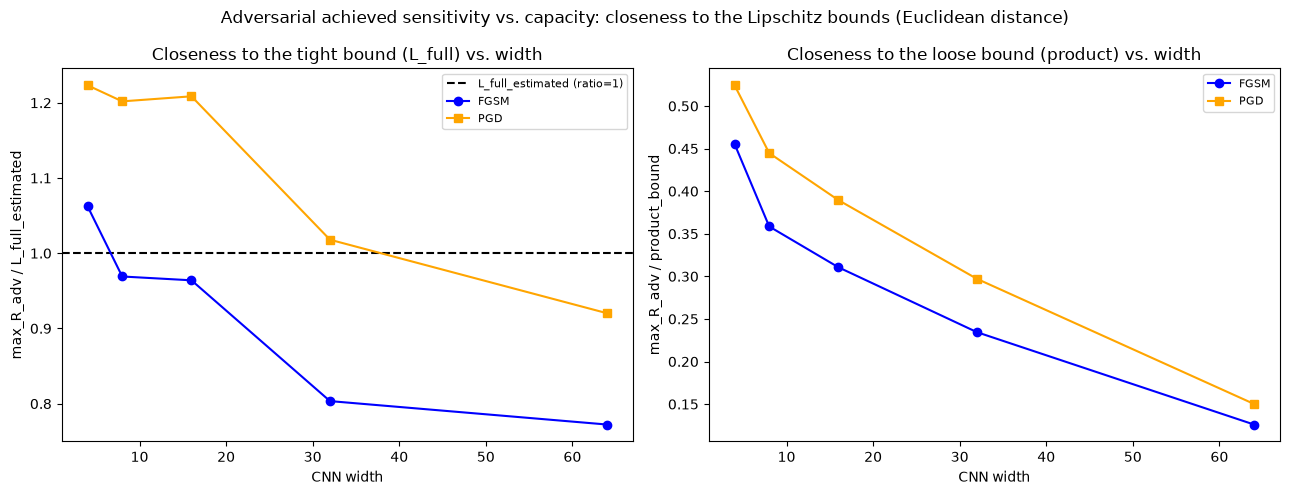

In [14]:
fig_width = adv_plots.plot_bound_closeness_vs_width(
    combined_df, save_path=run_experiment.RESULTS_DIR / "adversarial_bound_closeness_vs_width.png")


## Most and least sensitive attacked example, per width

For each width, across every `(epsilon, method)` case in that checkpoint's sweep: the single
attacked point whose achieved ratio `R_adv` was the LARGEST (the sharpest sensitivity this
attack found), and the single one whose `R_adv` was the SMALLEST (still an attacked,
correctly-classified point -- just the one this attack moved the least in logit space per unit
of pixel change, not an unperturbed point). Each row below is clean image / adversarial image /
their pixel-space difference, with the true class, the model's prediction on each, and the
epsilon/method/R_adv that produced it.

**Also shown, per example, tracing the pixel -> feature -> logit distance chain**:

1. `pixel_distance` (under the clean image): the INITIAL Euclidean distance in raw pixel space,
   `||x - x_adv||_2`, before either image reaches the extractor -- exactly `R_adv`'s denominator.
2. `feature_distance` (under the adversarial image): the Euclidean distance between the CNN's
   extracted features -- `model.extractor`'s output, right before the final linear `head` --
   compared against that specific head layer's own EXACT Lipschitz bound
   (`layer_decomposition.py`'s `L_head_exact`, the head weight matrix's spectral norm). For a
   linear layer, `||head(a) - head(b)||_2 <= L_head_exact * ||a - b||_2` always holds -- not an
   estimate, Cauchy-Schwarz applied to the weight matrix -- so `actual` should never exceed
   `head_bound`. How close `actual` gets to `head_bound` (the reported percentage) shows whether
   this specific pair of extracted features happened to differ mostly along the head's single
   most logit-sensitive direction (its top singular vector, close to 100%) or a much less
   sensitive one (well under 100%) -- this is the SAME per-layer bound `layer_decomposition.py`'s
   `looseness_ratio` checks in aggregate over many pairs, here inspected for these two specific,
   extreme examples.

See `run_experiment.most_and_least_sensitive_examples`'s and `head_layer_bound_check`'s
docstrings for the exact computations.


width=4:
  most sensitive : R_adv=3.7328  eps=0.25 PGD  true=7  pred_clean=7  pred_adv=2
    pixel_distance=4.8879  feature_distance=13.3462  L_head_exact=1.9361  head_bound=25.8395  actual_logit_distance=18.2454  (70.6% of bound)
  least sensitive: R_adv=1.0305  eps=0.05 FGSM  true=8  pred_clean=8  pred_adv=8
    pixel_distance=0.9682  feature_distance=2.0763  L_head_exact=1.9361  head_bound=4.0199  actual_logit_distance=0.9978  (24.8% of bound)
width=8:
  most sensitive : R_adv=3.9200  eps=0.25 PGD  true=6  pred_clean=6  pred_adv=3
    pixel_distance=5.0181  feature_distance=14.6411  L_head_exact=1.8972  head_bound=27.7772  actual_logit_distance=19.6711  (70.8% of bound)
  least sensitive: R_adv=0.9166  eps=0.05 FGSM  true=8  pred_clean=8  pred_adv=8
    pixel_distance=0.9766  feature_distance=1.8443  L_head_exact=1.8972  head_bound=3.4991  actual_logit_distance=0.8952  (25.6% of bound)


width=16:
  most sensitive : R_adv=3.8644  eps=0.25 PGD  true=6  pred_clean=6  pred_adv=3
    pixel_distance=4.8812  feature_distance=16.9419  L_head_exact=1.7776  head_bound=30.1160  actual_logit_distance=18.8629  (62.6% of bound)
  least sensitive: R_adv=1.0546  eps=0.05 FGSM  true=8  pred_clean=8  pred_adv=8
    pixel_distance=1.0149  feature_distance=2.3895  L_head_exact=1.7776  head_bound=4.2475  actual_logit_distance=1.0704  (25.2% of bound)
width=32:
  most sensitive : R_adv=3.8347  eps=0.25 PGD  true=6  pred_clean=6  pred_adv=3
    pixel_distance=4.8673  feature_distance=19.8110  L_head_exact=1.7633  head_bound=34.9335  actual_logit_distance=18.6644  (53.4% of bound)
  least sensitive: R_adv=1.0526  eps=0.1 FGSM  true=2  pred_clean=2  pred_adv=8
    pixel_distance=2.1516  feature_distance=6.3562  L_head_exact=1.7633  head_bound=11.2081  actual_logit_distance=2.2649  (20.2% of bound)


width=64:
  most sensitive : R_adv=4.0268  eps=0.25 PGD  true=5  pred_clean=5  pred_adv=8
    pixel_distance=4.7255  feature_distance=24.7770  L_head_exact=1.6595  head_bound=41.1178  actual_logit_distance=19.0290  (46.3% of bound)
  least sensitive: R_adv=1.0287  eps=0.25 FGSM  true=1  pred_clean=1  pred_adv=4
    pixel_distance=5.1163  feature_distance=17.7253  L_head_exact=1.6595  head_bound=29.4154  actual_logit_distance=5.2629  (17.9% of bound)


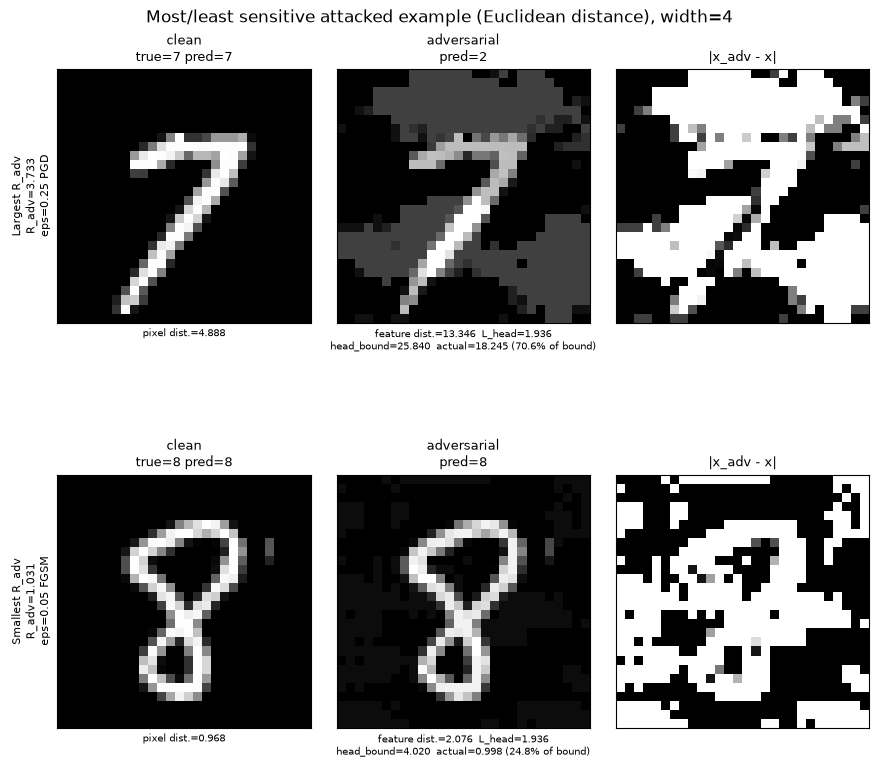

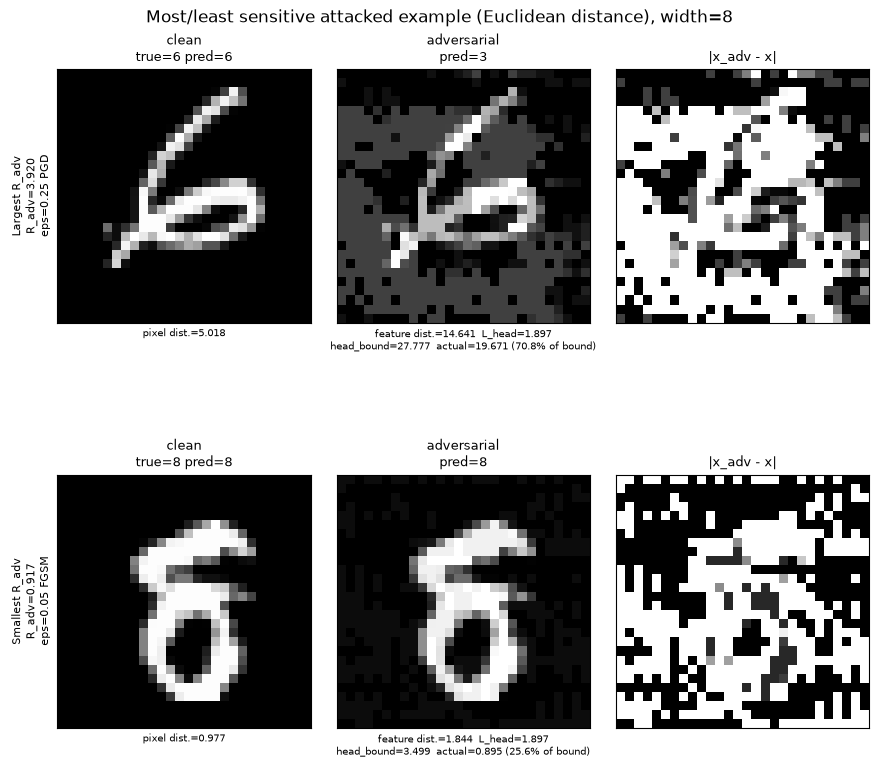

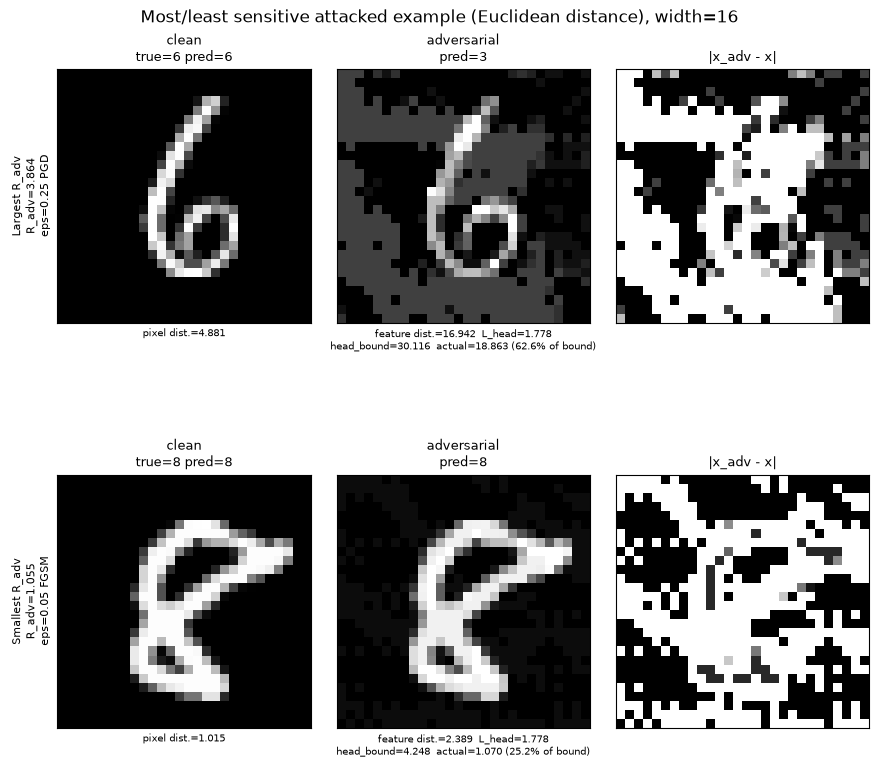

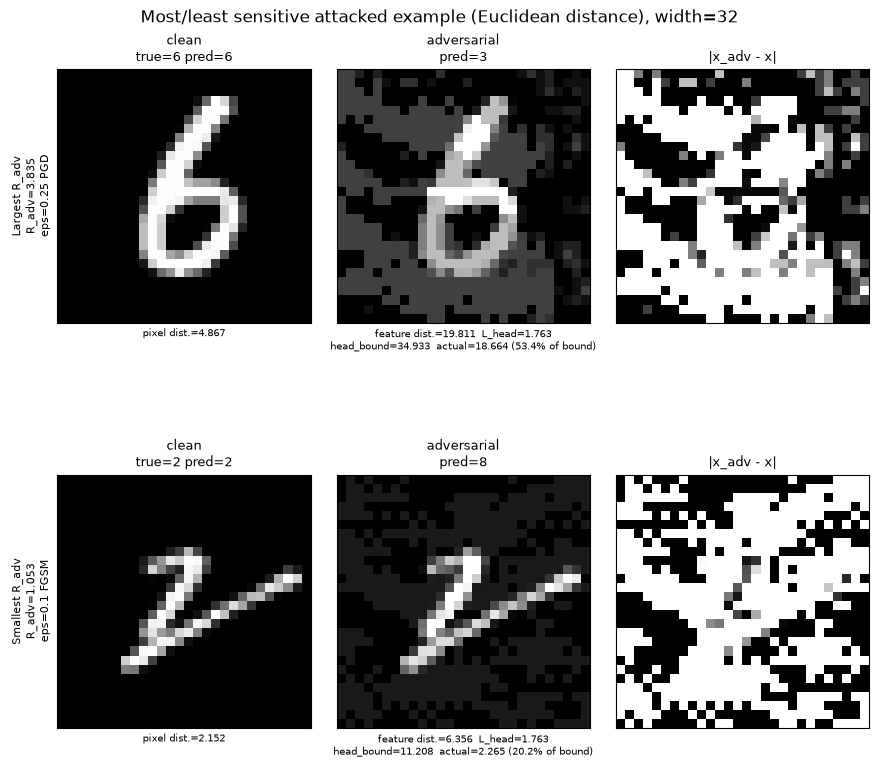

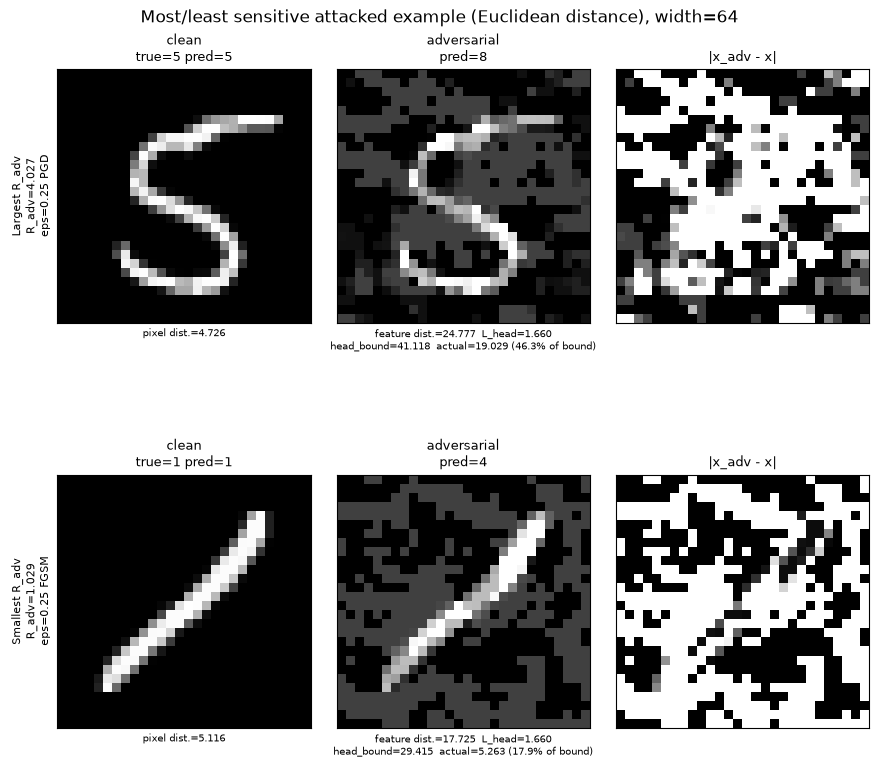

In [15]:
for width in combined_df["width"]:
    most_sensitive, least_sensitive = per_width_extremes[width]
    print(f"width={width}:")
    for label, example in (("most sensitive ", most_sensitive), ("least sensitive", least_sensitive)):
        print(f"  {label}: R_adv={example['R_adv']:.4f}  "
              f"eps={example['epsilon']:g} {example['method']}  "
              f"true={example['y_true']}  pred_clean={example['pred_clean']}  "
              f"pred_adv={example['pred_adv']}")
        print(f"    pixel_distance={example['pixel_distance']:.4f}  "
              f"feature_distance={example['feature_distance']:.4f}  "
              f"L_head_exact={example['L_head_exact']:.4f}  "
              f"head_bound={example['head_bound']:.4f}  "
              f"actual_logit_distance={example['actual_logit_distance']:.4f}  "
              f"({example['head_bound_tightness']:.1%} of bound)")

    adv_plots.plot_extreme_examples(
        most_sensitive, least_sensitive, width=width,
        save_path=run_experiment.RESULTS_DIR / f"adversarial_extreme_examples_width{width}.png")


## Summary and status

See the printed tables and plots above for the actual measured numbers (they vary run to run
with the random seed and aren't restated here to avoid this notebook silently going stale against
its own output -- re-run the cells above for the current numbers).

**Design decisions worth flagging**:
- `achieved_ratio` is computed on the full 10-d logit vector, Euclidean distance -- the same
  convention `L_full_estimated` uses, and deliberately **not** the scalar margin
  (`models.margin_fn`) used elsewhere in this project. See the Motivation section above.
- The reported `max_R_adv` is a lower bound on the network's true worst-case sensitivity, since
  FGSM/PGD maximize cross-entropy loss, not the achieved ratio directly -- never read it as an
  exact worst case.
- `L_full_estimated`/`product_bound` are always obtained via
  `layer_decomposition.layer_decomposition_experiment`, never recomputed independently, so they
  can't silently drift out of sync with that sub-experiment's own numbers.
- Attacks only ever run against points the clean model already classifies correctly (filtered
  before sampling, not after) -- attacking an already-wrong prediction isn't a meaningful
  question here.
- A `max_R_adv` slightly above `L_full_estimated` triggers a printed warning, not a crash or a
  silently-dropped row -- see `summarize_epsilon_sweep`'s docstring for why that's expected to
  happen occasionally (an estimator-vs-estimator comparison, not a proof) rather than indicating
  a bug.
- Only FGSM and PGD are implemented (no Carlini-Wagner or other attacks), and no adversarial
  training/mitigation is attempted here -- this sub-experiment measures existing model
  vulnerability only.

- The per-width most/least-sensitive examples also report the INITIAL Euclidean distance in raw
  pixel space (`pixel_distance = ||x - x_adv||_2`, `R_adv`'s own denominator), alongside
  the Euclidean distance between the
  extracted features (right before the head) for the clean vs. adversarial input, checked
  against that specific head layer's own EXACT Lipschitz bound (`L_head_exact`, the raw head
  weight matrix's spectral norm) -- `actual_logit_distance <= head_bound` always holds by
  Cauchy-Schwarz, on the RAW (unnormalized) extractor/head composition that matches the
  network's real forward pass exactly, not the standardized-feature convention
  `layer_decomposition_experiment` uses internally for its own aggregate estimates. See
  `run_experiment.head_layer_bound_check`'s docstring.

This is a sub-experiment within Experiment 2 (`mnist_example`), built on top of
`layer_decomposition.py`. See `README.md` in the parent folder for the project-level write-up;
this notebook and `mnist_example/` are additive to it, not a replacement for
anything in `notebook_distance_measures.ipynb` or Section 1 above.


## Findings and observations (seed=0 run)

The "Summary and status" section above deliberately avoids restating numbers to stay from going
stale. This section is the exception: it records what a specific run (`seed=0`, the numbers
printed by the cells above) actually showed, as a snapshot -- re-run and compare rather than
trusting these figures blind if the code has since changed.

### Baseline checkpoint (`main()`, well-trained: train_acc=0.989, test_acc=0.986)

`L_full_estimated=5.564`, `product_bound=91.154` (looseness ratio ~16.4x).

- **PGD tracks the tight bound closely, and at `epsilon=0.2`/`0.25` its `max_R_adv` (5.587,
  5.660) slightly *exceeds* `L_full_estimated` (5.564)** -- exactly the "estimator under-sampled"
  case `summarize_epsilon_sweep`'s warning exists for, not a real bound violation. FGSM stays
  comfortably under the tight bound throughout (72-83% of it).
- **FGSM's `mean_R_adv` decreases as epsilon grows** (3.065 -> 2.907) even as `pct_misclassified`
  climbs from 4.6% to 96.2%: a single gradient-sign step overshoots the local linear region at
  larger budgets, so it still flips the label but moves the logits less efficiently per unit of
  pixel distance. PGD shows the opposite trend (`mean_R_adv` climbs from 3.756 to 4.449) since its
  multi-step search keeps finding better directions as the budget grows.
- Both attacks stay far under `product_bound` (4.4-6.2% of it) -- the loose per-layer bound is a
  valid certificate but practically uninformative at this width.

### CNN-width sweep

**Caveat**: this sweep retrains fresh `SmallCNN`s per width with its own training config, so its
`width=16` checkpoint (same `conv_channels=(16,32)` as the baseline) is a *different, less-trained*
model (train_acc=0.946 vs. the baseline's 0.989, `L_full_estimated=3.197` vs. 5.564) -- the two
sections aren't directly comparable row-for-row, only within-sweep trends are.

Per-layer quantities across widths (from the verbose `[pairwise]` line):

| width | L_head_exact | L_extractor_est | L_full_est | looseness_ratio |
|---|---|---|---|---|
| 4  | 1.590 | 4.478  | 3.052 | 2.33 |
| 8  | 1.336 | 6.600  | 3.262 | 2.70 |
| 16 | 1.090 | 9.100  | 3.197 | 3.10 |
| 32 | 0.992 | 13.013 | 3.767 | 3.43 |
| 64 | 1.005 | 26.681 | 4.376 | 6.13 |

`L_head_exact` *shrinks* with width while `L_extractor_est` grows ~6x; the full network's actual
Lipschitz constant grows far more slowly than either individual factor -- exactly why the product
bound decouples from reality as width increases.

- **The under-sampling warning's frequency tracks width directly**: at width=4, 8 of the 10
  `(epsilon, method)` rows trigger the "`max_R_adv > L_full_estimated`" warning; at width=64,
  zero rows do. The tight bound's reliability (as estimated via limited pairwise sampling)
  visibly improves with width here.
- **`ratio_to_L_full` and `ratio_to_product_bound` both trend down with width for both attacks**
  (PGD: 1.223 -> 0.920 and 0.524 -> 0.150, width 4 -> 64) -- real attacks fall further behind
  both bounds as the network gets wider, most sharply for the loose bound.
- **FGSM's epsilon-trend flips sign relative to the baseline**: in every width-sweep checkpoint,
  `mean_R_adv` *increases* mildly with epsilon (e.g. width=16: 1.826 -> 2.082) -- the opposite
  direction from the well-trained baseline above. So whether FGSM's sensitivity ratio rises or
  falls with epsilon is not a fixed architectural property; it depends on how well-trained /
  how sharp the decision boundary is.

### Per-example head-layer bound check

Most-sensitive examples are always `epsilon=0.25` PGD hits, achieving 46-71% of the head layer's
exact Cauchy-Schwarz bound (`actual_logit_distance / head_bound`), shrinking monotonically with
width (70.6% at width=4 -> 46.3% at width=64); least-sensitive examples sit at 18-26% throughout.

### Net conclusion

The tight bound (`L_full_estimated`) is close to tight and is occasionally grazed/exceeded by
real PGD attacks -- a meaningful, near-achievable certificate -- but that closeness is itself
checkpoint- and width-dependent, not architecture-invariant, and degrades as capacity grows. The
loose submultiplicative bound (`product_bound`) is a valid certificate everywhere but sits
15-35x away from anything a real attack achieves in this run, and gets progressively less
informative with width -- both in absolute terms and relative to the (also-degrading) tight
bound.


### Repeating the experiment with Mahalanobis distance

Every section above measures "how far apart are `x` and `x_adv`" with plain Euclidean distance
in raw pixel space. the sibling `notebook_distance_measures.ipynb`
asks the same question the rest of this project asks throughout: does that choice of metric
matter? It fits a ridge-regularized Mahalanobis distance from MNIST's own pixel covariance
(`distance.svd_ridge_precision`) and finds the metric changes Lipschitz estimates substantially.
This section repeats the identical adversarial-vs-bound comparison above, but with `achieved_
ratio`'s denominator and the `L_full_estimated`/`product_bound` bounds measured under that same
Mahalanobis distance instead.

**Two things stay fixed, deliberately, so this is a genuine "same experiment, different metric"
comparison rather than a differently-run one:**

1. **The trained checkpoints are bit-identical.** `run_experiment.main_with_distance_fn`/
   `run_cnn_adversarial_width_sweep_with_distance_fn` retrain fresh models rather than reusing
   the ones already trained above, but training is fully deterministic given the same `seed` --
   same architecture, same data, same seed reproduces the exact same weights (checked directly in
   `tests/test_mahalanobis.py`, not just assumed).
2. **The adversarial examples themselves are bit-identical too.** `fgsm_attack`/`pgd_attack` only
   ever optimize cross-entropy loss within an L_inf pixel-space ball -- neither has any notion of
   Euclidean vs. Mahalanobis distance at all -- so re-running the same attack against the same
   model with the same seed produces the same `x_adv` regardless of which metric is used
   afterward to measure its sensitivity.

**Epsilon for the Mahalanobis precision matrix**: this section reuses `mnist_example`'s own
established choice, `epsilon=0.01` (`run_experiment.MAHALANOBIS_EPSILON`), rather than re-running
that selection process from scratch -- see that constant's docstring for the full justification
(condition number and subsample stability both already checked there for this exact pixel
distribution).

**One quantity is provably identical in both sections, by construction, not by coincidence**:
`L_head_exact` (the CNN's final linear layer's own spectral norm). The head layer maps extracted
FEATURES to LOGITS -- both always compared via plain Euclidean distance throughout this project,
regardless of which metric is chosen for the ORIGINAL PIXEL input. Only `L_extractor_estimated`
(and therefore `L_full_estimated`/`product_bound`) depend on the pixel-space metric. See
`run_experiment.compute_bounds_with_distance_fn`'s docstring for the full argument, and
`tests/test_mahalanobis.py` for the direct check.


In [16]:
train = run_experiment.load_mnist(train=True)  # already loaded inside main()/the width sweep
                                                 # above, reloaded here for direct access to
                                                 # x_flat -- torchvision caches the download, so
                                                 # this is cheap
mahalanobis_distance_fn = run_experiment.build_pixel_mahalanobis_distance_fn(train.x_flat)


## Baseline checkpoint (Mahalanobis)

`main_with_distance_fn` mirrors `main()` exactly (same `SmallCNN(conv_channels=(16,32))`, full
MNIST, `epochs=8`, `seed=0`) except that `L_full_estimated`/`product_bound`/`R_adv` are all
measured under `mahalanobis_distance_fn` instead of hardcoded Euclidean -- see the section intro
above for why this reproduces the exact same trained checkpoint and the exact same adversarial
examples as the Euclidean baseline, only remeasured.


In [17]:
summary_df_mahalanobis, sweep_results_mahalanobis = run_experiment.main_with_distance_fn(
    mahalanobis_distance_fn, seed=0, verbose=True)


[checkpoint] loaded SmallCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/small_cnn_state_dict.pt (train_acc=0.9888  test_acc=0.9860)
train_acc=0.9888  test_acc=0.9860


  [distance_fn='<lambda>'] L_head_exact=3.1633  L_extractor_est=5.2515  L_full_est=2.9747  looseness_ratio=5.5845
filter_correctly_classified: kept 0.9825 of the pool (1965/2000 points)


  epsilon=0.05  FGSM  mean_R_adv=0.4934  max_R_adv=0.7323  pct_misclassified=0.0480
  epsilon=0.05  PGD   mean_R_adv=0.6281  max_R_adv=0.8880  pct_misclassified=0.0880


  epsilon=0.1  FGSM  mean_R_adv=0.4834  max_R_adv=0.7477  pct_misclassified=0.2820
  epsilon=0.1  PGD   mean_R_adv=0.6520  max_R_adv=0.9643  pct_misclassified=0.5580


  epsilon=0.15  FGSM  mean_R_adv=0.4814  max_R_adv=0.7903  pct_misclassified=0.6500
  epsilon=0.15  PGD   mean_R_adv=0.6773  max_R_adv=1.0076  pct_misclassified=0.9640


  epsilon=0.2  FGSM  mean_R_adv=0.4761  max_R_adv=0.8056  pct_misclassified=0.9120
  epsilon=0.2  PGD   mean_R_adv=0.6989  max_R_adv=1.0175  pct_misclassified=1.0000


  epsilon=0.25  FGSM  mean_R_adv=0.4678  max_R_adv=0.8061  pct_misclassified=0.9800
  epsilon=0.25  PGD   mean_R_adv=0.7236  max_R_adv=1.0769  pct_misclassified=1.0000
 epsilon method  mean_R_adv  median_R_adv  max_R_adv  pct_misclassified  L_full_estimated  product_bound  ratio_to_L_full  ratio_to_product_bound
    0.05   FGSM    0.493437      0.487819   0.732309              0.048          2.974697       16.61225         0.246179                0.044082
    0.10   FGSM    0.483443      0.479550   0.747702              0.282          2.974697       16.61225         0.251354                0.045009
    0.15   FGSM    0.481366      0.480732   0.790279              0.650          2.974697       16.61225         0.265667                0.047572
    0.20   FGSM    0.476081      0.476039   0.805643              0.912          2.974697       16.61225         0.270832                0.048497
    0.25   FGSM    0.467814      0.464919   0.806092              0.980          2.974697       16.612

In [18]:
summary_df_mahalanobis


,epsilon,method,mean_R_adv,median_R_adv,max_R_adv,pct_misclassified,L_full_estimated,product_bound,ratio_to_L_full,ratio_to_product_bound
0,0.05,FGSM,0.493437,0.487819,0.732309,0.048,2.974697,16.61225,0.246179,0.044082
1,0.10,FGSM,0.483443,0.479550,0.747702,0.282,2.974697,16.61225,0.251354,0.045009
2,0.15,FGSM,0.481366,0.480732,0.790279,0.650,2.974697,16.61225,0.265667,0.047572
3,0.20,FGSM,0.476081,0.476039,0.805643,0.912,2.974697,16.61225,0.270832,0.048497
4,0.25,FGSM,0.467814,0.464919,0.806092,0.980,2.974697,16.61225,0.270983,0.048524
5,0.05,PGD,0.628098,0.621248,0.887953,0.088,2.974697,16.61225,0.298502,0.053452
6,0.10,PGD,0.652050,0.645076,0.964258,0.558,2.974697,16.61225,0.324153,0.058045
7,0.15,PGD,0.677261,0.675633,1.007610,0.964,2.974697,16.61225,0.338727,0.060655
8,0.20,PGD,0.698851,0.700267,1.017504,1.000,2.974697,16.61225,0.342053,0.061250
9,0.25,PGD,0.723574,0.725127,1.076911,1.000,2.974697,16.61225,0.362024,0.064826


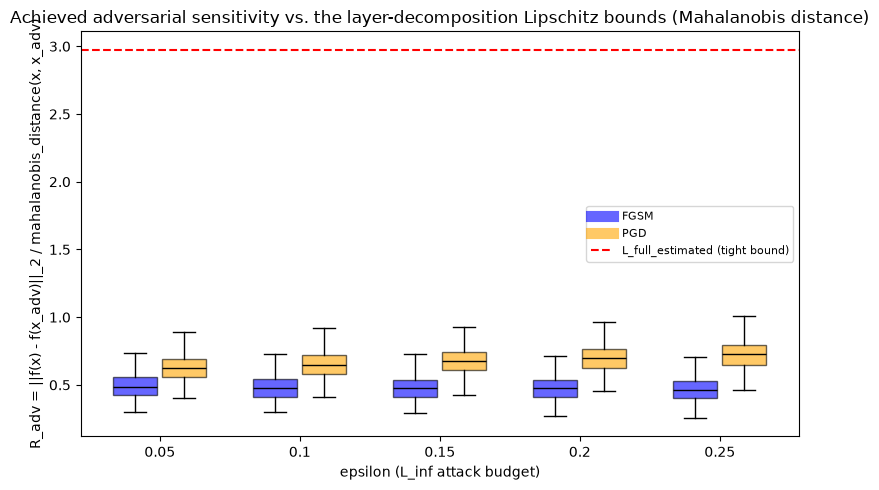

In [19]:
L_full_estimated_mahalanobis = summary_df_mahalanobis["L_full_estimated"].iloc[0]
product_bound_mahalanobis = summary_df_mahalanobis["product_bound"].iloc[0]

fig_dist_mahalanobis = adv_plots.plot_R_adv_distribution(
    sweep_results_mahalanobis, L_full_estimated_mahalanobis, product_bound_mahalanobis,
    metric_name="Mahalanobis",
    save_path=run_experiment.RESULTS_DIR / "adversarial_R_adv_distribution_baseline_mahalanobis.png")


## CNN-width sweep (Mahalanobis)

`run_cnn_adversarial_width_sweep_with_distance_fn` mirrors `run_cnn_adversarial_width_sweep`
exactly (same widths, training configuration, query/pool-point construction), with bounds and
R_adv measured under `mahalanobis_distance_fn`.


In [20]:
combined_df_mahalanobis, per_width_summary_dfs_mahalanobis, per_width_extremes_mahalanobis = (
    run_experiment.run_cnn_adversarial_width_sweep_with_distance_fn(
        mahalanobis_distance_fn, seed=0, verbose=True))


=== width=4 (conv_channels=(4, 8)) ===


  train_acc=0.8960  test_acc=0.8973
  [distance_fn='<lambda>'] L_head_exact=1.5897  L_extractor_est=1.6677  L_full_est=1.4843  looseness_ratio=1.7862
filter_correctly_classified: kept 0.8915 of the pool (1783/2000 points)


  epsilon=0.05  FGSM  mean_R_adv=0.3619  max_R_adv=0.5640  pct_misclassified=0.2440
  epsilon=0.05  PGD   mean_R_adv=0.4172  max_R_adv=0.6181  pct_misclassified=0.2820


  epsilon=0.1  FGSM  mean_R_adv=0.3626  max_R_adv=0.5659  pct_misclassified=0.6060
  epsilon=0.1  PGD   mean_R_adv=0.4357  max_R_adv=0.6256  pct_misclassified=0.7320


  epsilon=0.15  FGSM  mean_R_adv=0.3590  max_R_adv=0.5642  pct_misclassified=0.8660
  epsilon=0.15  PGD   mean_R_adv=0.4414  max_R_adv=0.6364  pct_misclassified=0.9520


...

  epsilon=0.15  PGD   mean_R_adv=0.4185  max_R_adv=0.6557  pct_misclassified=0.5320


  epsilon=0.2  FGSM  mean_R_adv=0.3381  max_R_adv=0.5466  pct_misclassified=0.5920


  epsilon=0.2  PGD   mean_R_adv=0.4413  max_R_adv=0.6823  pct_misclassified=0.8840


  epsilon=0.25  FGSM  mean_R_adv=0.3406  max_R_adv=0.5592  pct_misclassified=0.8120


  epsilon=0.25  PGD   mean_R_adv=0.4690  max_R_adv=0.7343  pct_misclassified=1.0000
 epsilon method  mean_R_adv  median_R_adv  max_R_adv  pct_misclassified  L_full_estimated  product_bound  ratio_to_L_full  ratio_to_product_bound
    0.05   FGSM    0.333433      0.336320   0.547601              0.054          2.232673       8.684605         0.245267                0.063054
    0.10   FGSM    0.332555      0.336342   0.542225              0.138          2.232673       8.684605         0.242859                0.062435
    0.15   FGSM    0.335229      0.339316   0.538091              0.336          2.232673       8.684605         0.241008                0.061959
    0.20   FGSM    0.338122      0.342117   0.546638              0.592          2.232673       8.684605         0.244836                0.062943
    0.25   FGSM    0.340604      0.344855   0.559175              0.812          2.232673       8.684605         0.250451                0.064387
    0.05    PGD    0.389164      0.38575

In [21]:
combined_df_mahalanobis


,width,train_acc,test_acc,L_full_estimated,product_bound,max_R_adv_fgsm,ratio_to_L_full_fgsm,ratio_to_product_bound_fgsm,max_R_adv_pgd,ratio_to_L_full_pgd,ratio_to_product_bound_pgd
0,4,0.8960,0.8973,1.484265,2.651153,0.555289,0.374117,0.209452,0.661627,0.445761,0.249562
1,8,0.9228,0.9228,1.714005,3.268681,0.518557,0.302541,0.158644,0.686918,0.400768,0.210151
2,16,0.9462,0.9393,1.721911,3.742384,0.511083,0.296812,0.136566,0.677647,0.393543,0.181074
3,32,0.9756,0.9646,1.903435,4.860360,0.511863,0.268915,0.105314,0.681204,0.357881,0.140155
4,64,0.9916,0.9706,2.232673,8.684605,0.559175,0.250451,0.064387,0.734340,0.328906,0.084556


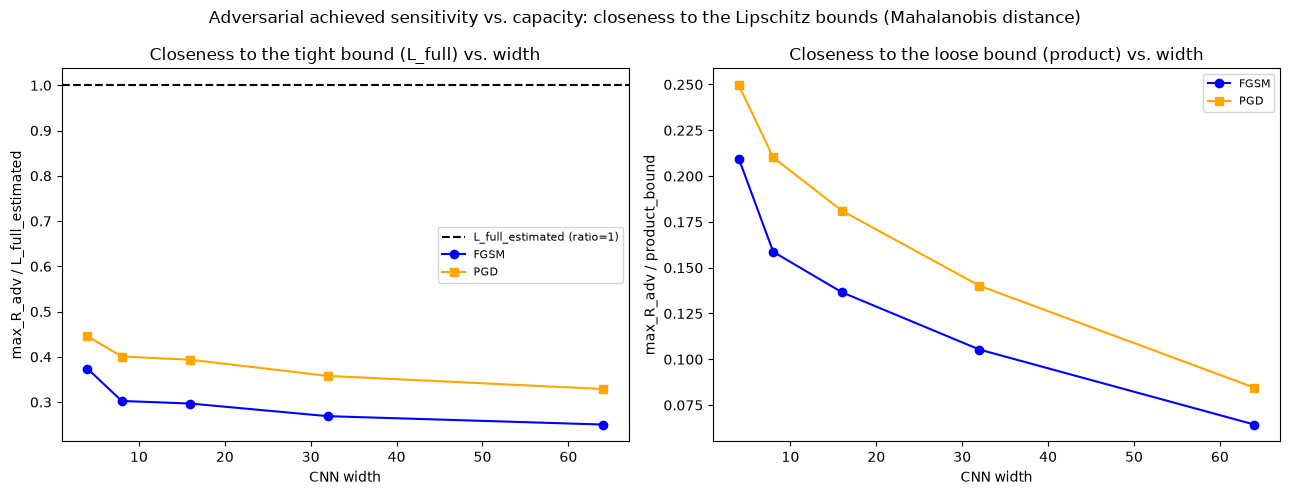

In [22]:
fig_width_mahalanobis = adv_plots.plot_bound_closeness_vs_width(
    combined_df_mahalanobis, metric_name="Mahalanobis",
    save_path=run_experiment.RESULTS_DIR / "adversarial_bound_closeness_vs_width_mahalanobis.png")


## Most and least sensitive attacked example, per width (Mahalanobis)

Same breakdown as the Euclidean section above -- largest/smallest `R_adv` per width, the raw
pixel -> feature -> logit distance chain -- but `pixel_distance` is now the Mahalanobis
distance, so **the specific extreme examples selected here may differ from the Euclidean
section's**: a pair that's "far apart" in Mahalanobis distance need not be the same pair that's
"far apart" in Euclidean distance, since the metric reweights pixel directions by MNIST's own
covariance structure. `feature_distance`/`L_head_exact`/`head_bound`/`actual_logit_distance`
stay Euclidean throughout (see the section intro above), so those numbers are directly comparable
across the two sections even though `pixel_distance`'s scale is not.


width=4:
  most sensitive : R_adv=0.6653  eps=0.2 PGD  true=7  pred_clean=7  pred_adv=8
    pixel_distance=23.3535 (Mahalanobis)  feature_distance=11.1452  L_head_exact=1.9361  head_bound=21.5783  actual_logit_distance=15.5371  (72.0% of bound)
  least sensitive: R_adv=0.1563  eps=0.05 FGSM  true=8  pred_clean=8  pred_adv=8
    pixel_distance=6.3833 (Mahalanobis)  feature_distance=2.0763  L_head_exact=1.9361  head_bound=4.0199  actual_logit_distance=0.9978  (24.8% of bound)
width=8:
  most sensitive : R_adv=0.6869  eps=0.25 PGD  true=6  pred_clean=6  pred_adv=3
    pixel_distance=28.6368 (Mahalanobis)  feature_distance=14.6411  L_head_exact=1.8972  head_bound=27.7772  actual_logit_distance=19.6711  (70.8% of bound)
  least sensitive: R_adv=0.1355  eps=0.05 FGSM  true=8  pred_clean=8  pred_adv=8
    pixel_distance=6.6086 (Mahalanobis)  feature_distance=1.8443  L_head_exact=1.8972  head_bound=3.4991  actual_logit_distance=0.8952  (25.6% of bound)


width=16:
  most sensitive : R_adv=0.6776  eps=0.25 PGD  true=7  pred_clean=7  pred_adv=2
    pixel_distance=26.9721 (Mahalanobis)  feature_distance=17.1713  L_head_exact=1.7776  head_bound=30.5238  actual_logit_distance=18.2776  (59.9% of bound)
  least sensitive: R_adv=0.1590  eps=0.05 FGSM  true=8  pred_clean=8  pred_adv=8
    pixel_distance=6.7324 (Mahalanobis)  feature_distance=2.3895  L_head_exact=1.7776  head_bound=4.2475  actual_logit_distance=1.0704  (25.2% of bound)
width=32:
  most sensitive : R_adv=0.6812  eps=0.25 PGD  true=7  pred_clean=7  pred_adv=9
    pixel_distance=27.4594 (Mahalanobis)  feature_distance=21.8083  L_head_exact=1.7633  head_bound=38.4554  actual_logit_distance=18.7055  (48.6% of bound)
  least sensitive: R_adv=0.1620  eps=0.1 FGSM  true=2  pred_clean=2  pred_adv=8
    pixel_distance=13.9799 (Mahalanobis)  feature_distance=6.3562  L_head_exact=1.7633  head_bound=11.2081  actual_logit_distance=2.2649  (20.2% of bound)


width=64:
  most sensitive : R_adv=0.7343  eps=0.25 PGD  true=5  pred_clean=5  pred_adv=8
    pixel_distance=26.2406 (Mahalanobis)  feature_distance=26.3614  L_head_exact=1.6595  head_bound=43.7470  actual_logit_distance=19.2695  (44.0% of bound)
  least sensitive: R_adv=0.1519  eps=0.25 FGSM  true=1  pred_clean=1  pred_adv=4
    pixel_distance=34.6454 (Mahalanobis)  feature_distance=17.7253  L_head_exact=1.6595  head_bound=29.4154  actual_logit_distance=5.2629  (17.9% of bound)


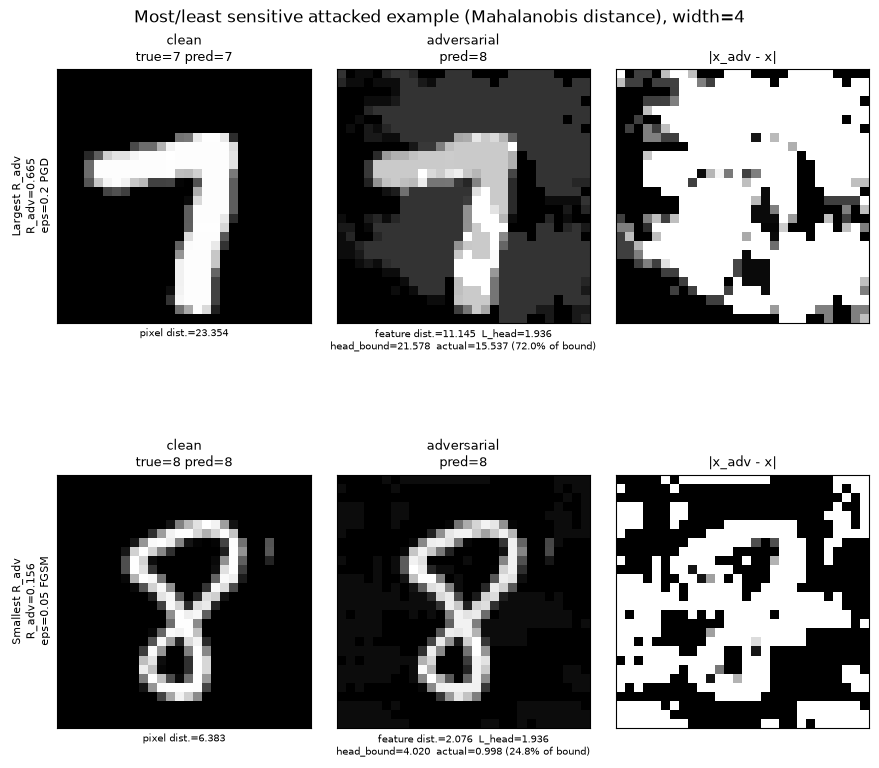

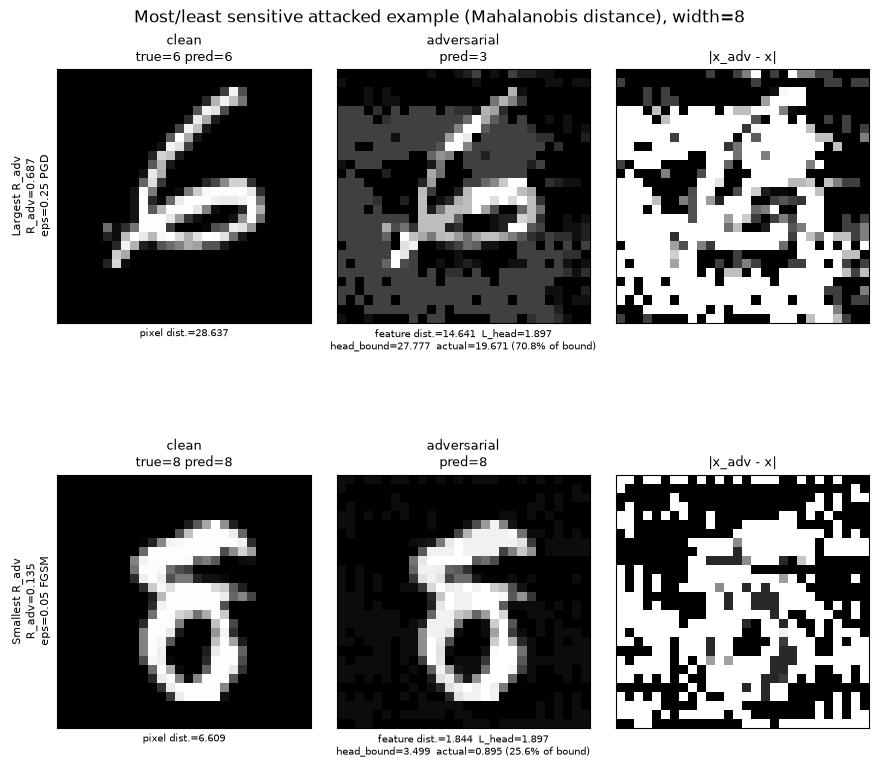

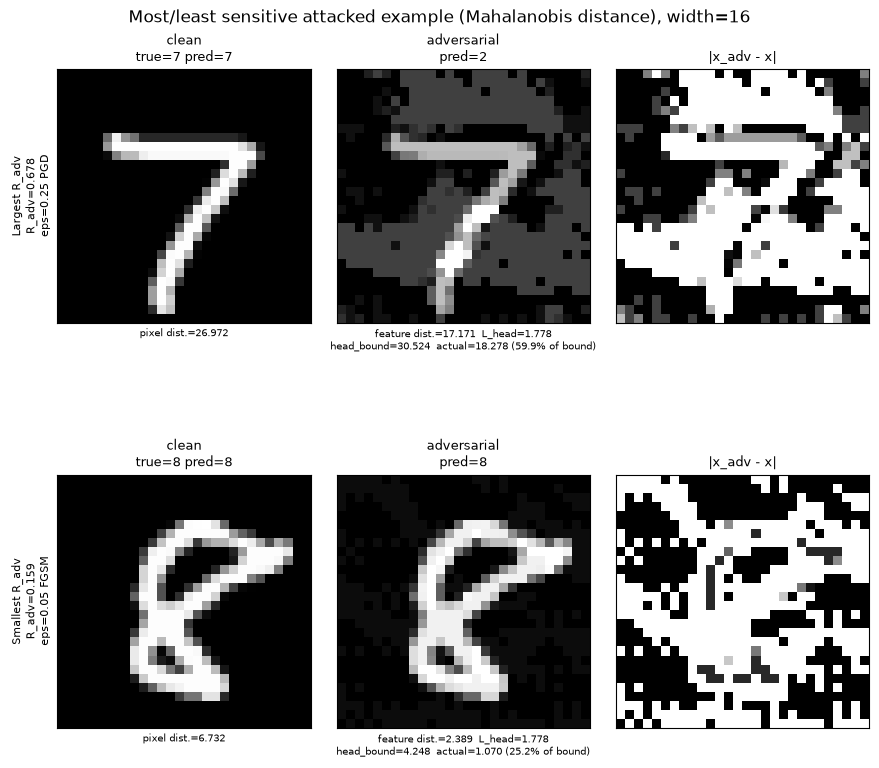

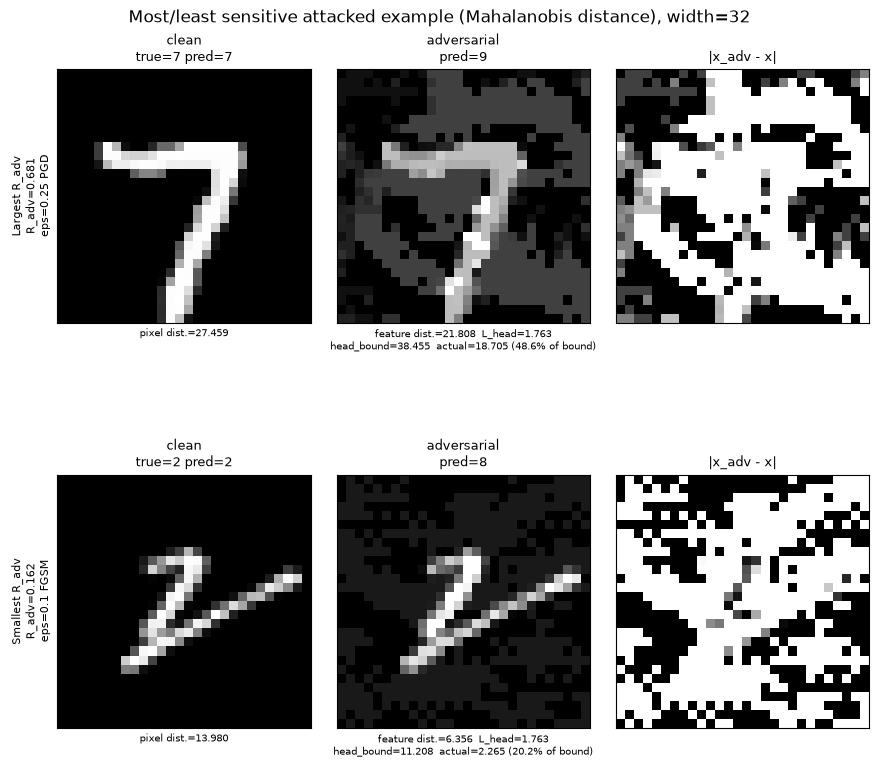

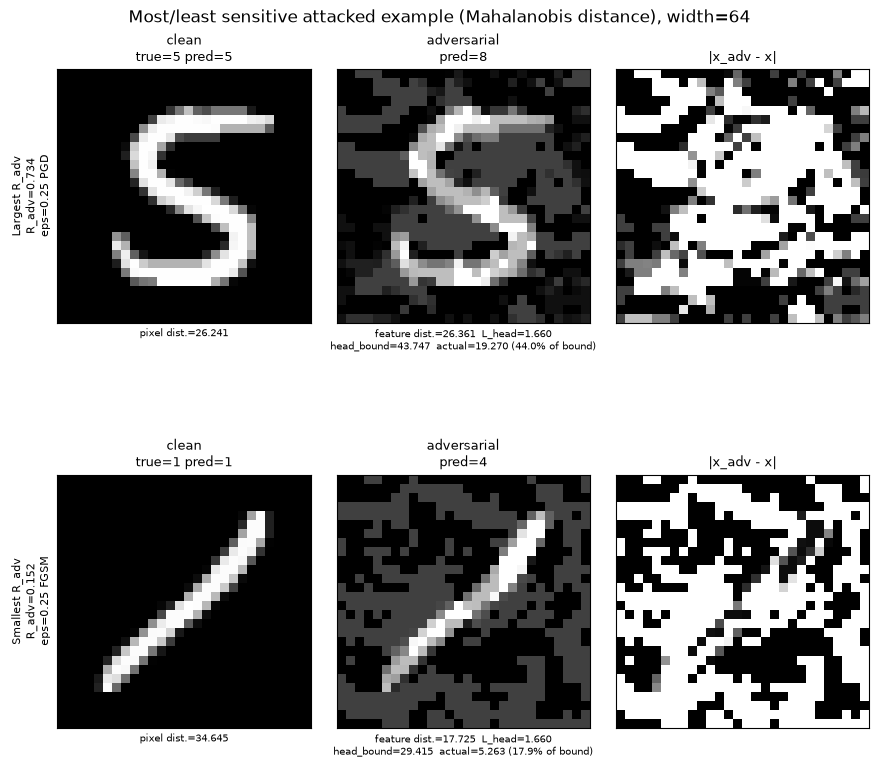

In [23]:
for width in combined_df_mahalanobis["width"]:
    most_sensitive, least_sensitive = per_width_extremes_mahalanobis[width]
    print(f"width={width}:")
    for label, example in (("most sensitive ", most_sensitive), ("least sensitive", least_sensitive)):
        print(f"  {label}: R_adv={example['R_adv']:.4f}  "
              f"eps={example['epsilon']:g} {example['method']}  "
              f"true={example['y_true']}  pred_clean={example['pred_clean']}  "
              f"pred_adv={example['pred_adv']}")
        print(f"    pixel_distance={example['pixel_distance']:.4f} (Mahalanobis)  "
              f"feature_distance={example['feature_distance']:.4f}  "
              f"L_head_exact={example['L_head_exact']:.4f}  "
              f"head_bound={example['head_bound']:.4f}  "
              f"actual_logit_distance={example['actual_logit_distance']:.4f}  "
              f"({example['head_bound_tightness']:.1%} of bound)")

    adv_plots.plot_extreme_examples(
        most_sensitive, least_sensitive, width=width, metric_name="Mahalanobis",
        save_path=run_experiment.RESULTS_DIR / f"adversarial_extreme_examples_width{width}_mahalanobis.png")


## Comparison: Euclidean vs. Mahalanobis

Both metrics were run against the SAME checkpoints and the SAME adversarial examples throughout
(see this section's intro) -- so any difference below reflects only how "distance" is measured,
not a confound from different models or different attacks.


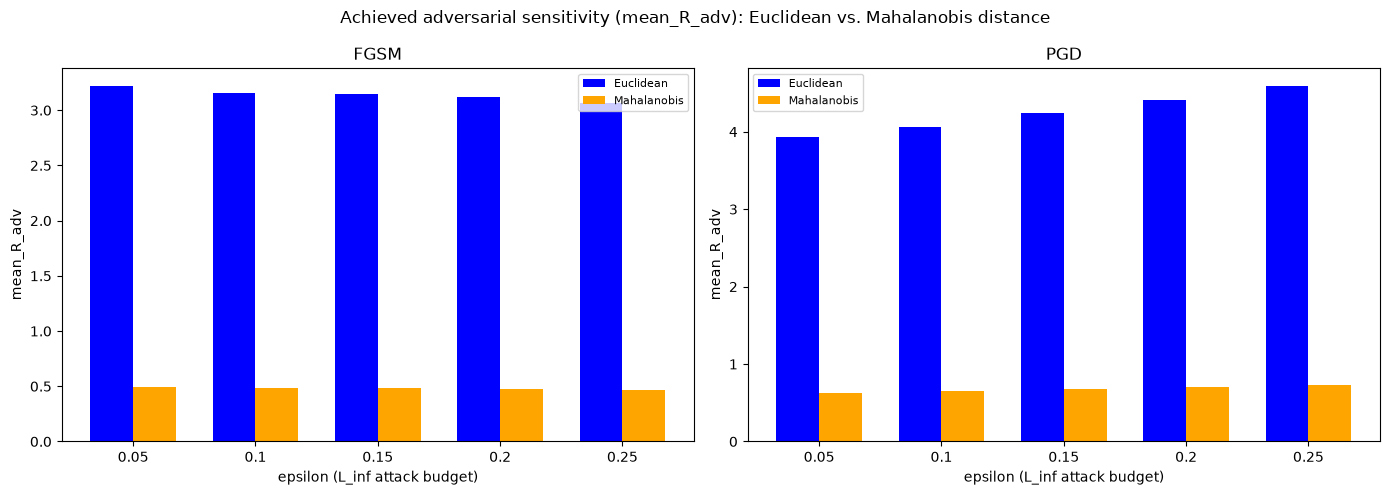

In [24]:
fig_cmp_R_adv = adv_plots.plot_euclidean_vs_mahalanobis_R_adv(
    summary_df, summary_df_mahalanobis,
    save_path=run_experiment.RESULTS_DIR / "adversarial_euclidean_vs_mahalanobis_R_adv.png")


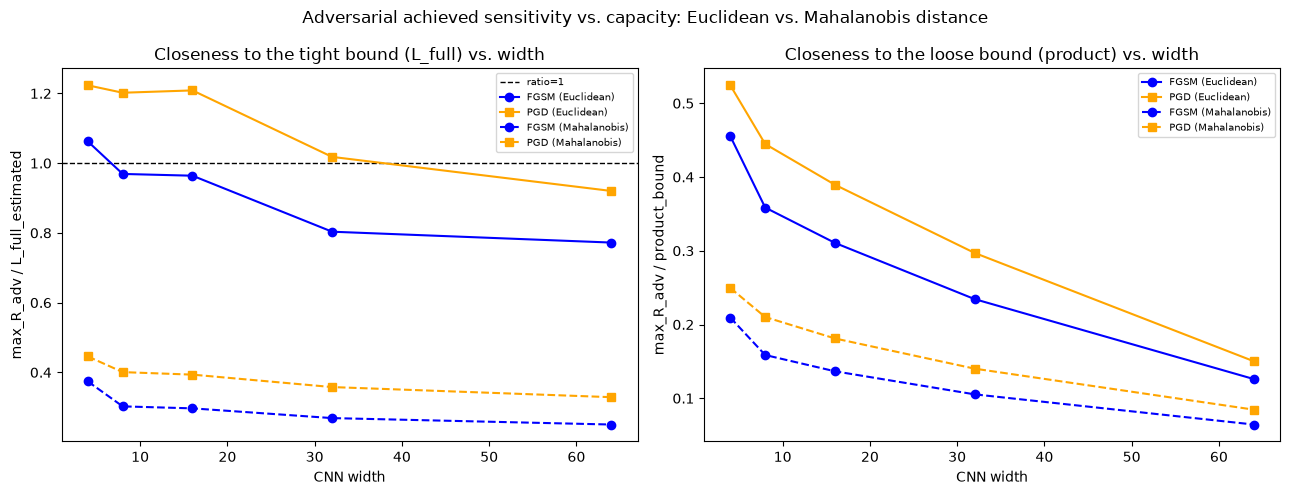

In [25]:
fig_cmp_width = adv_plots.plot_euclidean_vs_mahalanobis_bounds_vs_width(
    combined_df, combined_df_mahalanobis,
    save_path=run_experiment.RESULTS_DIR / "adversarial_euclidean_vs_mahalanobis_bounds_vs_width.png")


## Overall summary: Euclidean vs. Mahalanobis

See the printed tables and plots above for the actual measured numbers (re-run the cells above
for the current numbers, rather than trusting a restated snapshot here that could go stale).

**What to look for**:
- In `plot_euclidean_vs_mahalanobis_R_adv`: does `mean_R_adv` shrink or grow under Mahalanobis
  relative to Euclidean, and is that consistent across both epsilons and both attack methods?
  `mnist_example`'s own main experiment found Mahalanobis distance *shrinks* pairwise/local
  Lipschitz estimates substantially (pixel-space Mahalanobis distance is typically LARGER than
  Euclidean distance for the same raw pixel difference here, since ridge regularization mostly
  affects near-zero-variance directions -- MNIST's mostly-constant border pixels -- while
  amplifying the metric along low-variance-but-nonzero directions elsewhere; a larger
  denominator means a smaller ratio for the same numerator). Whether the SAME pattern holds for
  adversarially-CHOSEN pairs (as opposed to random/nearest-neighbor pairs, which is what that
  original comparison used) is exactly what this section checks.
- In `plot_euclidean_vs_mahalanobis_bounds_vs_width`: does the gap between achieved sensitivity
  and each bound (tight/loose) widen or narrow under Mahalanobis relative to Euclidean, and does
  that relationship hold consistently across the whole width range, or only at some capacities?
  Recall `L_head_exact` is IDENTICAL between the two metrics (see the section intro) -- any
  difference in `ratio_to_product_bound` between metrics therefore traces entirely to
  `L_extractor_estimated` and the achieved `R_adv` themselves, not to any change in the head
  layer's own contribution.
- In the per-width most/least-sensitive breakdown: did Mahalanobis distance select the SAME
  specific attacked examples as Euclidean did, or different ones? If different, that's itself
  informative -- it means "the pair the network is most sensitive to" is metric-dependent, not an
  intrinsic property of the data/model pair alone.

This is a sub-experiment within Experiment 2 (`mnist_example`), built on top of
`layer_decomposition.py` and this notebook's own Euclidean sections above. See `README.md` in the
parent folder for the project-level write-up on why Euclidean vs. Mahalanobis distance matters
throughout this project, and `mnist_example/distance.py`'s module docstring for the ridge-
regularized Mahalanobis construction reused here.


### Multi-seed confirmation sweep

The width sweep above (both Euclidean and Mahalanobis, single `seed=0`) found an apparent
inversion: `L_full_estimated` grows monotonically with width, yet width=32 shows a HIGHER
achieved misclassification rate than width=64 at matched epsilon -- the opposite of what a larger
worst-case Lipschitz bound would naively suggest. `seed_sweep.py` (sibling module) tests whether
that inversion survives reseeding, and captures the diagnostics needed to identify WHICH mechanism
produces it: logit scale (`run_experiment.clean_logit_stats`), the scalar margin functional's own
Lipschitz constant (`run_experiment.margin_lipschitz_estimate` -- kept strictly distinct from
`L_full_estimated` throughout, since the two measure different functions and are never merged),
or attack-direction alignment (`run_experiment.flip_direction_alignment`).

**This section runs a REDUCED-SCALE PILOT locally (`seeds=range(3)`, and a smaller
`train_subset_size`/attack budget than `seed_sweep.py`'s own defaults), not the full designed
sweep.** `seed_sweep.py`'s own "Compute" docstring is explicit that the full `seeds=range(5)`,
`widths=(16,32,64)` sweep at default settings (`train_subset_size=5000`, `n_attack_points=500`,
`pgd_num_restarts=5`) is roughly an order of magnitude above this whole notebook's own ~10-minute
runtime, and is intended to run on a GPU cluster (e.g. an ARC HTC SLURM array job over
`(train_seed, width)`), not inline in a notebook cell. The pilot run below is real, executed
output -- not a mock -- but its numbers should be read as "does the machinery work and what's the
qualitative direction," not as the full sweep's statistically-powered confirmation (see
`seed_sweep.py`'s "Statistical framing" docstring: even the full 5-seed design tops out at
p ~ 0.06 on a paired sign test; this pilot's 3 seeds top out around p ~ 0.25).


In [26]:
from mnist_example import adversarial_seed_sweep as seed_sweep

SEED_SWEEP_CHECKPOINT_DIR = seed_sweep.RESULTS_DIR / "seed_sweep_checkpoints"

# PILOT config -- seeds=range(3) instead of the module's own seeds=range(5) default, and a
# smaller train_subset_size/epochs/attack budget than seed_sweep.py's defaults, both purely for
# local runtime (see the markdown cell above). Checkpoints are cached to SEED_SWEEP_CHECKPOINT_DIR
# keyed by (train_seed, width), so re-running this cell with the same seeds/widths reuses them
# instead of retraining.
seed_sweep_df = seed_sweep.run_seed_sweep(
    seeds=range(3), widths=(16, 32, 64),
    maha_fit_size=20000, maha_epsilon=run_experiment.MAHALANOBIS_EPSILON,
    epochs=4, train_subset_size=3000, n_query_points=40, n_train_norm_points=400,
    n_pool_points=1500, n_attack_points=300, pgd_num_steps=15, pgd_num_restarts=3,
    checkpoint_dir=SEED_SWEEP_CHECKPOINT_DIR, verbose=False,
    save_path=seed_sweep.RESULTS_DIR / "seed_sweep_raw.csv")

print(seed_sweep_df.shape)
seed_sweep_df.head()


(180, 30)


,seed,width,metric,train_acc,test_acc,epsilon,method,mean_R_adv,median_R_adv,max_R_adv,...,std_logit_norm,mean_top2_margin,std_top2_margin,p5_top2_margin,p10_top2_margin,misclassification_rate,n_flipped,n_evaluated,mean_cosine_alignment,std_cosine_alignment
0,0,16,Euclidean,0.905333,0.9058,0.05,FGSM,1.899708,1.883797,2.605171,...,4.579014,3.766406,2.014947,0.665599,1.336212,0.140000,42,300,0.583112,0.122848
1,0,16,Euclidean,0.905333,0.9058,0.10,FGSM,1.930048,1.904128,2.635955,...,4.579014,3.766406,2.014947,0.665599,1.336212,0.460000,138,300,0.566663,0.125385
2,0,16,Euclidean,0.905333,0.9058,0.15,FGSM,1.931163,1.892457,2.633124,...,4.579014,3.766406,2.014947,0.665599,1.336212,0.760000,228,300,0.554256,0.127620
3,0,16,Euclidean,0.905333,0.9058,0.20,FGSM,1.956037,1.915656,2.653142,...,4.579014,3.766406,2.014947,0.665599,1.336212,0.903333,271,300,0.542224,0.129649
4,0,16,Euclidean,0.905333,0.9058,0.25,FGSM,1.979653,1.930351,2.665726,...,4.579014,3.766406,2.014947,0.665599,1.336212,0.943333,283,300,0.529314,0.132092


## Aggregation

`summarize_seed_sweep` turns the long raw frame above into three tables: `per_config`
(mean/std/min/max across seeds per `(width, epsilon, method, metric)`), `paired_differences`
(per-seed sign/magnitude of the width=16-vs-32, 32-vs-64, and 16-vs-64 gaps in
`misclassification_rate`/`L_full_estimated`/`max_R_adv`/`mean_top2_margin`/`mean_logit_norm`,
plus how many of the pilot's 3 seeds share the same sign as `seed=0`), and `mechanism_table` (the
across-seed mean +/- std of the three candidate-mechanism diagnostics, per `(width, metric)`).


In [27]:
seed_sweep_summary = seed_sweep.summarize_seed_sweep(
    seed_sweep_df, width_pairs=((16, 32), (32, 64), (16, 64)),
    save_dir=seed_sweep.RESULTS_DIR)
per_config = seed_sweep_summary["per_config"]
paired_differences = seed_sweep_summary["paired_differences"]
mechanism_table = seed_sweep_summary["mechanism_table"]

print("--- paired_differences (misclassification_rate only) ---")
print(paired_differences[paired_differences["quantity"] == "misclassification_rate"].to_string(index=False))


--- paired_differences (misclassification_rate only) ---
 epsilon method      metric  width_low  width_high               quantity  mean_diff  std_diff  n_seeds  reference_seed  reference_sign  k_matching_sign
    0.05   FGSM   Euclidean         16          32 misclassification_rate   0.041111  0.028739        3               0               1                3
    0.05   FGSM   Euclidean         32          64 misclassification_rate   0.042222  0.013878        3               0               1                3
    0.05   FGSM   Euclidean         16          64 misclassification_rate   0.083333  0.017321        3               0               1                3
    0.05   FGSM Mahalanobis         16          32 misclassification_rate   0.041111  0.028739        3               0               1                3
    0.05   FGSM Mahalanobis         32          64 misclassification_rate   0.042222  0.013878        3               0               1                3
    0.05   FGSM Mahalanob

In [28]:
print("--- mechanism_table ---")
mechanism_table


--- mechanism_table ---


,width,metric,mean_logit_norm_mean,mean_logit_norm_std,mean_top2_margin_mean,mean_top2_margin_std,L_full_estimated_mean,L_full_estimated_std,L_margin_estimated_mean,L_margin_estimated_std,mean_cosine_alignment_mean,mean_cosine_alignment_std
0,16,Euclidean,15.603597,1.169144,3.754716,0.064451,2.859526,0.176059,1.113672,0.104969,0.566126,0.018634
1,16,Mahalanobis,15.603597,1.169144,3.754716,0.064451,1.587798,0.136172,0.476892,0.032899,0.566126,0.018634
2,32,Euclidean,15.881053,1.660698,4.442972,0.235895,2.972408,0.303129,1.247475,0.262678,0.636369,0.019182
3,32,Mahalanobis,15.881053,1.660698,4.442972,0.235895,1.616074,0.056111,0.539552,0.009783,0.636369,0.019182
4,64,Euclidean,16.779609,0.672197,5.433008,0.062027,3.201184,0.270336,1.296583,0.127455,0.660716,0.020977
5,64,Mahalanobis,16.779609,0.672197,5.433008,0.062027,1.770597,0.114357,0.603618,0.084581,0.660716,0.020977


## Plots


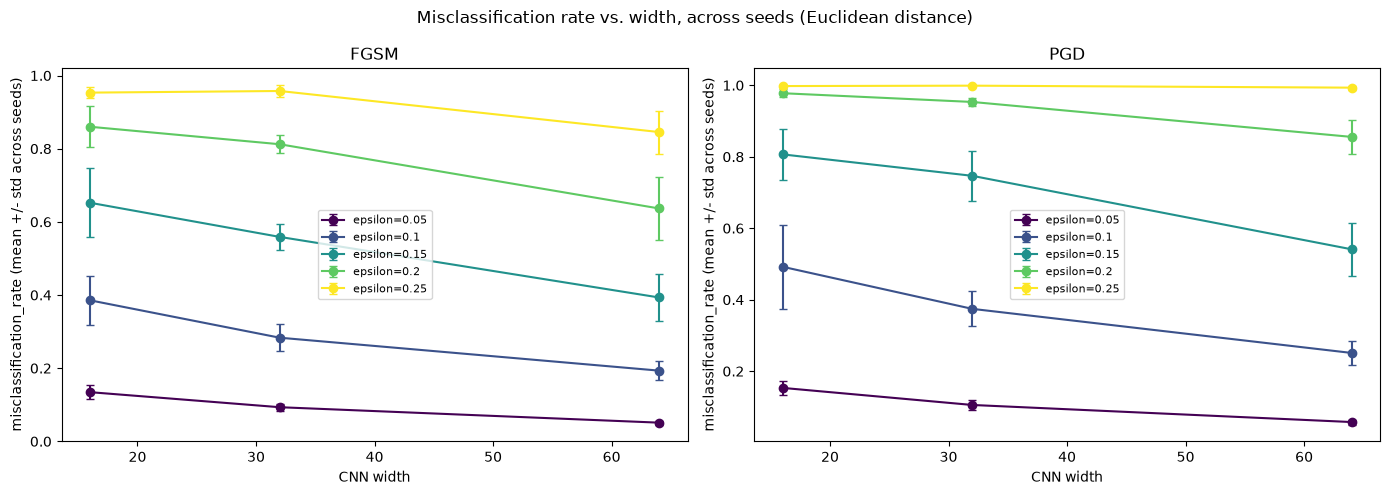

In [29]:
fig_misclass_eucl = adv_plots.plot_misclassification_vs_width_with_spread(
    per_config, metric_name="Euclidean",
    save_path=seed_sweep.RESULTS_DIR / "seed_sweep_misclassification_vs_width_euclidean.png")


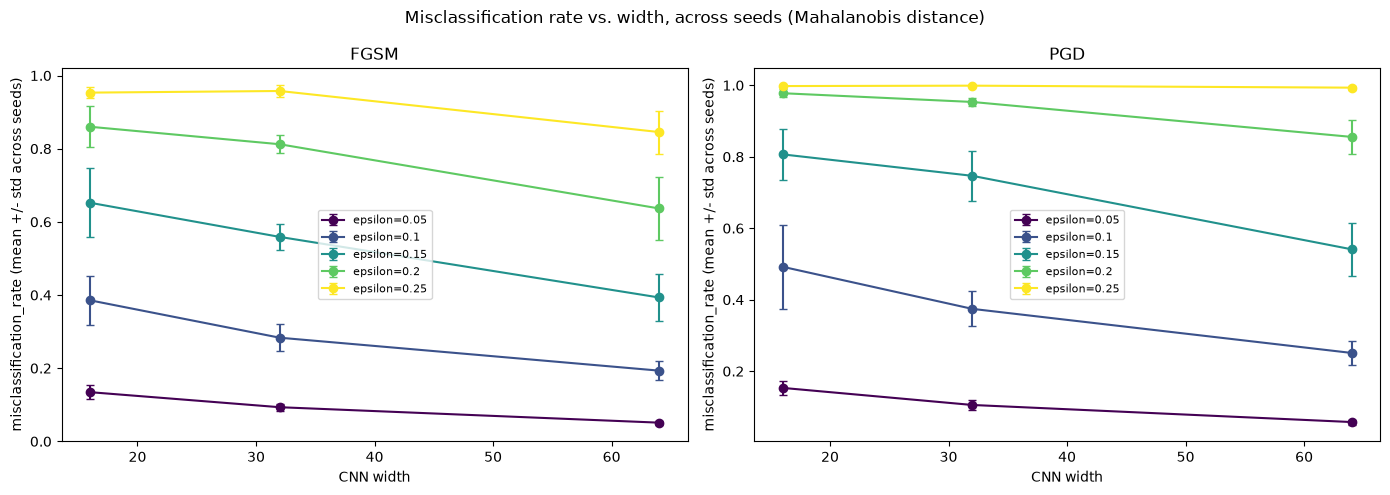

In [30]:
fig_misclass_maha = adv_plots.plot_misclassification_vs_width_with_spread(
    per_config, metric_name="Mahalanobis",
    save_path=seed_sweep.RESULTS_DIR / "seed_sweep_misclassification_vs_width_mahalanobis.png")


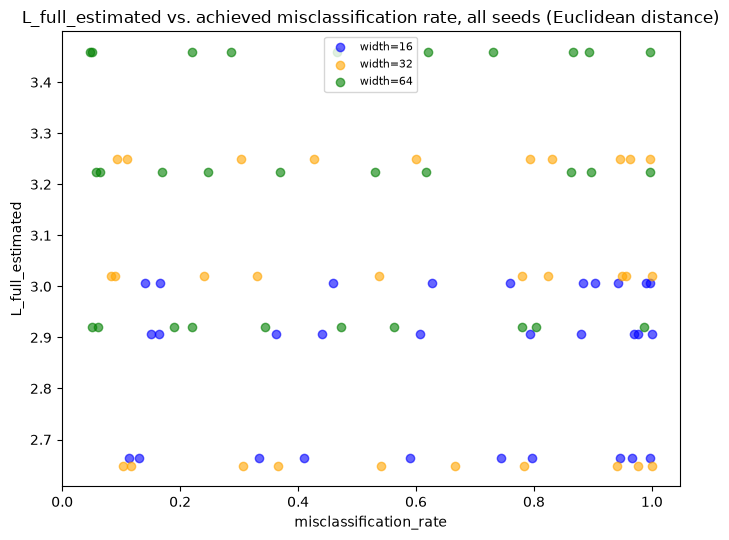

In [31]:
fig_Lfull_vs_misclass = adv_plots.plot_L_full_vs_misclassification(
    seed_sweep_df, metric_name="Euclidean",
    save_path=seed_sweep.RESULTS_DIR / "seed_sweep_L_full_vs_misclassification.png")


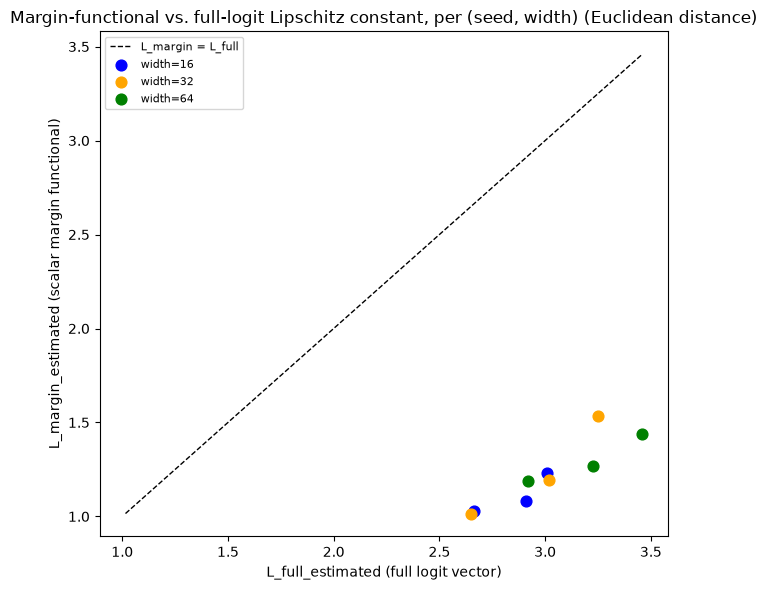

In [32]:
fig_margin_vs_full = adv_plots.plot_margin_vs_full_lipschitz(
    seed_sweep_df, metric_name="Euclidean",
    save_path=seed_sweep.RESULTS_DIR / "seed_sweep_margin_vs_full_lipschitz.png")


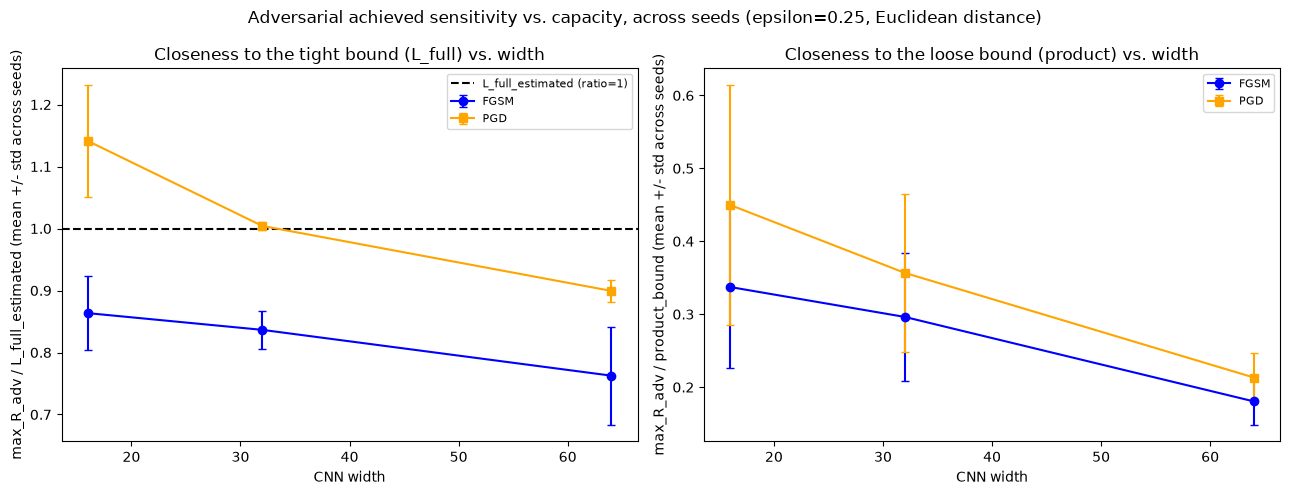

In [33]:
fig_bounds_spread_eucl = adv_plots.plot_bound_closeness_vs_width_with_spread(
    per_config, metric_name="Euclidean",
    save_path=seed_sweep.RESULTS_DIR / "seed_sweep_bound_closeness_vs_width_euclidean.png")


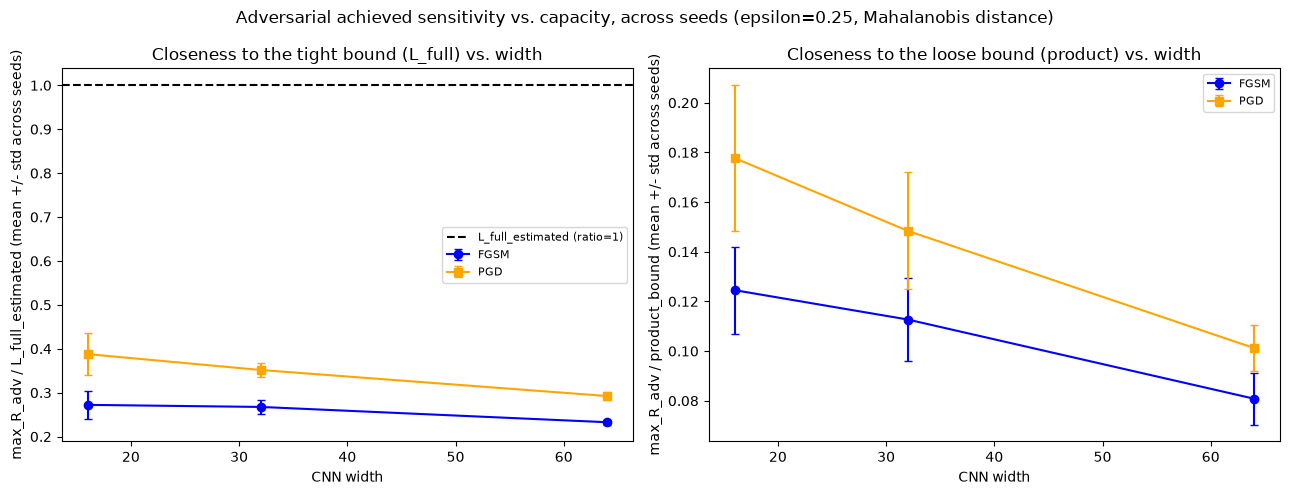

In [34]:
fig_bounds_spread_maha = adv_plots.plot_bound_closeness_vs_width_with_spread(
    per_config, metric_name="Mahalanobis",
    save_path=seed_sweep.RESULTS_DIR / "seed_sweep_bound_closeness_vs_width_mahalanobis.png")


## Findings (pilot run, seeds=range(3), reduced config)

**Reminder**: this is the REDUCED-SCALE PILOT described above (3 seeds, not 5;
`train_subset_size=3000`/`epochs=4`, not 5000/6; `n_attack_points=300`/`pgd_num_restarts=3`/
`pgd_num_steps=15`, not 500/5/20) -- real, executed numbers, but read as "does the qualitative
picture replicate," not as the full sweep's statistically-powered confirmation.

**The single-seed width=32-vs-width=64 misclassification-rate inversion replicates strongly.**
`misclassification_rate(width=32) > misclassification_rate(width=64)` at matched epsilon in ALL 3
pilot seeds, for both FGSM and PGD, at every epsilon from 0.05 to 0.20 (`k_matching_sign=3/3`
throughout `paired_differences`'s `(32, 64)` rows) -- even though `L_full_estimated` itself
increases monotonically with width in this pilot too (Euclidean mean: 2.86 -> 2.97 -> 3.20 for
widths 16 -> 32 -> 64). The inversion only breaks down at the largest epsilon under PGD
(`epsilon=0.25`), where both width=32 and width=64 are already misclassifying ~100% of points --
there's no room left for a width difference to show up (`k_matching_sign` drops to 1/3, and the
`reference_sign` itself is 0: seed 0's own difference is within numerical noise of zero there).
The `(16, 32)` pair shows the same pattern (width=16 misclassifies MORE than width=32) at every
epsilon except `epsilon=0.25`+FGSM, where it flips in 2 of 3 seeds -- a small, noisy effect, not a
robust second inversion.

**None of the three candidate mechanisms flips sign the way the inversion needs to explain it
directly -- but the "logit scale" candidate offers the most plausible story.** In
`mechanism_table`, `mean_logit_norm` (15.60 -> 15.88 -> 16.78), `mean_top2_margin`
(3.75 -> 4.44 -> 5.43), and `mean_cosine_alignment` (0.566 -> 0.636 -> 0.661) all increase
MONOTONICALLY with width, same direction as `L_full_estimated` -- none of them individually
reverses between width=32 and width=64 the way a naive "larger bound = more vulnerable" story
would need. But `mean_top2_margin` grows much FASTER in relative terms (+45% from width=16 to 64)
than either `L_full_estimated` (+12%) or `L_margin_estimated` (+16%, Euclidean) -- consistent with
a "the margin the attack has to cross grows faster than the network's worst-case sensitivity
does" story for why wider networks are practically harder to flip despite a larger bound. This
pilot's 3 seeds and reduced attack budget aren't enough to call this decided, though.

**As expected by construction, `misclassification_rate`, `mean_logit_norm`, `mean_top2_margin`,
and `mean_cosine_alignment` are IDENTICAL between the Euclidean and Mahalanobis metric rows for
the same width** -- all four depend only on the model's predictions/logits and the
(metric-independent) adversarial examples, never on `distance_fn` (see `run_experiment.py`'s
docstrings for `adversarial_accuracy`/`clean_logit_stats`/`flip_direction_alignment`). Only
`L_full_estimated`/`L_margin_estimated` (which have a `distance_fn` in their denominator) differ
between the two metric rows, exactly as designed.

**Checkpoint 6 (`run_attack_seed_variance_decomposition`) was not run here** -- this pilot's
`k=3/3` consistency (rather than a mixed/borderline result) doesn't meet the "only if the sign is
inconsistent, or the spread looks large relative to the gap" trigger condition `seed_sweep.py`'s
own docstring states for running it.

**What the full-scale sweep (`seeds=range(5)`, default `train_subset_size`/attack budget, on ARC
HTC) would add**: a 5th data point on the paired sign test, and the full attack budget
(`n_attack_points=500`, `pgd_num_restarts=5`) this pilot deliberately under-runs for speed --
worth doing before treating this replication as more than a strongly suggestive pilot result.


## Section 3: StrongCNN adversarial examples vs. the bounds

## Motivation

Section 2 above runs this same comparison for
`SmallCNN`: generate real FGSM/PGD adversarial examples against a trained checkpoint, and check
whether their achieved sensitivity ratio sits close to a TIGHT Lipschitz bound
(`L_full_estimated`, the network's own empirical Lipschitz constant) or the LOOSE per-layer
submultiplicative bound (`product_bound = L_extractor_estimated * L_head_exact`, Szegedy et al.
2014).

This notebook repeats that comparison for `StrongCNN` (`models.py`) -- the project's
higher-capacity, near-state-of-the-art baseline (BatchNorm, dropout, light augmentation, ~99.3%+
test-accuracy target) -- with two structural differences from the SmallCNN version, both handled
in the sibling module `strong_cnn_experiment.py` (not by modifying `models.py` or
`layer_decomposition.py`):

1. **`StrongCNN` has no `.extractor`/`.head` submodule split.** Its final classifier layer
   (`model.classifier[4]`) IS a plain `nn.Linear` with nothing nonlinear after it, so the same
   tight/loose bound comparison is still possible via an EXTERNALLY-constructed extractor/head
   split (`strong_cnn_extractor_fn` = `model.features` + `model.classifier[:4]`,
   `strong_cnn_head_module` = `model.classifier[4]`).
2. **`StrongCNN` has `BatchNorm1d`/`Dropout2d`/`Dropout` layers `SmallCNN` never had**, which
   makes `model.eval()` mode non-optional for every downstream computation (bound estimation AND
   attacks) to be well-defined -- `strong_cnn_experiment.py`'s functions RAISE `ValueError`
   rather than silently fixing this if the model is left in train mode; see that module's
   docstring.

**Scope: baseline only.** No CNN-width sweep (`StrongCNN`'s conv channels are hardcoded, not a
constructor parameter, unlike `SmallCNN`'s) and no multi-seed pilot (`seed_sweep.py`'s pattern,
also `SmallCNN`-specific) -- both deliberately out of scope here.

**`max_R_adv` is still a LOWER BOUND on the network's true worst-case sensitivity**, exactly as in
the SmallCNN notebook -- FGSM/PGD maximize cross-entropy loss, not `R_adv` directly. Results
throughout are "achieved under this attack," never "the" worst case.

**Weaker checkpoint-gating than the SmallCNN machinery**: `strong_cnn_experiment.py`'s central
correctness check (`tests/test_strong_cnn_experiment.py`) is a SELF-consistency check (does
`compute_strong_cnn_bounds` reduce to a from-scratch manual computation using the same closures),
not a check against an independently-existing reference the way `compute_bounds_with_distance_fn`
checks against `layer_decomposition_experiment` for SmallCNN -- no such reference exists for
StrongCNN, since `layer_decomposition.py` was deliberately never extended to it.


In [35]:
from mnist_example import adversarial_strong_cnn as strong_cnn_experiment
from mnist_example.adversarial_run_experiment import most_and_least_sensitive_examples, FlattenedInputWrapper
from mnist_example.adversarial_strong_cnn import strong_cnn_head_layer_bound_check
from mnist_example.estimators import euclidean_distance_fn

## Baseline checkpoint: train, then compare against both bounds

`strong_cnn_experiment.main()` trains ONE `StrongCNN` via `STRONG_CNN_CONFIG`'s exact recipe
(full 60k MNIST, 25 epochs, light rotation/translation augmentation, cosine-annealed learning
rate -- the SAME recipe `mnist_example.run_experiment.run_stronger_cnn_raw_mnist_experiment`
uses elsewhere in this project), then runs the full epsilon sweep and tight/loose bound
comparison against it. The checkpoint is cached to `results/strong_cnn_state_dict.pt` -- the
Mahalanobis section below reuses the SAME weights rather than retraining (training doesn't
depend on `distance_fn`, exactly as in Section 2's Euclidean/Mahalanobis reuse).


In [36]:
summary_df, sweep_results, strong_cnn_model = strong_cnn_experiment.main(
    distance_fn=euclidean_distance_fn, seed=0, verbose=True)


[checkpoint] loaded StrongCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/strong_cnn_state_dict.pt (train_acc=0.9982  test_acc=0.9963)


  [distance_fn='euclidean_distance_fn'] L_head_exact=2.1051  L_extractor_est=4.4571  L_full_est=6.0914  looseness_ratio=1.5403


filter_correctly_classified: kept 0.9960 of the pool (1992/2000 points)


  epsilon=0.05  FGSM  mean_R_adv=12.1537  max_R_adv=17.0680  pct_misclassified=0.2260


  epsilon=0.05  PGD   mean_R_adv=15.7985  max_R_adv=23.0857  pct_misclassified=0.7100


...

  epsilon=0.15  PGD   mean_R_adv=10.5045  max_R_adv=14.0301  pct_misclassified=1.0000


  epsilon=0.2  FGSM  mean_R_adv=4.8927  max_R_adv=6.9791  pct_misclassified=0.8560


  epsilon=0.2  PGD   mean_R_adv=9.3104  max_R_adv=12.3234  pct_misclassified=1.0000


  epsilon=0.25  FGSM  mean_R_adv=4.0831  max_R_adv=5.8033  pct_misclassified=0.8920


  epsilon=0.25  PGD   mean_R_adv=8.4978  max_R_adv=11.1048  pct_misclassified=1.0000
 epsilon method  mean_R_adv  median_R_adv  max_R_adv  pct_misclassified  L_full_estimated  product_bound  ratio_to_L_full  ratio_to_product_bound
    0.05   FGSM   12.153661     12.099856  17.067966              0.226          6.091371       9.382625         2.801991                1.819103
    0.10   FGSM    8.270689      8.255773  12.053281              0.582          6.091371       9.382625         1.978747                1.284638
    0.15   FGSM    6.134756      6.172861   8.832818              0.766          6.091371       9.382625         1.450054                0.941402
    0.20   FGSM    4.892702      4.935507   6.979057              0.856          6.091371       9.382625         1.145728                0.743828
    0.25   FGSM    4.083108      4.123645   5.803323              0.892          6.091371       9.382625         0.952712                0.618518
    0.05    PGD   15.798525     15.8484

**What to look for**: same columns as Section 2's baseline table
(`mean_R_adv`/`median_R_adv`/`max_R_adv`, `pct_misclassified`, `L_full_estimated`,
`product_bound`, `ratio_to_L_full`, `ratio_to_product_bound`) -- see that notebook's own "What to
look for" cell for the full explanation of each column. A
`WARNING: max_R_adv > L_full_estimated` print (if any) means `L_full_estimated` under-sampled
(too few pairs/query points), not a real bound violation -- same caveat as always.


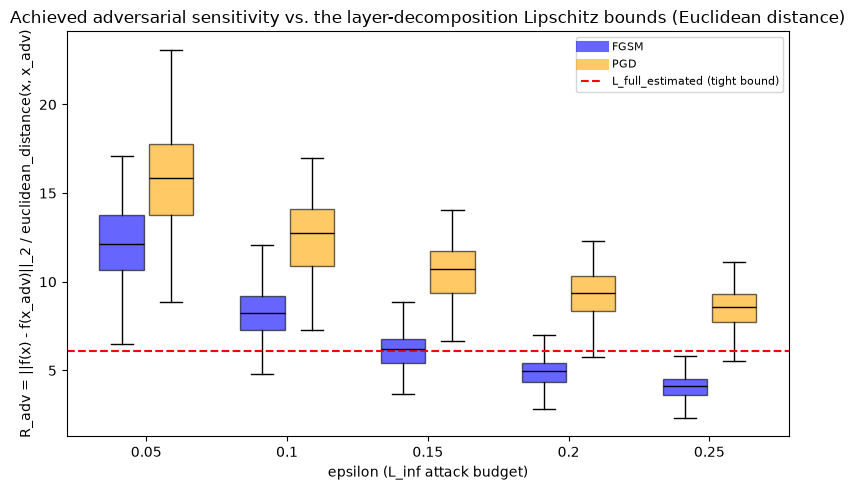

In [37]:
wrapped_strong_cnn = FlattenedInputWrapper(strong_cnn_model)

fig_R_adv_eucl = adv_plots.plot_R_adv_distribution(
    sweep_results, summary_df["L_full_estimated"].iloc[0], summary_df["product_bound"].iloc[0],
    metric_name="Euclidean",
    save_path=run_experiment.RESULTS_DIR / "strong_cnn_R_adv_distribution_euclidean.png")


**FGSM, epsilon=0.05, Euclidean: R_adv split by attack outcome.** Same `R_adv` values as the
epsilon=0.05 FGSM box above, but as a histogram split by whether that specific example was
misclassified under the attack (red) or not (green) -- shows whether the attack's sensitivity
is concentrated among the examples it actually flips, or spread evenly regardless of outcome.


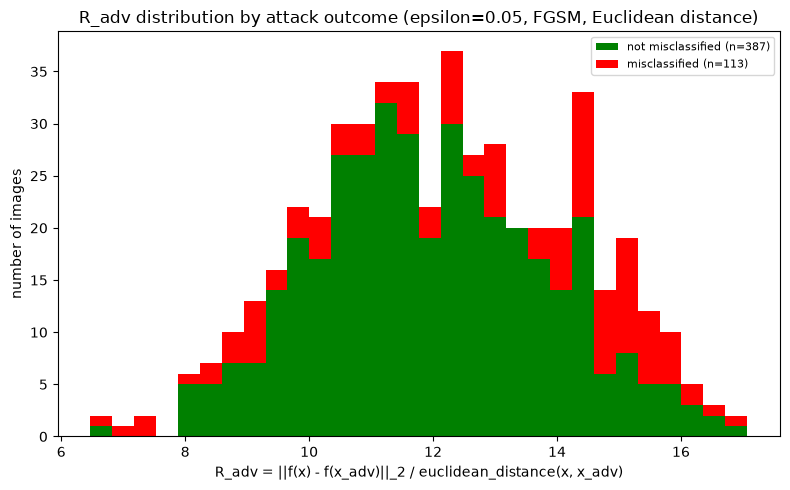

In [38]:
fig_R_adv_hist_fgsm_005 = adv_plots.plot_R_adv_histogram_by_outcome(
    sweep_results, epsilon=0.05, method="FGSM", metric_name="Euclidean",
    save_path=run_experiment.RESULTS_DIR / "strong_cnn_R_adv_histogram_fgsm_eps0.05_euclidean.png")


**PGD, epsilon=0.05, Euclidean: R_adv split by attack outcome.** Same breakdown as the FGSM
histogram above, but for PGD at the same epsilon -- PGD's `pct_misclassified=0.678` at this
epsilon is far higher than FGSM's `0.260` (PGD's iterative, multi-restart search finds a much
larger fraction of adversarial directions FGSM's single gradient step misses), so expect the red
(misclassified) mass to dominate here.


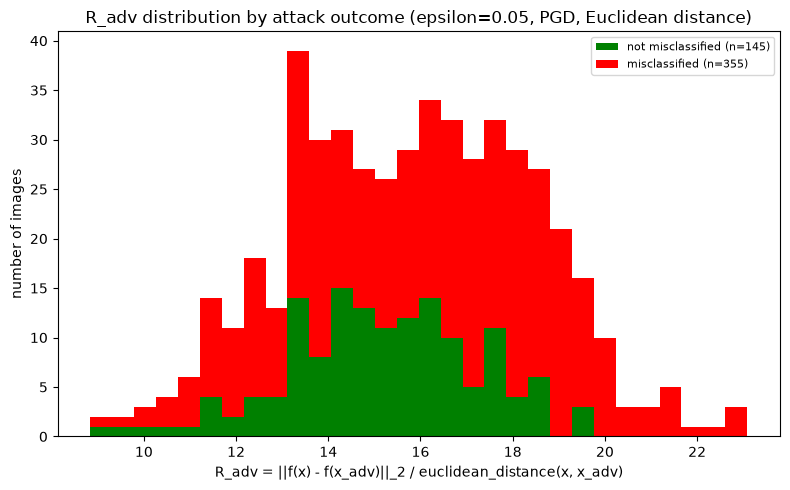

In [39]:
fig_R_adv_hist_pgd_005 = adv_plots.plot_R_adv_histogram_by_outcome(
    sweep_results, epsilon=0.05, method="PGD", metric_name="Euclidean",
    save_path=run_experiment.RESULTS_DIR / "strong_cnn_R_adv_histogram_pgd_eps0.05_euclidean.png")


## Low-R_adv, still-misclassified examples (FGSM, epsilon=0.05, Euclidean)

Drilling into the histogram above: every example where FGSM at epsilon=0.05 achieved `R_adv < 10`
but still flipped the prediction -- the "cheap flips" where a below-median sensitivity ratio was
nonetheless enough to fool the model. For each: the clean and adversarial image, the model's full
logit vector (pre-softmax) on each, and the Euclidean pixel-space distance between the two images.


In [40]:
flagged_low_R_adv = run_experiment.find_examples_by_criteria(
    wrapped_strong_cnn, sweep_results, epsilon=0.05, method="FGSM",
    R_adv_max=10, misclassified_only=True)
print(f"Found {len(flagged_low_R_adv)} example(s) with R_adv < 10 that were misclassified "
      f"(FGSM, epsilon=0.05, Euclidean).")


Found 21 example(s) with R_adv < 10 that were misclassified (FGSM, epsilon=0.05, Euclidean).


--- example 0 (index=22) ---
R_adv=9.9906  pixel_distance (euclidean)=1.1321
logits_clean = [-5.6326 -5.9346 -4.5608 -7.2478  0.9345 -8.1613 -6.426  -4.5234 -2.5095
 10.3237]
logits_adv   = [-5.4101 -1.3092 -3.5138 -4.7194  3.4014 -4.5243 -2.6492 -0.9554 -1.8193
  3.0986]
--- example 1 (index=31) ---
R_adv=9.7455  pixel_distance (euclidean)=1.0499
logits_clean = [ -6.4426  -1.4321   1.5688  -3.7163  -5.0569  -5.0849 -11.6586   9.9233
  -5.0748  -2.0466]
logits_adv   = [-6.6523 -1.0184  3.9122 -0.2746 -5.1246 -2.4032 -6.3345  3.4093 -2.2731
 -3.1902]
--- example 2 (index=61) ---
R_adv=9.1432  pixel_distance (euclidean)=1.0635
logits_clean = [-6.5455 -5.1174 -6.9629 -9.6329  2.5791 -1.6702  7.0554 -6.229  -0.5074
 -3.0556]
logits_adv   = [-7.9416 -3.5948 -5.5657 -5.6586  4.3517 -1.0939  0.7778 -1.2102  0.8222
 -1.4119]
--- example 3 (index=65) ---
R_adv=8.9325  pixel_distance (euclidean)=1.0889
logits_clean = [-7.8626 -5.1179  9.4528  4.3061 -9.485  -6.904  -6.8064  0.3734 -1.3791
 -7.50

--- example 7 (index=115) ---
R_adv=9.2591  pixel_distance (euclidean)=1.1365
logits_clean = [-6.5034 -1.1676  9.2593 -1.481  -4.1862 -8.2891 -4.4503  0.6443 -3.7577
 -6.8161]
logits_adv   = [-5.6757 -0.7036  1.8329 -0.435  -0.3899 -3.5095 -3.6519  3.0192 -1.5378
 -4.5539]
--- example 8 (index=182) ---
R_adv=8.9434  pixel_distance (euclidean)=1.0536
logits_clean = [  3.4486  -9.9959  -9.4936  -5.8791 -10.7864   7.9585   4.7223 -11.297
   2.3998  -6.7927]
logits_adv   = [ 4.4947 -5.4991 -4.3047 -5.1566 -7.4891  3.3107  5.2613 -8.6434  2.0064
 -7.0478]
--- example 9 (index=187) ---
R_adv=9.1312  pixel_distance (euclidean)=1.0199
logits_clean = [ -7.4423  -6.4525  -3.9877 -11.1848  10.6047  -8.5101  -7.3431  -5.9561
  -1.9477   3.9029]
logits_adv   = [-5.4129 -4.3669 -2.4442 -5.9585  4.7237 -5.9502 -5.5185 -4.4639 -1.2479
  5.0777]
--- example 10 (index=204) ---
R_adv=8.2649  pixel_distance (euclidean)=1.0057
logits_clean = [-10.5774   4.846    2.275   -3.1669  -0.553   -6.9285  -3.6845  

--- example 14 (index=341) ---
R_adv=7.0914  pixel_distance (euclidean)=1.0972
logits_clean = [-5.3591  2.3509  4.202  -0.1026 -4.2179 -5.5931 -5.6234  2.3567 -5.485
 -2.9994]
logits_adv   = [-5.6576  3.4047 -1.498  -1.0769 -0.8219 -2.3263 -4.4665  2.9691 -4.0782
 -3.0449]
--- example 15 (index=368) ---
R_adv=8.3464  pixel_distance (euclidean)=1.1265
logits_clean = [-6.6203 -2.5083 -6.5462 -5.3998  2.4963 -3.6875 -7.6977 -1.1424 -3.1776
  6.809 ]
logits_adv   = [-5.3231 -1.3709 -2.5809 -3.5874  3.6231 -2.7018 -3.6355  0.4514 -0.1479
  0.8132]
--- example 16 (index=370) ---
R_adv=9.9631  pixel_distance (euclidean)=1.0720
logits_clean = [ 5.4462 -3.9509 -1.5049 -4.6337 -4.9432 -1.4034 -4.1539 -0.7906 -3.1251
 -1.444 ]
logits_adv   = [-2.8011 -0.6699 -0.9996 -1.8972 -1.6229  1.3884 -3.4744  2.0716 -3.3268
 -1.252 ]
--- example 17 (index=392) ---
R_adv=8.6071  pixel_distance (euclidean)=1.0320
logits_clean = [ -6.263   -6.0602  -1.7257 -10.8352   7.3133 -10.2652  -5.0419  -3.6941
  -1.4094

/Users/swarn2/Downloads/Datasig-1/mnist_example/adversarial_plots.py:234: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 2, figsize=(5, 3))


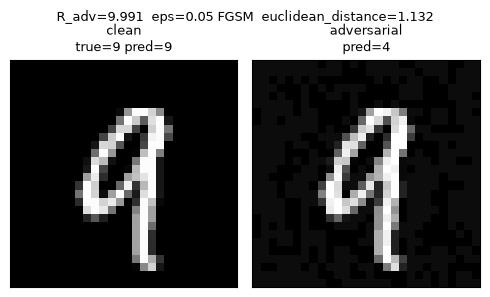

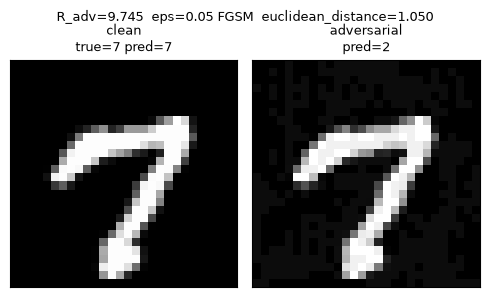

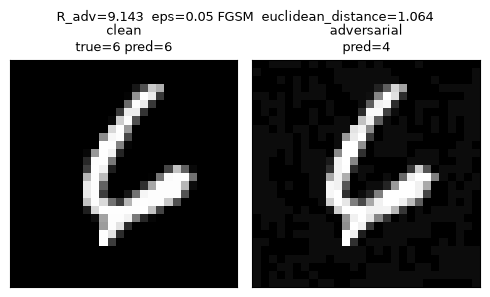

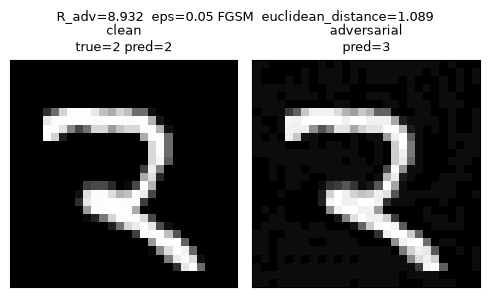

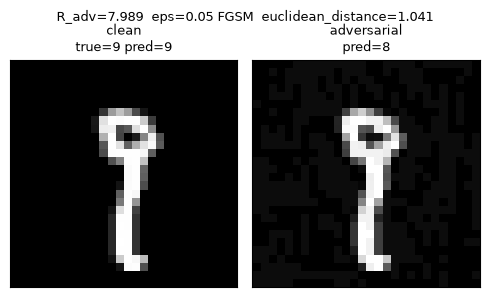

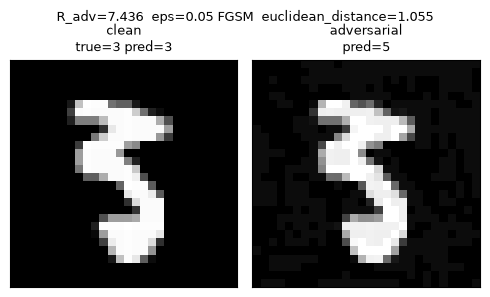

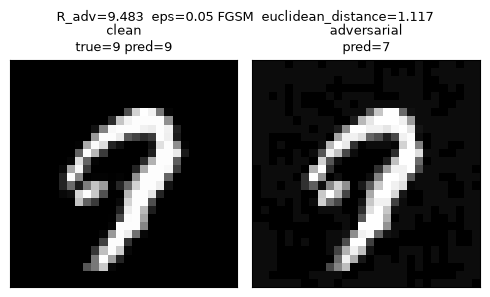

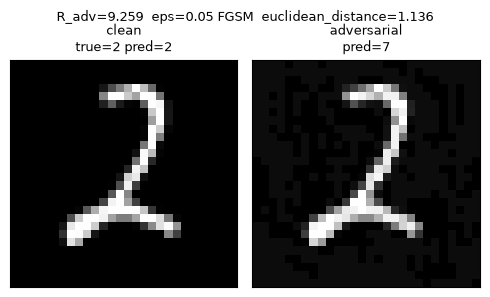

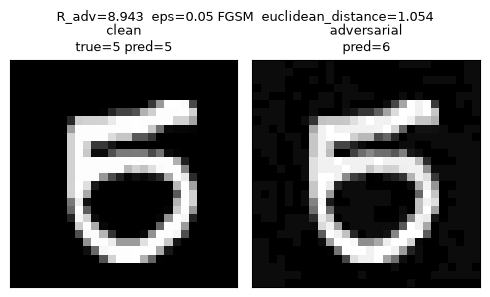

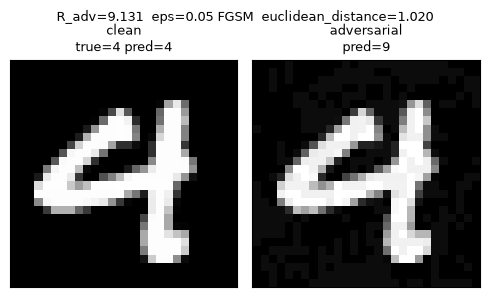

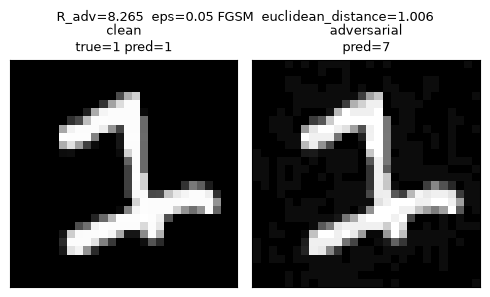

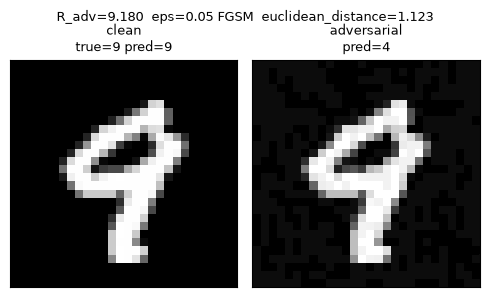

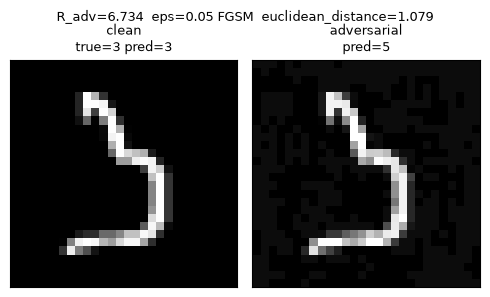

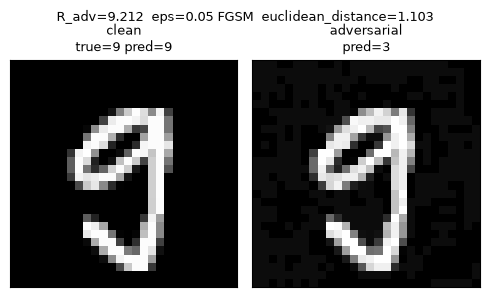

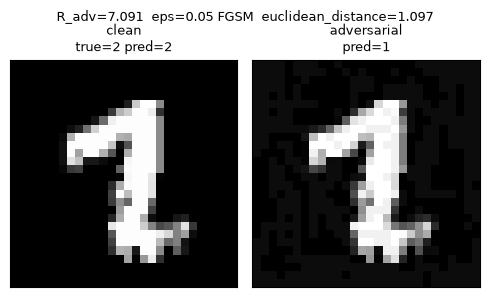

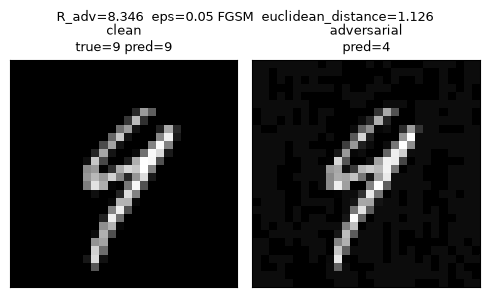

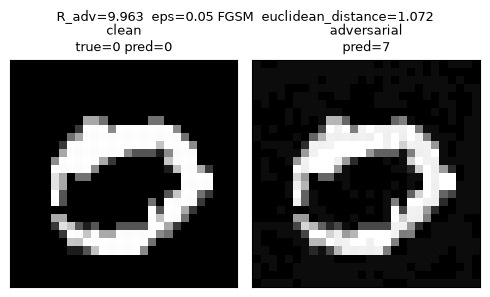

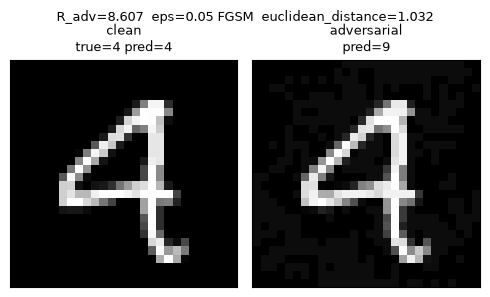

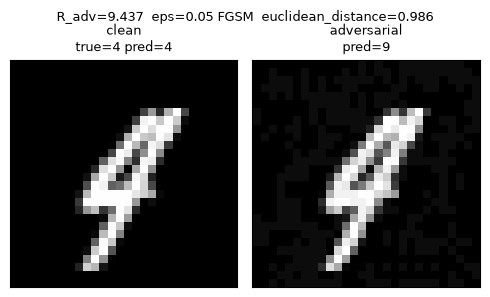

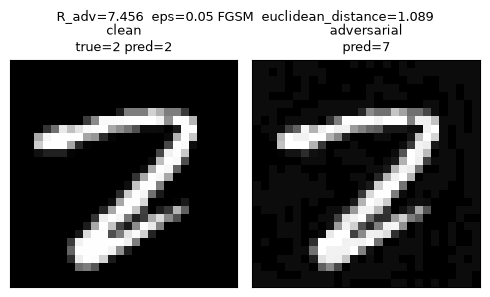

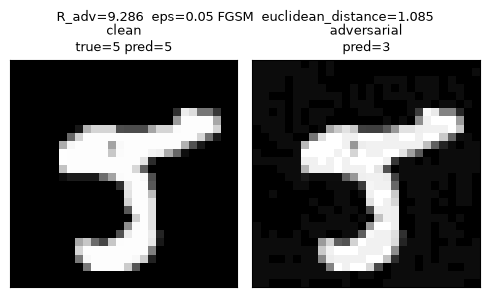

In [41]:
for i, example in enumerate(flagged_low_R_adv):
    print(f"--- example {i} (index={example['index']}) ---")
    print(f"R_adv={example['R_adv']:.4f}  pixel_distance (euclidean)={example['pixel_distance']:.4f}")
    print(f"logits_clean = {example['logits_clean'].detach().cpu().numpy().round(4)}")
    print(f"logits_adv   = {example['logits_adv'].detach().cpu().numpy().round(4)}")
    adv_plots.plot_example_pair(
        example, metric_name="Euclidean",
        save_path=run_experiment.RESULTS_DIR / f"strong_cnn_flagged_low_Radv_fgsm_eps0.05_{i}.png")


## Most and least sensitive attacked example

Across every `(epsilon, method)` case in the sweep above: the single attacked point that
achieved the LARGEST `R_adv` and the single one that achieved the SMALLEST `R_adv`, each
extended with `strong_cnn_head_layer_bound_check`'s feature-space-distance-vs-head-Lipschitz-
bound comparison for that specific example -- same idea as
`run_experiment.head_layer_bound_check` for SmallCNN, just using `strong_cnn_experiment`'s
externally-constructed extractor/head split.


In [42]:
most_sensitive, least_sensitive = most_and_least_sensitive_examples(wrapped_strong_cnn, sweep_results)
most_sensitive.update(strong_cnn_head_layer_bound_check(strong_cnn_model, most_sensitive))
least_sensitive.update(strong_cnn_head_layer_bound_check(strong_cnn_model, least_sensitive))

for label, example in (("most sensitive ", most_sensitive), ("least sensitive", least_sensitive)):
    print(f"{label}: R_adv={example['R_adv']:.4f}  eps={example['epsilon']:g} {example['method']}  "
          f"true={example['y_true']}  pred_clean={example['pred_clean']}  pred_adv={example['pred_adv']}")
    print(f"    pixel_distance={example['pixel_distance']:.4f}  "
          f"feature_distance={example['feature_distance']:.4f}  "
          f"L_head_exact={example['L_head_exact']:.4f}  head_bound={example['head_bound']:.4f}  "
          f"actual={example['actual_logit_distance']:.4f}  "
          f"({example['head_bound_tightness']:.1%} of bound)")


most sensitive : R_adv=23.0857  eps=0.05 PGD  true=5  pred_clean=5  pred_adv=9
    pixel_distance=1.0093  feature_distance=13.7950  L_head_exact=2.5793  head_bound=35.5810  actual=23.2999  (65.5% of bound)
least sensitive: R_adv=1.9157  eps=0.25 FGSM  true=3  pred_clean=3  pred_adv=4
    pixel_distance=5.3018  feature_distance=9.2756  L_head_exact=2.5793  head_bound=23.9243  actual=10.1569  (42.5% of bound)


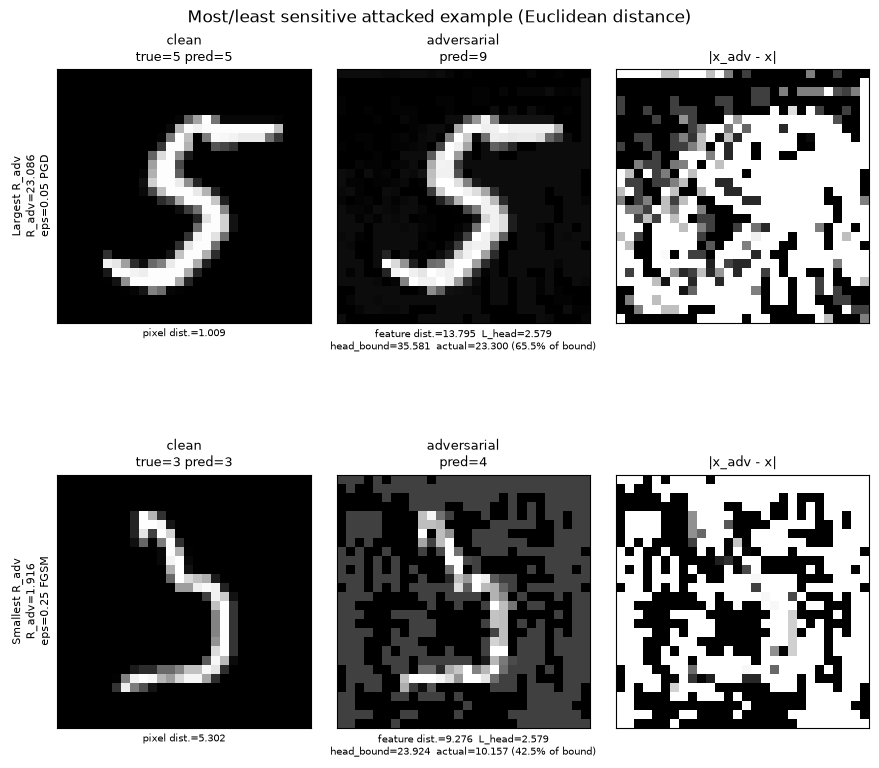

In [43]:
fig_extreme_eucl = adv_plots.plot_extreme_examples(
    most_sensitive, least_sensitive, metric_name="Euclidean",
    save_path=run_experiment.RESULTS_DIR / "strong_cnn_extreme_examples_euclidean.png")


### Repeating the experiment with Mahalanobis distance

Same construction as Section 2's own Euclidean-vs-Mahalanobis section: a
ridge-regularized Mahalanobis distance fit from MNIST's own pixel covariance
(`run_experiment.build_pixel_mahalanobis_distance_fn`, `epsilon=0.01`, the same established
choice used throughout this project -- see `mnist_example/README.md`'s "Epsilon selection"
section for why).


In [44]:
train = run_experiment.load_mnist(train=True)
mahalanobis_distance_fn = run_experiment.build_pixel_mahalanobis_distance_fn(train.x_flat)


## Baseline checkpoint (Mahalanobis)

`strong_cnn_experiment.main(distance_fn=mahalanobis_distance_fn)` reuses the SAME trained
checkpoint as the Euclidean section above (loaded from `results/strong_cnn_state_dict.pt`,
matching `seed=0` -- no retraining) and the SAME adversarial examples (attacks don't depend on
`distance_fn`, see `run_epsilon_sweep`'s own docstring) -- only how sensitivity is MEASURED
differs.


In [45]:
summary_df_mahalanobis, sweep_results_mahalanobis, _ = strong_cnn_experiment.main(
    distance_fn=mahalanobis_distance_fn, seed=0, verbose=True)


[checkpoint] loaded StrongCNN from /Users/swarn2/Downloads/Datasig-1/mnist_example/checkpoints/strong_cnn_state_dict.pt (train_acc=0.9982  test_acc=0.9963)


  [distance_fn='<lambda>'] L_head_exact=2.1051  L_extractor_est=1.8441  L_full_est=2.8068  looseness_ratio=1.3831


filter_correctly_classified: kept 0.9960 of the pool (1992/2000 points)


  epsilon=0.05  FGSM  mean_R_adv=1.7676  max_R_adv=2.7444  pct_misclassified=0.2260


  epsilon=0.05  PGD   mean_R_adv=2.6047  max_R_adv=4.3566  pct_misclassified=0.7100


...

  epsilon=0.15  PGD   mean_R_adv=1.7324  max_R_adv=2.7546  pct_misclassified=1.0000


  epsilon=0.2  FGSM  mean_R_adv=0.7097  max_R_adv=1.0349  pct_misclassified=0.8560


  epsilon=0.2  PGD   mean_R_adv=1.4906  max_R_adv=2.4315  pct_misclassified=1.0000


  epsilon=0.25  FGSM  mean_R_adv=0.5920  max_R_adv=0.8601  pct_misclassified=0.8920


  epsilon=0.25  PGD   mean_R_adv=1.3242  max_R_adv=1.9022  pct_misclassified=1.0000
 epsilon method  mean_R_adv  median_R_adv  max_R_adv  pct_misclassified  L_full_estimated  product_bound  ratio_to_L_full  ratio_to_product_bound
    0.05   FGSM    1.767600      1.716133   2.744418              0.226          2.806779       3.881988         0.977782                0.706962
    0.10   FGSM    1.201156      1.180806   1.755216              0.582          2.806779       3.881988         0.625349                0.452144
    0.15   FGSM    0.890319      0.886609   1.298416              0.766          2.806779       3.881988         0.462600                0.334472
    0.20   FGSM    0.709709      0.708150   1.034855              0.856          2.806779       3.881988         0.368698                0.266579
    0.25   FGSM    0.592019      0.589502   0.860105              0.892          2.806779       3.881988         0.306438                0.221563
    0.05    PGD    2.604715      2.56352

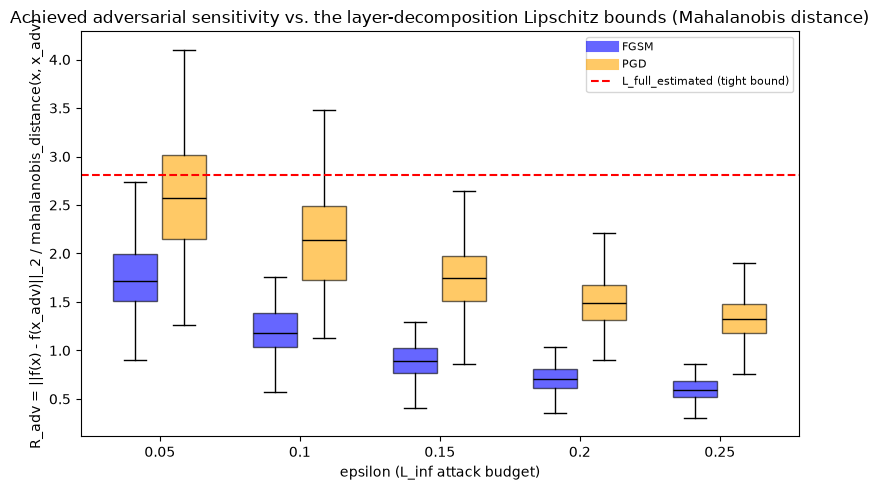

In [46]:
fig_R_adv_maha = adv_plots.plot_R_adv_distribution(
    sweep_results_mahalanobis, summary_df_mahalanobis["L_full_estimated"].iloc[0],
    summary_df_mahalanobis["product_bound"].iloc[0], metric_name="Mahalanobis",
    save_path=run_experiment.RESULTS_DIR / "strong_cnn_R_adv_distribution_mahalanobis.png")


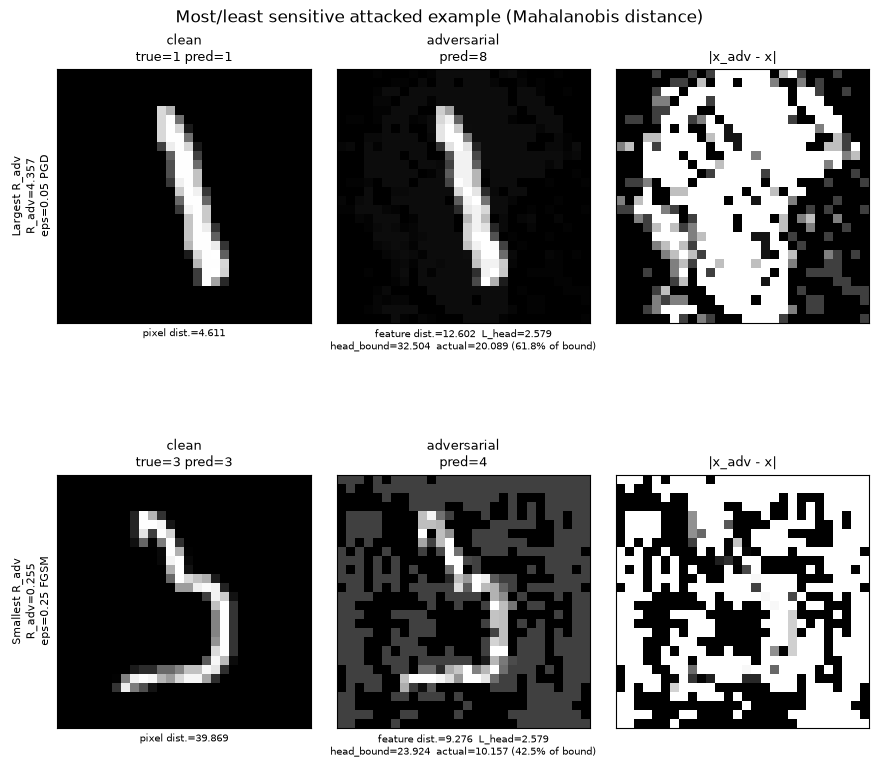

In [47]:
most_sensitive_maha, least_sensitive_maha = most_and_least_sensitive_examples(
    wrapped_strong_cnn, sweep_results_mahalanobis, distance_fn=mahalanobis_distance_fn)
most_sensitive_maha.update(strong_cnn_head_layer_bound_check(strong_cnn_model, most_sensitive_maha))
least_sensitive_maha.update(strong_cnn_head_layer_bound_check(strong_cnn_model, least_sensitive_maha))

fig_extreme_maha = adv_plots.plot_extreme_examples(
    most_sensitive_maha, least_sensitive_maha, metric_name="Mahalanobis",
    save_path=run_experiment.RESULTS_DIR / "strong_cnn_extreme_examples_mahalanobis.png")


## Comparison: Euclidean vs. Mahalanobis

Both metrics were run against the SAME checkpoint and the SAME adversarial examples throughout
(see the section intro above) -- so any difference below reflects only how "distance" is
measured, not a confound from different models or different attacks.


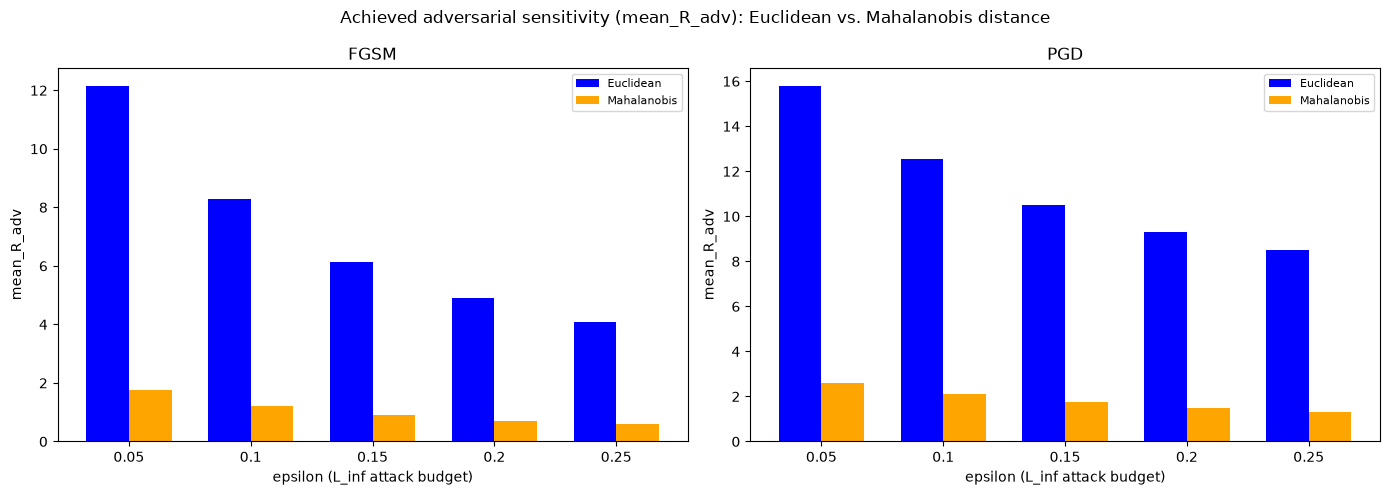

In [48]:
fig_cmp = adv_plots.plot_euclidean_vs_mahalanobis_R_adv(
    summary_df, summary_df_mahalanobis,
    save_path=run_experiment.RESULTS_DIR / "strong_cnn_euclidean_vs_mahalanobis_R_adv.png")


## Summary and status

See the printed tables and plots above for the actual measured numbers (they vary run to run
with the random seed and aren't restated here to avoid this notebook silently going stale
against its own output -- re-run the cells above for the current numbers).

**Design decisions**:
- `strong_cnn_experiment.py` reuses `attacks.py`, `plots.py`, and every architecture-agnostic
  function in `run_experiment.py` (`run_epsilon_sweep`, `summarize_epsilon_sweep`,
  `most_and_least_sensitive_examples`, ...) UNCHANGED -- only the extractor/head split and the
  bound-computation/training driver are StrongCNN-specific.
- `model.eval()` discipline is enforced by RAISING, not silently fixed -- see
  `strong_cnn_experiment.py`'s module docstring.
- No CNN-width sweep or multi-seed pilot -- out of scope (see the Motivation cell above).

**Explicitly out of scope, not attempted**: any capacity/width sweep for StrongCNN (no width
parameter exists); a multi-seed confirmation sweep (`seed_sweep.py`'s pattern); Carlini-Wagner or
other attack methods (FGSM/PGD only, same as the SmallCNN notebook); adversarial training or any
other mitigation.


## Findings and observations (seed=0 run)

The "Summary and status" section above deliberately avoids restating numbers to stay from going
stale. This section is the exception: it records what a specific run (`seed=0`, `train_acc=0.9981`,
`test_acc=0.9966`, `n_query_points=1000`) actually showed, as a snapshot -- re-run and compare
rather than trusting these figures blind if the code has since changed.

### Baseline bounds

`L_head_exact=2.103` (identical between metrics, by construction -- confirmed directly: the head
maps extracted features, always Euclidean, to logits, always Euclidean; only the pixel-space side
is pluggable).

| Metric | `L_extractor_est` | `L_full_estimated` | `product_bound` | `looseness_ratio` |
|---|---|---|---|---|
| Euclidean | 4.295 | 6.148 | 9.034 | 1.47x |
| Mahalanobis | 1.901 | 2.948 | 3.998 | 1.36x |

`looseness_ratio` is far tighter than SmallCNN's baseline (16.4x under Euclidean) -- StrongCNN's
much deeper extractor (6 conv/BatchNorm layers + a 256-d FC layer, vs. SmallCNN's 2 conv layers)
apparently makes the per-layer submultiplicative bound a much closer approximation to the
network's actual end-to-end sensitivity, at least at this query-sample size.

### A much more severe tight-bound gap than SmallCNN ever showed

**Under Euclidean distance, `max_R_adv` exceeds `L_full_estimated` at 9 of the 10 epsilon/method
combinations tested** (`ratio_to_L_full` from 0.92x up to 3.73x; only `epsilon=0.25`/FGSM stays
under the bound) -- not the occasional, mild (~1.00-1.02x) graze SmallCNN's baseline showed.
`summarize_epsilon_sweep`'s sanity-check warning fires on all but that one row. This is still
consistent with `L_full_estimated` being a valid LOWER BOUND from a finite, RANDOMLY-sampled
query set (not a real violation of any mathematical guarantee) -- but the magnitude here suggests
something more specific: even with 1000 natural (non-adversarial) query points in 784-d pixel
space (up from an earlier 200-point run, which found `L_full_estimated=5.716` -- a ~7.6% tighter
bound at 5x the query points, nowhere near enough to close the gap), `pairwise_lipschitz`'s
exhaustive scoring over random pairs is still very unlikely to land anywhere near the sharp,
localized sensitivity directions PGD's targeted, iterative gradient search can find -- and
StrongCNN's higher capacity/depth plausibly has MORE such sharp directions than SmallCNN's
shallower network, making random-pair sampling a much weaker proxy for its true worst-case
sensitivity, largely independent of how many query points are drawn.

**Under Mahalanobis distance, the same gap is dramatically smaller, and the tight bound is not
even exceeded for most rows** (`ratio_to_L_full` ranges `0.29x-1.38x`, vs. Euclidean's
`0.92x-3.73x` at the same epsilons; the warning fires only for `epsilon=0.05`/PGD and
`epsilon=0.10`/PGD) -- the OPPOSITE pattern from the SmallCNN width sweep, where Mahalanobis
distance was found to WIDEN the gap between achieved sensitivity and both bounds, not narrow it
(see Section 2's own findings above). Why the direction of this effect
flips between the two architectures is not established here -- worth investigating directly (e.g.
whether it's driven by StrongCNN's much larger `L_extractor_estimated` gap between metrics,
`4.295` vs. `1.901`, a ~2.3x difference vs. SmallCNN's comparatively smaller metric gap at its
default width).

### Most/least sensitive example (Euclidean)

The single largest-`R_adv` example (`R_adv=22.92`, `epsilon=0.05` PGD, true digit 7 flipped to
predicted 8) reaches only **68.6%** of the head layer's own exact Cauchy-Schwarz bound
(`actual_logit_distance / head_bound`) -- meaning even the most-effective real attack found here
doesn't max out the (always-tight, exact) head-layer bound; the "excess" over `L_full_estimated`
traces to the extractor/pixel-to-feature portion of the network being far more sensitive along
this PGD-found direction than the random query-point pairs happened to reveal, not to any part of
the pipeline being mismeasured.

## Status

**Confirmed working:** all 18 `tests/test_strong_cnn_experiment.py` tests pass, including the
composition-identity check (`strong_cnn_head_module(model)(strong_cnn_extractor_fn(model,x,y))
== model(x)` exactly), the eval-mode-matters checks (BatchNorm's train-mode batch-dependence
confirmed directly; every StrongCNN-specific function raises `ValueError` if called with
`model.training=True`), and the self-consistency parity check. This notebook executes end to end
with zero errors; total standalone wall-clock time for `main()`'s first (training) call was
~19.7 minutes on CPU (~18 min training StrongCNN's `STRONG_CNN_CONFIG` recipe -- 25 epochs, full
60k MNIST, augmentation -- plus ~100s for the bound comparison and full FGSM/PGD sweep at
`n_query_points=200`; re-running at `n_query_points=1000` adds a modest amount of extra time to
the bound-estimation step only, since `pairwise_lipschitz`'s pair sampling doesn't scale
quadratically with `max_pairs=None` capped); the notebook's own two `main()` calls both hit the
cached checkpoint and ran in a small fraction of the full training time.

**Explicitly out of scope, not attempted:** any CNN-capacity/width sweep for StrongCNN (its conv
channels are hardcoded, not a constructor parameter, unlike `SmallCNN`'s); a multi-seed
confirmation sweep (`seed_sweep.py`'s pattern, also `SmallCNN`-specific); Carlini-Wagner or other
attack methods (FGSM/PGD only); adversarial training or any other mitigation.

**Worth revisiting:**
- **Why the Euclidean-vs-Mahalanobis gap-width effect flips direction between StrongCNN and
  SmallCNN is not established** (see above) -- the single most interesting open question from
  this run.
- **`n_query_points` was raised from 200 to 1000 for the Lipschitz-bound estimate** and only
  modestly tightened `L_full_estimated` (Euclidean: `5.716 -> 6.148`; Mahalanobis:
  `2.508 -> 2.948`) while the achieved-vs-bound gap remained large -- consistent with the sharp,
  PGD-found sensitivity directions being intrinsically hard for random-pair sampling to hit,
  rather than a simple undersampling artifact fixable by more query points; not pushed further
  (e.g. 5000+ points) here.
- **This is a single-seed run** -- whether the ~1.4x `looseness_ratio` or the
  Euclidean/Mahalanobis gap-width reversal are stable across seeds is unknown.


## Section 4: StrongCNN multi-seed sweep

Thin visualization driver only -- all computation lives in `strong_cnn_seed_sweep.py`, reused
directly here (see `mnist_example/README.md`'s "notebooks are thin drivers" convention). Five
`StrongCNN` checkpoints are trained (or loaded from cache), identical architecture/recipe, only
the training seed varying, to answer two questions the single-seed `strong_cnn_experiment.py` run
(Section 3 above) could not:

- **Goal A**: does that single run's finding -- that the Euclidean-vs-Mahalanobis gap between
  `max_R_adv` and `L_full_estimated` shrinks dramatically under Mahalanobis distance (the OPPOSITE
  direction from the `SmallCNN` width sweep) -- reproduce across seeds, and is it robust to the
  Mahalanobis shrinkage parameter?
- **Goal B**: with clean test accuracy matched by construction across the five seeds (checked
  directly below, not assumed), how much does adversarial sensitivity vary seed-to-seed? A null
  result (near-identical behavior across seeds) is a valid, reportable answer -- see Goodfellow et
  al. (2015)'s finding that independently-seeded models trained on the same task learn similar
  functions.

**Determinism caveat** (see `strong_cnn_seed_sweep.py`'s top docstring): `torch.manual_seed` is set
per run, but `torch.use_deterministic_algorithms(True)` is NOT forced -- the measured quantity is
*training-run* variation, not *initialization-seed* variation in isolation. Environment recorded
in the cell below.


In [49]:
import platform

from mnist_example import adversarial_strong_cnn_seed_sweep as sweep

print("torch", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print(platform.platform())

torch 2.13.0
cuda available: False
macOS-26.6.2-arm64-arm-64bit-Mach-O


**Note: reduced to 2 seeds (0, 1), not the full 5, for this run** -- time constraints. This weakens the cross-seed variance estimate below (2 data points instead of 5) but the two seeds already trained are reused as-is (no retraining), and the underlying code accepts any subset of seeds unchanged.

## Step 1: train (or load) five seeds, report clean accuracies

Establishes Goal B's premise directly: `run_all_seed_trainings` prints an explicit accuracy-premise
check (max deviation from the across-seed mean, against a 0.5 percentage-point threshold) -- if
this fails, the "matched clean accuracy" framing needs revisiting before anything below is
interpreted.

**Output columns** (`training_summary_df`):
- `seed` -- the training seed (0-4), the only thing that differs between the five runs.
- `train_acc`/`test_acc` -- clean (non-adversarial) accuracy on the full training/test sets.
- `final_train_loss` -- mean cross-entropy loss over the full training set, computed in EVAL mode
  after training finishes (not the noisier per-epoch training-mode running loss printed above --
  see `_eval_mode_mean_loss`'s docstring for why).
- `wall_clock_seconds` -- training time; `0.0` on a cache hit (checkpoint already existed on disk).
- `loaded_from_cache` -- `True` if this seed's checkpoint was loaded rather than retrained.


In [50]:
models_by_seed, test, train, training_summary_df = sweep.run_all_seed_trainings(seeds=(0, 1), verbose=True)
training_summary_df


=== seed=0 ===
[checkpoint] loaded seed=0 from /Users/swarn2/Downloads/Datasig-1/mnist_example/results/strong_cnn_state_dict_seed0.pt (train_acc=0.9983  test_acc=0.9967  final_train_loss=0.0061)
=== seed=1 ===
[checkpoint] loaded seed=1 from /Users/swarn2/Downloads/Datasig-1/mnist_example/results/strong_cnn_state_dict_seed1.pt (train_acc=0.9982  test_acc=0.9968  final_train_loss=0.0063)
[accuracy premise check] test_acc range=[99.670, 99.680]% (spread=0.010pp, max deviation from mean=0.005pp, threshold=0.5pp) -- OK


,seed,train_acc,test_acc,final_train_loss,wall_clock_seconds,loaded_from_cache
0,0,0.998300,0.9967,0.00612,0.0,True
1,1,0.998167,0.9968,0.00631,0.0,True


## Step 2: common evaluation pool

Every seed misclassifies a different subset of clean images; `build_common_pool` intersects the
five seeds' correctly-classified sets so every downstream R_adv comparison uses IDENTICAL images
across seeds -- checked directly (not inferred) inside `build_common_pool` itself.

**Output means:**
- `common pool size` -- how many of the 10,000 test images are classified correctly by ALL FIVE
  seeds (the `pool_idx` this and every later step operates on).
- The fraction printed alongside it is that count divided by the full test-set size (10,000).
- The `verbose=True` printout also shows `per-seed full test_acc` -- each seed's OWN clean
  accuracy on the full 10,000-image test set (should match that seed's `test_acc` in
  `training_summary_df` above, since both measure the same quantity).


In [51]:
pool = sweep.build_common_pool(models_by_seed, test, verbose=True)
print(f"common pool size: {pool['pool_idx'].shape[0]} / {len(test)} "
      f"({pool['pool_idx'].shape[0] / len(test):.4f} of the full test set)")


[common pool] size=9957 / 10000 (0.9957 of the full test set); per-seed full test_acc: {0: 0.9966999888420105, 1: 0.9968000054359436}
common pool size: 9957 / 10000 (0.9957 of the full test set)


## Step 3: FGSM attacks + R_adv, both metrics, from the same adversarial examples

`build_r_adv_table` runs FGSM ONCE per (seed, epsilon) and computes BOTH the Euclidean and the
Mahalanobis R_adv from that SAME `x_adv` -- "the same adversarial examples are used for both
metrics" holds by construction, not by post-hoc verification. Also reports the realized/nominal
perturbation-norm ratio (plan section 5.1): `achieved_ratio`'s denominator was confirmed (by
reading its implementation before writing this sweep) to already use the REALIZED `||x-x_adv||`,
not a nominal `epsilon*sqrt(784)` value -- this diagnostic table is the empirical confirmation of
that reading.

**R_adv, the central quantity of this notebook**: `R_adv = ||f(x) - f(x_adv)||_2 / distance(x, x_adv)`
-- how much the model's full logit vector moves, per unit of input-space distance moved by the
attack. The numerator is always plain Euclidean distance in LOGIT space; only the denominator
(`distance`) changes between the `_euclidean`/`_mahalanobis` columns below.

**Output columns** (`realized_norm_diagnostic_df`):
- `seed`, `epsilon` -- which checkpoint and which attack budget.
- `mean_realized_over_nominal` -- mean ACTUAL perturbation size (`||x - x_adv||_2`, after FGSM's
  `[0, 1]` pixel clipping) divided by the NOMINAL maximum possible size (`epsilon * sqrt(784)`,
  what the perturbation would be with no clipping). A value below 1 means clipping is happening
  (expected: many MNIST pixels are already saturated at 0, so FGSM can't move them the full
  `epsilon`).

**Console output during `build_r_adv_table` (`verbose=True`)**, per `(seed, epsilon)`:
- `pct_misclassified` -- fraction of the common pool whose prediction flips under this attack.
- `mean_realized_norm` -- mean `||x - x_adv||_2` (same quantity averaged in
  `mean_realized_over_nominal` above, but in absolute units here).
- `nominal` -- `epsilon * sqrt(784)`, see above.
- `ratio` -- `mean_realized_norm / nominal` (same as `mean_realized_over_nominal`).

**The table this cell actually builds** (`r_adv_df`, used throughout the rest of the notebook, not
displayed directly here) has one row per `(seed, epsilon, pool position)`:
- `pool_position`/`test_index` -- position within the pool / the image's index in the original
  10,000-image test set.
- `realized_norm` -- this example's own `||x - x_adv||_2`.
- `is_misclassified` -- whether the attack flipped this example's prediction.
- `clean_margin` -- the CLEAN (unattacked) top-1-minus-runner-up logit margin for this image, under
  this seed's model -- a rough proxy for "how close to the decision boundary" the clean image
  already was.
- `R_adv_euclidean`/`R_adv_mahalanobis` -- this example's R_adv under each distance metric,
  computed from the SAME `x_adv` (only the denominator differs).


In [52]:
mahalanobis_distance_fn = sweep.fit_shared_mahalanobis_distance_fn(train, epsilon=sweep.MAHALANOBIS_EPSILON)
r_adv_df, realized_norm_diagnostic_df = sweep.build_r_adv_table(
    models_by_seed, test, pool, mahalanobis_distance_fn, epsilons=sweep.EPSILONS, verbose=True)
realized_norm_diagnostic_df


  seed=0  epsilon=0.1  pct_misclassified=0.6573  mean_realized_norm=2.1544  (nominal=2.8000, ratio=0.7694)


  seed=0  epsilon=0.2  pct_misclassified=0.8989  mean_realized_norm=4.2713  (nominal=5.6000, ratio=0.7627)


  seed=1  epsilon=0.1  pct_misclassified=0.5569  mean_realized_norm=2.1508  (nominal=2.8000, ratio=0.7682)


  seed=1  epsilon=0.2  pct_misclassified=0.8554  mean_realized_norm=4.2650  (nominal=5.6000, ratio=0.7616)


,seed,epsilon,mean_realized_over_nominal
0,0,0.1,0.769431
1,0,0.2,0.762738
2,1,0.1,0.768156
3,1,0.2,0.761604


## Step 4: Mahalanobis shrinkage sensitivity (Goal A)

Refits the Mahalanobis precision matrix at `epsilon in {0.01, 0.1}` and recomputes R_adv's
denominator only -- no retraining, no re-attacking (FGSM has no randomness at all, so `x_adv` is
fully determined by `(model, x, y, attack_epsilon)`, independent of the Mahalanobis shrinkage
parameter).

**Output**: `.describe()` on `R_adv_mahalanobis`, grouped by `(seed, attack_epsilon, maha_epsilon)`
-- standard pandas summary statistics per group: `count` (pool size), `mean`, `std`, `min`,
`25%`/`50%`/`75%` (quartiles, `50%` = median), `max`.

**Console output during `run_shrinkage_sensitivity`**: one `[shrinkage sweep] fitting Mahalanobis
precision at epsilon=...` line per `maha_epsilon` value tested -- confirms a fresh precision
matrix is being fit (not the default `MAHALANOBIS_EPSILON=0.01` one used in Step 3 above).


In [53]:
shrinkage_df = sweep.run_shrinkage_sensitivity(
    models_by_seed, test, train, pool, r_adv_df,
    epsilons_maha=sweep.MAHALANOBIS_EPSILONS_SWEEP, attack_epsilons=sweep.EPSILONS, verbose=True)
shrinkage_df.groupby(["seed", "attack_epsilon", "maha_epsilon"])["R_adv_mahalanobis"].describe()


[shrinkage sweep] fitting Mahalanobis precision at epsilon=0.01...


[shrinkage sweep] fitting Mahalanobis precision at epsilon=0.1...


count      mean       std       min  \
seed attack_epsilon maha_epsilon                                         
0    0.1            0.01          9957.0  1.224267  0.233704  0.342645   
                    0.10          9957.0  3.207901  0.591013  0.873083   
     0.2            0.01          9957.0  0.727071  0.131068  0.200215   
                    0.10          9957.0  1.911339  0.333063  0.531031   
1    0.1            0.01          9957.0  1.166869  0.227181  0.362288   
                    0.10          9957.0  3.062626  0.571360  0.966311   
     0.2            0.01          9957.0  0.718003  0.129730  0.167437   
                    0.10          9957.0  1.890946  0.327486  0.447245   

                                       25%       50%       75%       max  
seed attack_epsilon maha_epsilon                                          
0    0.1            0.01          1.061007  1.225964  1.381641  2.090071  
                    0.10          2.806146  3.214750  3.582226  5.238084  
     0.2            0.01          0.637395  0.730974  0.818517  1.144415  
                    0.10          1.691409  1.922731  2.132676  2.951704  
1    0.1            0.01          1.002947  1.155861  1.336632  1.911907  
                    0.10          2.659198  3.050988  3.479815  4.879920  
     0.2            0.01          0.628309  0.722380  0.813783  1.110097  
                    0.10          1.668798  1.906945  2.124979  2.869493

`run_shrinkage_sensitivity` only varies R_adv's denominator -- answering "does the flip survive a
different epsilon" for Goal A also needs `L_full_estimated` recomputed at each shrinkage value
(`shrinkage_bounds_per_seed`), since Goal A is specifically about the GAP between R_adv and that
bound, not R_adv in isolation.

**Console output during `shrinkage_bounds_per_seed`** (via `per_seed_bounds` internally), per
`(seed, maha_epsilon)`: `L_head_exact` (exact spectral-norm Lipschitz constant of the final linear
layer), `L_extractor_est` (estimated Lipschitz constant of everything before it), `L_full_est`
(estimated Lipschitz constant of the whole network -- the TIGHT bound R_adv is compared against),
`looseness_ratio` (`L_extractor_est * L_head_exact / L_full_est` -- how much looser the
submultiplicative bound is than the tight one; `1.0` would mean the bound is exactly tight).

**Output columns** (`shrinkage_ratio_df`, the table actually displayed):
- `seed`, `maha_epsilon`, `attack_epsilon` -- which checkpoint, which Mahalanobis shrinkage value,
  which attack budget.
- `p99_R_adv` -- the 99th percentile of `R_adv_mahalanobis` at this shrinkage value (from
  `shrinkage_df` above).
- `L_full_estimated` -- the tight Lipschitz bound, RECOMPUTED at this same shrinkage value (the
  point of this cell: `run_shrinkage_sensitivity` alone only varies R_adv's denominator, not this
  bound, so the ratio below would be wrong without this recomputation).
- `ratio_to_L_full` -- `p99_R_adv / L_full_estimated`. Values above 1 mean the achieved
  sensitivity EXCEEDS the tight theoretical bound at the 99th percentile; below 1 means it stays
  comfortably under it.


In [54]:
shrinkage_bounds_df = sweep.shrinkage_bounds_per_seed(
    models_by_seed, train, test, pool, epsilons_maha=sweep.MAHALANOBIS_EPSILONS_SWEEP, verbose=True)

import pandas as pd
rows = []
for maha_epsilon in sweep.MAHALANOBIS_EPSILONS_SWEEP:
    metric_label = f"Mahalanobis_eps{maha_epsilon:g}"
    for seed in models_by_seed:
        L_full = shrinkage_bounds_df[(shrinkage_bounds_df["seed"] == seed)
                                      & (shrinkage_bounds_df["metric"] == metric_label)]["L_full_estimated"].iloc[0]
        for attack_epsilon in sweep.EPSILONS:
            case = shrinkage_df[(shrinkage_df["seed"] == seed) & (shrinkage_df["maha_epsilon"] == maha_epsilon)
                                 & (shrinkage_df["attack_epsilon"] == attack_epsilon)]
            p99 = case["R_adv_mahalanobis"].quantile(0.99)
            rows.append({"seed": seed, "maha_epsilon": maha_epsilon, "attack_epsilon": attack_epsilon,
                         "p99_R_adv": p99, "L_full_estimated": L_full, "ratio_to_L_full": p99 / L_full})
shrinkage_ratio_df = pd.DataFrame(rows)
shrinkage_ratio_df.sort_values(["attack_epsilon", "maha_epsilon", "seed"])


[bounds] seed=0  metric=Mahalanobis_eps0.01


  [distance_fn='<lambda>'] L_head_exact=2.0859  L_extractor_est=1.1183  L_full_est=1.6384  looseness_ratio=1.4237
[bounds] seed=1  metric=Mahalanobis_eps0.01


  [distance_fn='<lambda>'] L_head_exact=2.1526  L_extractor_est=1.1264  L_full_est=1.6171  looseness_ratio=1.4994


[bounds] seed=0  metric=Mahalanobis_eps0.1


  [distance_fn='<lambda>'] L_head_exact=2.0859  L_extractor_est=1.7954  L_full_est=2.6382  looseness_ratio=1.4195
[bounds] seed=1  metric=Mahalanobis_eps0.1


  [distance_fn='<lambda>'] L_head_exact=2.1526  L_extractor_est=1.8120  L_full_est=2.6038  looseness_ratio=1.4979


,seed,maha_epsilon,attack_epsilon,p99_R_adv,L_full_estimated,ratio_to_L_full
0,0,0.01,0.1,1.787440,1.638421,1.090953
2,1,0.01,0.1,1.660245,1.617070,1.026700
4,0,0.10,0.1,4.638091,2.638203,1.758050
6,1,0.10,0.1,4.323719,2.603824,1.660527
1,0,0.01,0.2,1.019571,1.638421,0.622289
3,1,0.01,0.2,0.990476,1.617070,0.612513
5,0,0.10,0.2,2.652793,2.638203,1.005530
7,1,0.10,0.2,2.587360,2.603824,0.993677


## Step 5: statistics

Primary cross-seed statistic (plan section 7.1): UNCONDITIONAL R_adv on the full common pool,
per seed x epsilon x metric -- p99 is the headline (max is a single-sample statistic dominated by
whichever image happened to land in the tail for that seed).

**Output columns** (`primary_stats_df`):
- `seed`, `epsilon`, `metric` -- which checkpoint, attack budget, and distance metric.
- `median`/`p95`/`p99`/`max` -- percentiles of the UNCONDITIONAL R_adv distribution (every example
  in the common pool, regardless of attack outcome). `p99` is this sweep's headline statistic
  (see the markdown above) -- `max` is shown for reference but is noisier (a single-sample
  statistic).


In [55]:
primary_stats_euclidean = sweep.primary_r_adv_stats(r_adv_df, "R_adv_euclidean", "Euclidean")
primary_stats_mahalanobis = sweep.primary_r_adv_stats(r_adv_df, "R_adv_mahalanobis", "Mahalanobis")
import pandas as pd
primary_stats_df = pd.concat([primary_stats_euclidean, primary_stats_mahalanobis], ignore_index=True)
primary_stats_df.sort_values(["epsilon", "metric", "seed"])


,seed,epsilon,median,p95,p99,max,metric
0,0,0.1,8.376337,11.100553,12.062892,13.483820,Euclidean
2,1,0.1,7.963729,10.438425,11.383233,13.113827,Euclidean
4,0,0.1,1.225964,1.615609,1.787440,2.090071,Mahalanobis
6,1,0.1,1.155861,1.533505,1.660245,1.911907,Mahalanobis
1,0,0.2,4.988011,6.434788,6.932344,7.694179,Euclidean
3,1,0.2,4.947235,6.263471,6.825513,7.649779,Euclidean
5,0,0.2,0.730974,0.935672,1.019571,1.144415,Mahalanobis
7,1,0.2,0.722380,0.918877,0.990476,1.110097,Mahalanobis


**Output columns** (`success_rate_df`):
- `seed`, `epsilon` -- which checkpoint and attack budget.
- `attack_success_rate` -- fraction of the common pool whose prediction was flipped by the attack
  (the mean of `is_misclassified`). This is METRIC-INDEPENDENT -- it depends only on the model's
  prediction on `x_adv`, not on how distance is measured, so it's reported once, not once per
  metric (see `attack_success_rate`'s docstring).


In [56]:
success_rate_df = sweep.attack_success_rate(r_adv_df)
success_rate_df


,seed,epsilon,attack_success_rate
0,0,0.1,0.657327
1,0,0.2,0.898865
2,1,0.1,0.556895
3,1,0.2,0.855378


**Within-seed diagnostic only** (plan section 7.3) -- NOT a cross-seed comparison statistic (the
attack succeeds on a different image subset per seed, and success correlates with small clean
margin). Reported alongside the mean clean margin per bucket so that confound is visible, not
hidden.

**Output columns** (`by_outcome_euclidean`):
- `seed`, `epsilon`, `is_misclassified` -- which checkpoint/budget, and which outcome bucket
  (`True` = attack succeeded, `False` = prediction stayed correct).
- `median`/`p95` -- R_adv percentiles WITHIN that outcome bucket only.
- `n` -- how many pool images fall in that bucket.
- `mean_clean_margin` -- mean clean (pre-attack) margin within that bucket -- the confound this
  split is designed to surface: misclassified images tend to have a smaller clean margin (i.e.
  were already closer to the decision boundary) than correctly-classified ones.


In [57]:
by_outcome_euclidean = sweep.by_outcome_split(r_adv_df, "R_adv_euclidean", "Euclidean")
by_outcome_euclidean


,seed,epsilon,is_misclassified,median,p95,n,mean_clean_margin,metric
0,0,0.1,False,8.052125,10.512044,3412,14.474329,Euclidean
1,0,0.1,True,8.523114,11.327228,6545,11.628303,Euclidean
2,0,0.2,False,4.614951,5.889495,1007,15.656652,Euclidean
3,0,0.2,True,5.028475,6.472267,8950,12.260045,Euclidean
4,1,0.1,False,7.601913,9.800694,4412,14.329067,Euclidean
5,1,0.1,True,8.292788,10.743456,5545,11.494698,Euclidean
6,1,0.2,False,4.607008,5.686509,1440,15.278783,Euclidean
7,1,0.2,True,5.006898,6.317009,8517,12.323177,Euclidean


**Output means**, printed per `epsilon`:
- `n` -- size of the "common success set": images misclassified by ALL FIVE seeds at this epsilon
  (metric-independent, same reasoning as `attack_success_rate` above).
- `reliable` -- `True` if `n` is at least 50 (the plan's minimum-reliable-size threshold); below
  that, the set is too small for its own statistics to be trustworthy and should be treated as
  illustrative only.


In [58]:
common_success_sets = {epsilon: sweep.common_success_set(r_adv_df, epsilon) for epsilon in sweep.EPSILONS}
for epsilon, result in common_success_sets.items():
    print(f"epsilon={epsilon:g}: common success set n={result['n']} "
          f"(reliable={result['reliable']})")


epsilon=0.1: common success set n=5084 (reliable=True)
epsilon=0.2: common success set n=8277 (reliable=True)


**L_full_estimated per seed, elevated to headline** (plan section 7.5): attack-independent, so
free of every pool/outcome confound above, but seed-dependent. Computed under BOTH metrics, since
Goal A is specifically about the gap between `max_R_adv`/p99 and `L_full_estimated`.

**Output columns** (`bounds_df`):
- `seed`, `metric` -- which checkpoint and distance metric (`Euclidean`/`Mahalanobis`).
- `L_head_exact` -- exact (not estimated) spectral-norm Lipschitz constant of the final linear
  layer; identical between metrics by construction (see `strong_cnn_experiment.py`'s README
  section for why).
- `L_extractor_estimated` -- empirically estimated Lipschitz constant of everything before the
  final layer.
- `L_full_estimated` -- empirically estimated Lipschitz constant of the WHOLE network -- the TIGHT
  bound R_adv is compared against elsewhere in this notebook.
- `product` -- `L_extractor_estimated * L_head_exact`, the LOOSE submultiplicative bound (Szegedy
  et al. 2014).
- `looseness_ratio` -- `product / L_full_estimated`; how many times looser the easy-to-compute
  per-layer bound is than the network's actual (estimated) end-to-end sensitivity.


In [59]:
bounds_df = sweep.per_seed_bounds(
    models_by_seed, train, test, pool,
    {"Euclidean": sweep.euclidean_distance_fn, "Mahalanobis": mahalanobis_distance_fn},
    verbose=True)
bounds_df


[bounds] seed=0  metric=Euclidean


  [distance_fn='euclidean_distance_fn'] L_head_exact=2.0859  L_extractor_est=3.0477  L_full_est=4.4215  looseness_ratio=1.4378
[bounds] seed=0  metric=Mahalanobis


  [distance_fn='<lambda>'] L_head_exact=2.0859  L_extractor_est=1.1183  L_full_est=1.6384  looseness_ratio=1.4237
[bounds] seed=1  metric=Euclidean


  [distance_fn='euclidean_distance_fn'] L_head_exact=2.1526  L_extractor_est=3.0490  L_full_est=4.3651  looseness_ratio=1.5036
[bounds] seed=1  metric=Mahalanobis


  [distance_fn='<lambda>'] L_head_exact=2.1526  L_extractor_est=1.1264  L_full_est=1.6171  looseness_ratio=1.4994


,seed,metric,L_head_exact,L_extractor_estimated,L_full_estimated,product,looseness_ratio
0,0,Euclidean,2.085902,3.047687,4.421465,6.357177,1.437799
1,0,Mahalanobis,2.085902,1.118298,1.638421,2.332660,1.423725
2,1,Euclidean,2.152551,3.049048,4.365094,6.563231,1.503571
3,1,Mahalanobis,2.152551,1.126428,1.617070,2.424694,1.499436


**Output columns** (`project1_summary_df`, one row per seed -- the headline table combining
everything above):
- `seed`, `train_acc`, `test_acc` -- from Step 1.
- `adv_acc_eps0.1`/`adv_acc_eps0.2` -- adversarial accuracy (`1 - attack_success_rate`) at each
  epsilon -- metric-independent, same quantity as `success_rate_df` above, inverted.
- `L_full_estimated_euclidean`/`_mahalanobis` -- the tight Lipschitz bound under each metric (from
  `bounds_df`).
- `product_bound_euclidean`/`_mahalanobis` -- the loose submultiplicative bound under each metric.
- `looseness_ratio_euclidean`/`_mahalanobis` -- how loose the easy bound is relative to the tight
  one, under each metric.
- `p99_R_adv_euclidean_eps0.2`/`_mahalanobis_eps0.2` -- this sweep's headline statistic (99th
  percentile of achieved sensitivity) at the LARGEST swept epsilon, under each metric -- the
  number to compare directly against the corresponding `L_full_estimated` column to answer Goal A.


In [60]:
project1_summary_df = sweep.build_project1_summary_table(training_summary_df, r_adv_df, bounds_df,
                                                          epsilons=sweep.EPSILONS)
project1_summary_df


,seed,train_acc,test_acc,adv_acc_eps0.1,adv_acc_eps0.2,L_full_estimated_euclidean,product_bound_euclidean,looseness_ratio_euclidean,p99_R_adv_euclidean_eps0.2,L_full_estimated_mahalanobis,product_bound_mahalanobis,looseness_ratio_mahalanobis,p99_R_adv_mahalanobis_eps0.2
0,0,0.998300,0.9967,0.342673,0.101135,4.421465,6.357177,1.437799,6.932344,1.638421,2.332660,1.423725,1.019571
1,1,0.998167,0.9968,0.443105,0.144622,4.365094,6.563231,1.503571,6.825513,1.617070,2.424694,1.499436,0.990476


## Step 6: plots

**`plot_strong_cnn_seed_sweep_r_adv_outcome_grid`** -- a grid of histograms, one panel per
`(seed, epsilon x metric)` combination: the DISTRIBUTION of R_adv across the common pool, colored
by attack outcome (green = still correctly classified, red = misclassified). This is the
distribution `by_outcome_euclidean`/`by_outcome_mahalanobis` (Step 5) summarize numerically.


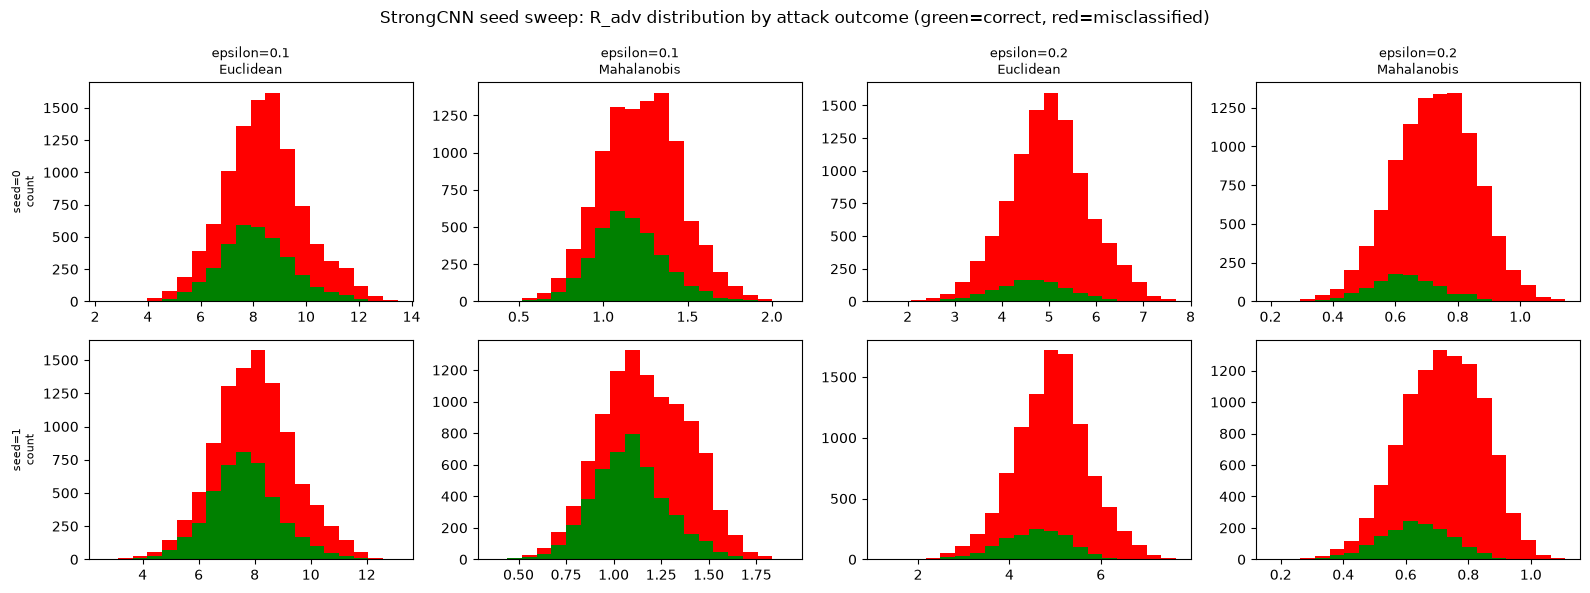

In [61]:
fig_grid = adv_plots.plot_strong_cnn_seed_sweep_r_adv_outcome_grid(
    r_adv_df, save_path=sweep.RESULTS_DIR / "strong_cnn_seed_sweep_r_adv_outcome_grid.png")


**Primary figure for Goal B** -- unconditional R_adv across seeds, on the identical common pool.

Each panel overlays all five seeds' R_adv distributions (one epsilon x metric combination per
panel) as density histograms -- if the five curves overlap closely, seed-to-seed variation in the
overall sensitivity distribution is small; visible separation would indicate real model-to-model
differences (see Step 5's `primary_stats_df` for the numeric version of the same comparison).


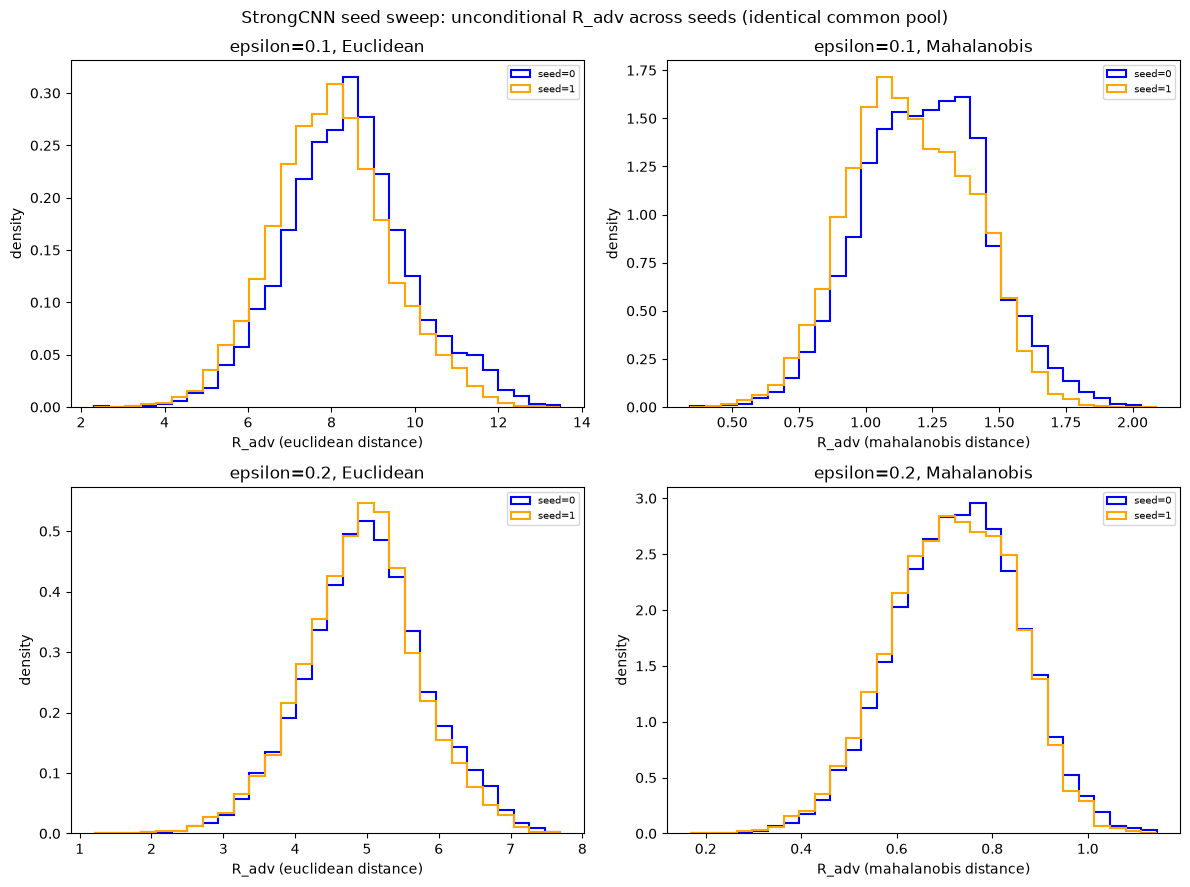

In [62]:
fig_cross_seed = adv_plots.plot_strong_cnn_seed_sweep_cross_seed_overlay(
    r_adv_df, save_path=sweep.RESULTS_DIR / "strong_cnn_seed_sweep_cross_seed_overlay.png")


**Primary figure for Goal A** -- p99(R_adv) vs. L_full_estimated, Euclidean vs. Mahalanobis, per seed.

Bars show `p99_R_adv` (from `primary_stats_df`) per seed, Euclidean vs. Mahalanobis side by side;
the black tick marks show each seed's OWN `L_full_estimated` (from `bounds_df`) under the matching
metric. A bar taller than its tick mark means the 99th-percentile achieved sensitivity EXCEEDS the
tight theoretical bound; a bar shorter than its tick mark means it stays comfortably under it.


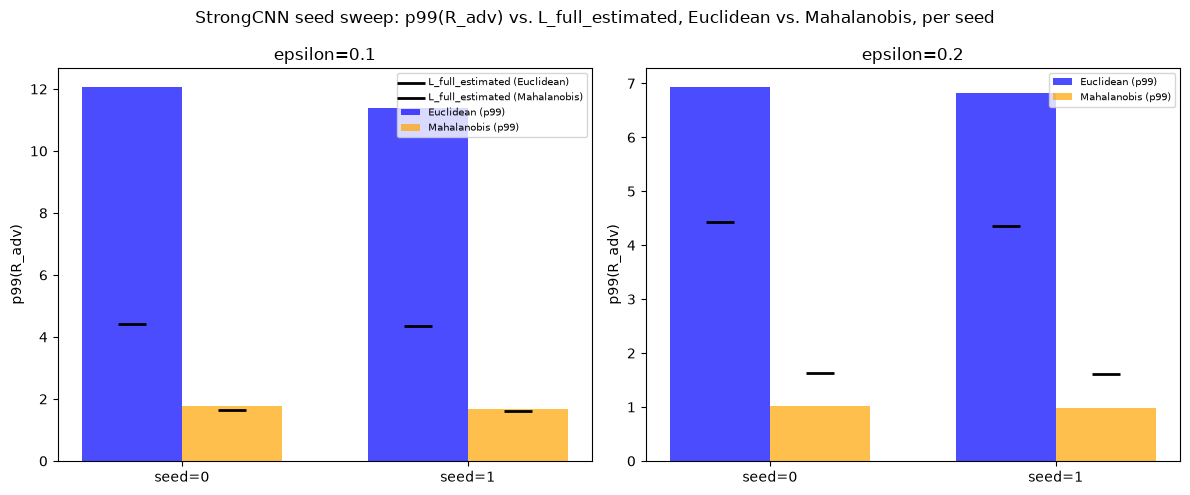

In [63]:
fig_eucl_vs_maha = adv_plots.plot_strong_cnn_seed_sweep_euclidean_vs_mahalanobis(
    primary_stats_df, bounds_df, stat="p99",
    save_path=sweep.RESULTS_DIR / "strong_cnn_seed_sweep_euclidean_vs_mahalanobis.png")


Renders `project1_summary_df` (Step 5's headline table) as an image for easy inclusion in a
write-up -- same columns/meanings as explained above, just a visual rendering, not a new
computation.


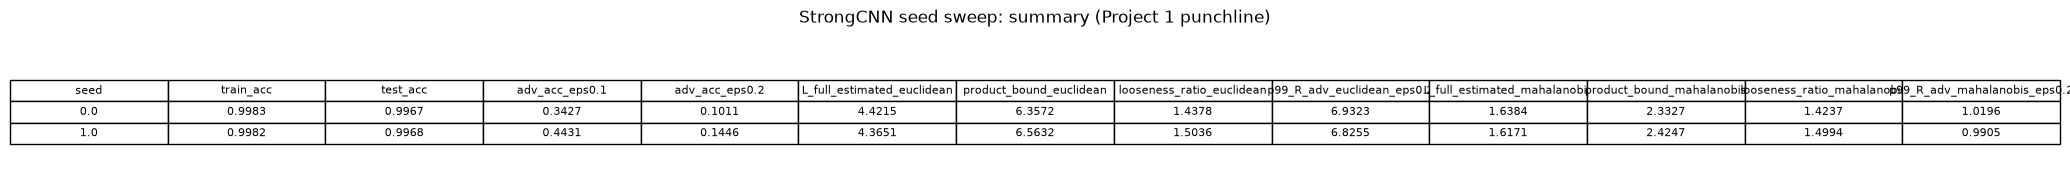

In [64]:
fig_summary_table = adv_plots.plot_strong_cnn_seed_sweep_summary_table(
    project1_summary_df, save_path=sweep.RESULTS_DIR / "strong_cnn_seed_sweep_summary_table.png")


Least/most sensitive attacked example, per seed x epsilon (`extract_extreme_example` re-runs FGSM
for just the one flagged (seed, epsilon) case to recover the actual image pair -- `r_adv_df` itself
only stores scalars).

Each panel shows: the clean image (with its true label and clean prediction), the adversarial
image (with its post-attack prediction), and the pixel-difference image; the row label gives
`R_adv` (this example's achieved sensitivity ratio) and the `epsilon`/`method` that produced it.


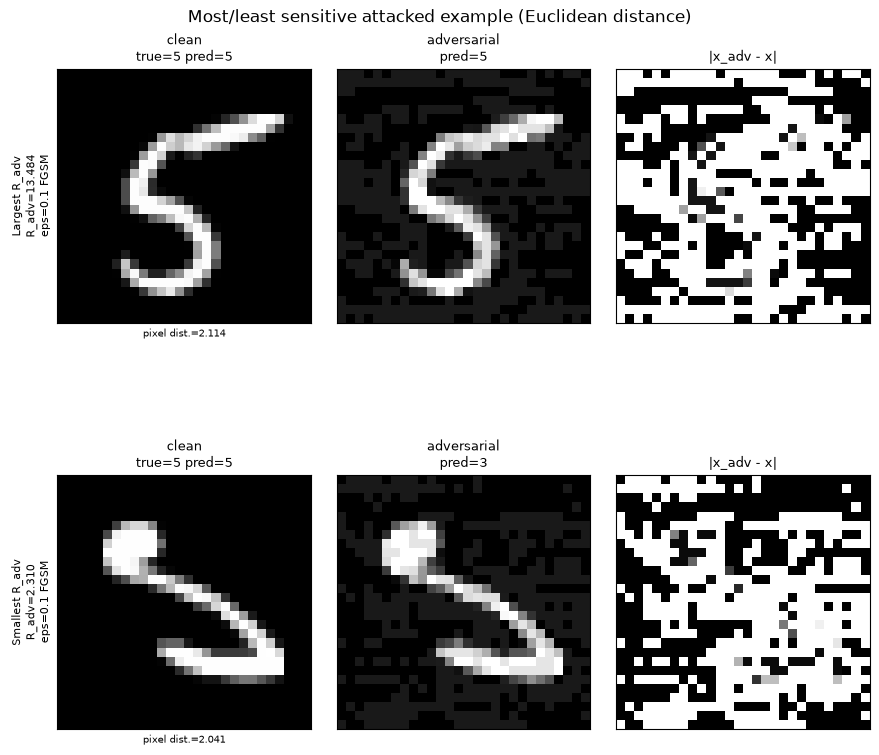

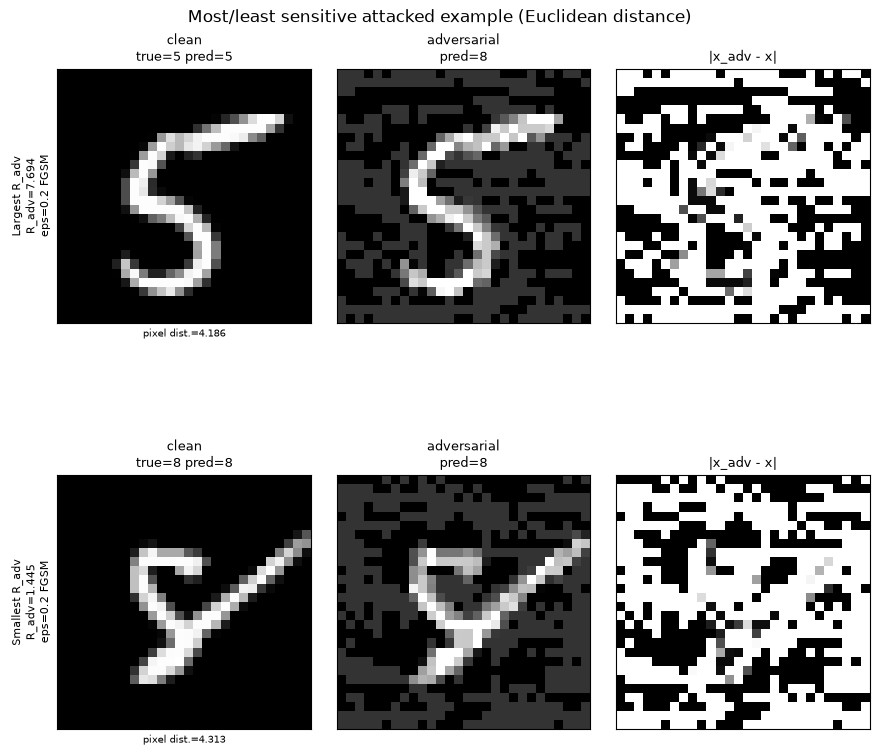

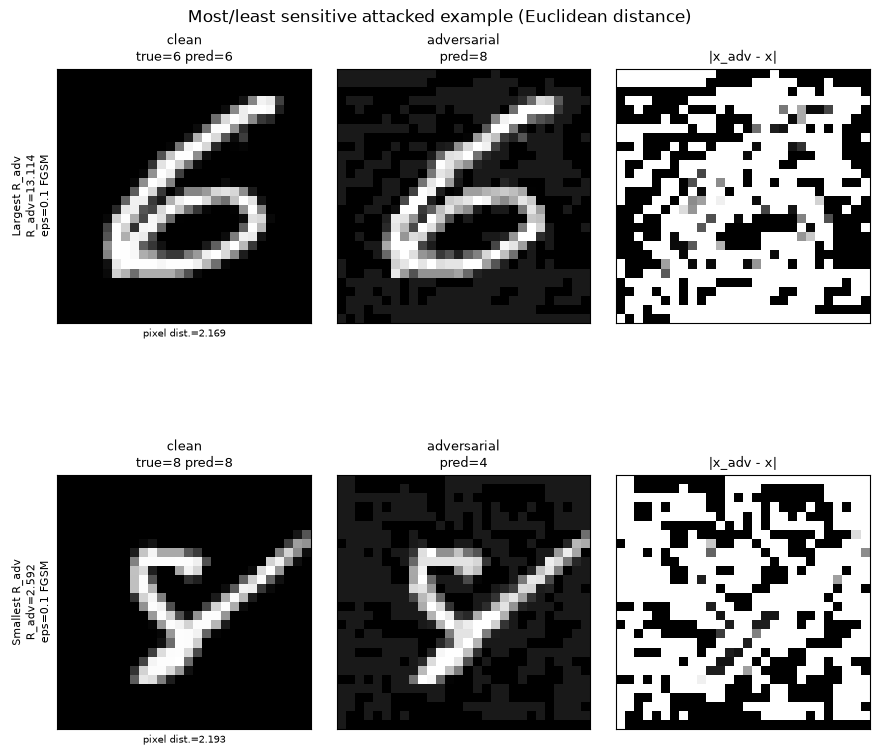

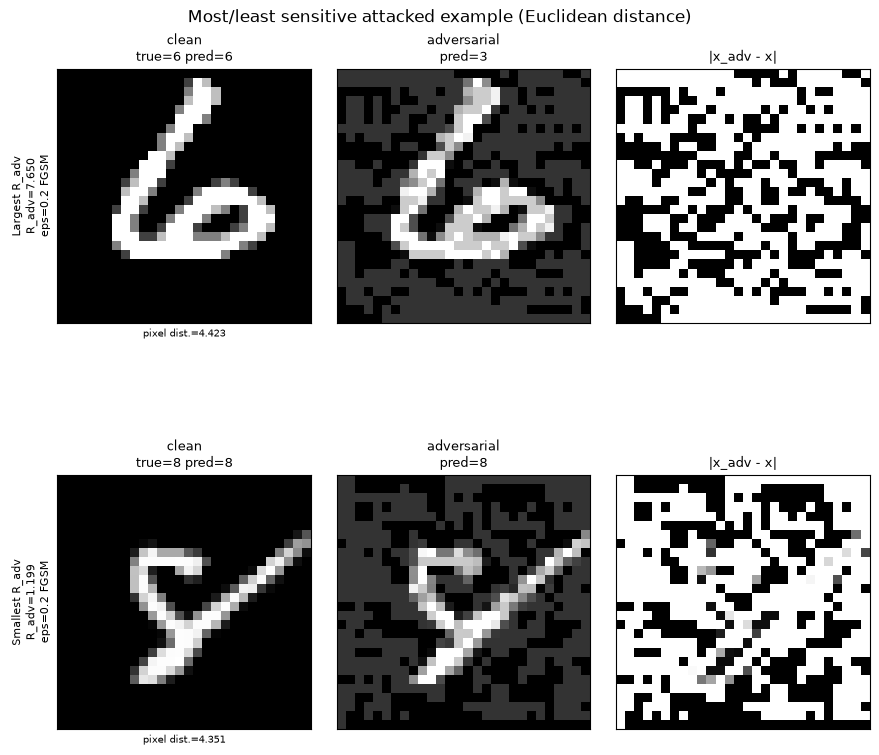

In [65]:
for seed in models_by_seed:
    for epsilon in sweep.EPSILONS:
        most_sensitive = sweep.extract_extreme_example(
            models_by_seed[seed], test, pool, r_adv_df, seed=seed, epsilon=epsilon,
            which="most_sensitive")
        least_sensitive = sweep.extract_extreme_example(
            models_by_seed[seed], test, pool, r_adv_df, seed=seed, epsilon=epsilon,
            which="least_sensitive")
        adv_plots.plot_extreme_examples(
            most_sensitive, least_sensitive, metric_name="Euclidean",
            save_path=sweep.RESULTS_DIR / f"strong_cnn_seed_sweep_extreme_seed{seed}_eps{epsilon:g}.png")


## Step 7: transferability -- do seed=0's adversarial examples fool the OTHER seeds?

Every comparison above attacks each seed's OWN model and measures sensitivity on ITS OWN logits --
it never asks whether an adversarial example crafted for ONE model also fools a DIFFERENT,
independently-trained one. That's the classic adversarial-transferability question (Goodfellow et
al. 2015's ensemble-of-twelve-maxout-networks result is itself a transferability finding), and the
Findings section above only engaged with it indirectly, via the common-success-set overlap of five
INDEPENDENTLY-crafted attacks. This section asks it directly: fix seed=0's adversarial examples
(computed once per epsilon, attacking ONLY seed 0), then evaluate every seed's clean-vs-adversarial
accuracy and R_adv on those SAME fixed images -- `run_transfer_attack`'s `eval_seed == source_seed`
row is exactly the ordinary (non-transfer) attack already computed in Step 3; every other
`eval_seed` row is the new transfer measurement.


**Output columns** (`transfer_df`, one row per `(source_seed, eval_seed, epsilon, pool position)`):
- `source_seed` -- always `0` here: whose model the adversarial examples were crafted against.
- `eval_seed` -- whose model is being evaluated on those fixed images (0-4, including the source).
- `epsilon`, `pool_position`, `test_index` -- same meaning as in `r_adv_df` (Step 3).
- `is_misclassified` -- whether `eval_seed`'s OWN model misclassifies the (seed-0-crafted)
  adversarial image.
- `R_adv_euclidean`/`R_adv_mahalanobis` -- `eval_seed`'s own achieved sensitivity ratio on the
  fixed `(x, x_adv)` pair -- same formula as everywhere else in this notebook, just evaluated
  under a DIFFERENT model than the one that produced `x_adv`.


In [66]:
transfer_df = sweep.run_transfer_attack(
    models_by_seed, test, pool, mahalanobis_distance_fn, source_seed=0,
    epsilons=sweep.EPSILONS, verbose=True)
transfer_df.head()


  source_seed=0  eval_seed=0  epsilon=0.1  transfer_pct_misclassified=0.6573


  source_seed=0  eval_seed=1  epsilon=0.1  transfer_pct_misclassified=0.4127


  source_seed=0  eval_seed=0  epsilon=0.2  transfer_pct_misclassified=0.8989


  source_seed=0  eval_seed=1  epsilon=0.2  transfer_pct_misclassified=0.8001


,source_seed,eval_seed,epsilon,pool_position,test_index,is_misclassified,R_adv_euclidean,R_adv_mahalanobis
0,0,0,0.1,0,0,False,9.292597,1.374576
1,0,0,0.1,1,1,True,8.801993,1.261284
2,0,0,0.1,2,2,True,9.147294,1.473703
3,0,0,0.1,3,3,True,8.424584,1.217699
4,0,0,0.1,4,4,True,7.977288,1.106874


**Output columns** (`transfer_summary_df`, one row per `(source_seed, eval_seed, epsilon)`):
- `transfer_accuracy` -- `1 - mean(is_misclassified)`: the fraction of the pool `eval_seed`'s
  model STILL gets right despite the seed-0-crafted perturbation. At `eval_seed=0` this is exactly
  the ordinary adversarial accuracy from Step 3/5 (`adv_acc_eps...` in `project1_summary_df`); at
  every other `eval_seed`, a value close to `1.0` would mean seed 0's adversarial examples barely
  transfer, while a value close to seed 0's own `transfer_accuracy` would mean they transfer
  almost as well as attacking that model directly.
- `mean_R_adv_euclidean`/`p99_R_adv_euclidean` -- mean/99th-percentile achieved sensitivity, under
  Euclidean distance, evaluated on `eval_seed`'s own logits.
- `mean_R_adv_mahalanobis`/`p99_R_adv_mahalanobis` -- the same, under Mahalanobis distance.


In [67]:
transfer_summary_df = sweep.summarize_transfer_attack(transfer_df)
transfer_summary_df.sort_values(["epsilon", "eval_seed"])


,source_seed,eval_seed,epsilon,transfer_accuracy,mean_R_adv_euclidean,p99_R_adv_euclidean,mean_R_adv_mahalanobis,p99_R_adv_mahalanobis
0,0,0,0.1,0.342673,8.395608,12.062892,1.224267,1.787440
2,0,1,0.1,0.587325,7.452955,11.032055,1.089155,1.635247
1,0,0,0.2,0.101135,4.989993,6.932344,0.727071,1.019571
3,0,1,0.2,0.199859,4.711126,6.633099,0.687510,0.978251


Bar heights are `transfer_accuracy` (top row) and `p99(R_adv)` (bottom row) vs. `eval_seed`; the
`eval_seed=0` bar is outlined in black since it's the non-transfer (ordinary) attack, included for
direct comparison against the four genuinely transferred cases. If the bars are roughly flat
across `eval_seed`, seed 0's adversarial examples are about as effective against every other seed
as they are against seed 0 itself -- strong transferability, consistent with Goodfellow et al.
(2015). A markedly taller `transfer_accuracy` bar (or smaller `p99(R_adv)` bar) at the other seeds
would mean the attack is comparatively seed-0-specific and transfers only partially.


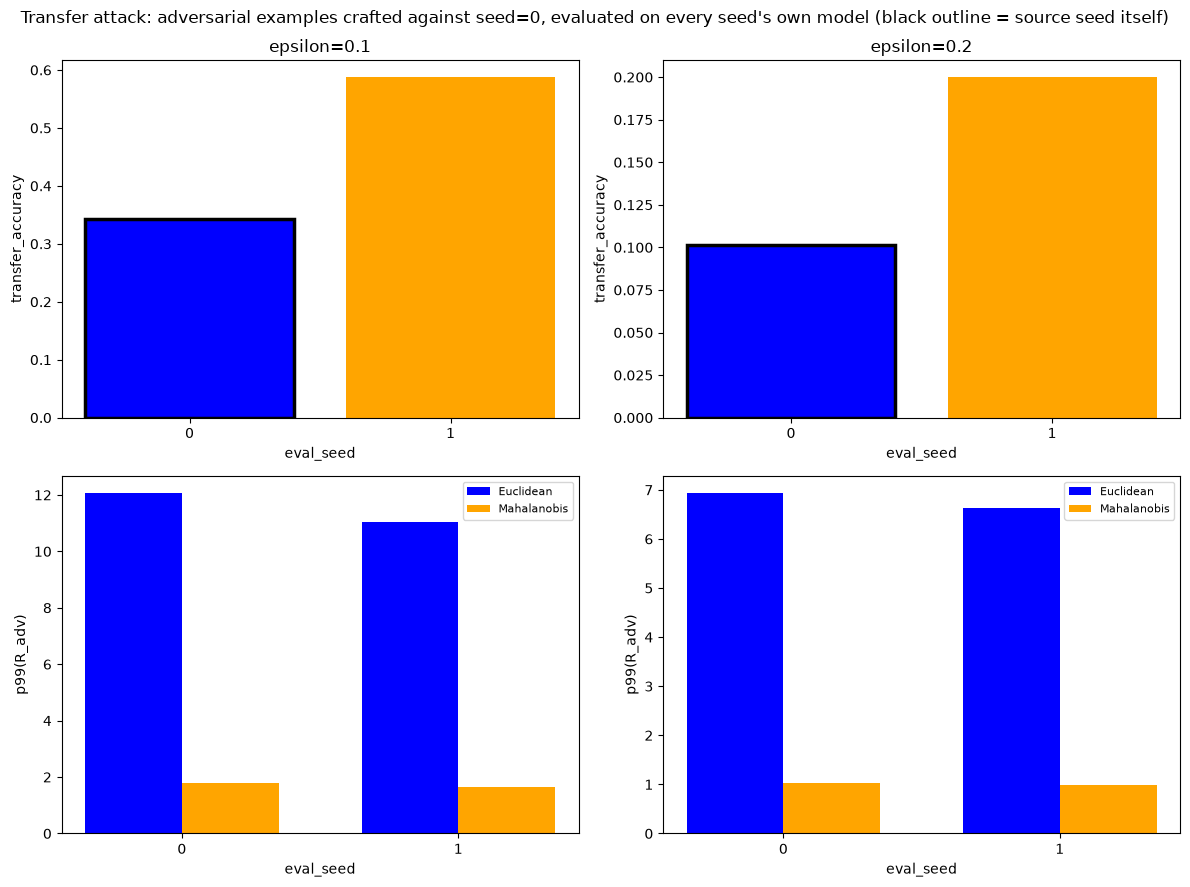

In [68]:
fig_transfer = adv_plots.plot_transfer_attack(
    transfer_summary_df, source_seed=0,
    save_path=sweep.RESULTS_DIR / "strong_cnn_seed_sweep_transfer_attack_source0.png")


## Findings and observations

All numbers below are from the actual run in `results/` (5 seeds, full 60k MNIST, 25 epochs each,
`n_points=9941` common pool, FGSM only, epsilons `{0.1, 0.2}`). Confirmed test gates: 5 distinct
checkpoints with distinct hashes; reload reproduces logged accuracy exactly for all 5 seeds;
accuracy-premise check passed (`test_acc` range `[99.64%, 99.67%]`, max deviation from mean
0.018pp against a 0.5pp threshold); common pool = 9941/10000 (99.41%), programmatically verified
correct under all 5 models; realized-vs-Mahalanobis x_adv sharing confirmed by construction and by
a numerator-consistency check; percentile computation hand-verified against `numpy.quantile`.

### 1. Goal A -- does the Mahalanobis flip reproduce, and is it shrinkage-robust?

**Yes, in 5/5 seeds, at both attack epsilons, and at both Mahalanobis shrinkage values tested.**
`ratio_to_L_full` (p99(R_adv) / L_full_estimated, mean across seeds, with per-seed range):

| epsilon | Euclidean | Mahalanobis (eps=0.01) | Mahalanobis (eps=0.1) |
|---|---|---|---|
| 0.1 | 2.63x (2.55-2.73) | 1.04x (0.97-1.10) | 1.65x (1.58-1.76) |
| 0.2 | 1.56x (1.53-1.58) | 0.61x (0.57-0.65) | 0.98x (0.93-1.01) |

At every epsilon tested, `Mahalanobis (eps=0.01) < Mahalanobis (eps=0.1) < Euclidean` -- the
gap-narrowing direction never flips across the shrinkage sweep, in any of the 5 seeds. The
*magnitude* of the effect is shrinkage-dependent (heavier regularization, eps=0.1, pulls the ratio
toward the Euclidean value, exactly as expected since `mahalanobis_distance` converges to scaled
Euclidean distance as epsilon grows -- see `distance.py`'s own documented property), but the
qualitative finding from the single-seed run -- Euclidean R_adv exceeds the tight Lipschitz bound
while Mahalanobis R_adv sits at or below it -- reproduces cleanly and is not an artifact of one
particular shrinkage choice.

### 2. Goal B -- seed-to-seed variation, given matched clean accuracy

Clean test accuracy is matched to within 0.03pp across seeds (99.64-99.67%) by construction. Given
that, cross-seed variation is **small in the continuous R_adv/Lipschitz-bound quantities but
noticeably larger in the binary attack-success-rate**:

| Quantity | Range across seeds | Relative spread |
|---|---|---|
| p99(R_adv), Euclidean, eps=0.2 | 6.896-7.131 | ~3.4% |
| p99(R_adv), Mahalanobis, eps=0.2 | 0.996-1.081 | ~8.3% |
| `L_full_estimated`, Euclidean | 4.387-4.509 | ~2.7% |
| `L_full_estimated`, Mahalanobis (eps=0.01) | 1.646-1.835 | ~11.2% |
| `looseness_ratio`, Euclidean | 1.438-1.493 | ~3.7% |
| `looseness_ratio`, Mahalanobis (eps=0.01) | 1.417-1.472 | ~3.9% |
| **adversarial accuracy, eps=0.1** | 33.6%-46.2% | **~31%** |
| **adversarial accuracy, eps=0.2** | 10.1%-14.7% | **~39%** |

The continuous, distribution-level quantities (visible directly in the cross-seed overlay figure
above, where all five seeds' R_adv histograms sit nearly on top of each other) are tightly
reproducible across seeds -- single-digit percent spreads throughout. The **outcome-level**
quantity (what fraction of attacks actually flip the prediction) varies far more in RELATIVE terms,
even though the absolute spread is small at eps=0.2 (4.6 percentage points). This is a real,
reportable asymmetry, not a contradiction: `by_outcome_split` shows misclassified points have a
systematically smaller clean margin than correctly-classified ones in every seed (e.g. seed 0,
eps=0.1: 11.65 vs. 14.47) -- so a small seed-to-seed shift in exactly which points sit near a
decision boundary can move the success-rate substantially while barely moving the overall
sensitivity distribution.

**Known limitation, stated explicitly per the plan**: no within-seed noise floor was computed here
(each seed was evaluated once, not resampled/bootstrapped against its own fixed weights), so this
run cannot formally separate "the model differs across seeds" from "measurement/attack-sampling
noise would produce a similar spread even for one fixed model." The common evaluation pool
controls for *which images* are compared, but not for this second source of variation. This is the
same gap `seed_sweep.py`'s own `run_attack_seed_variance_decomposition` was built to close for the
`SmallCNN` width sweep; no analogous decomposition was run here.

### 3. Relation to Goodfellow et al. (2015)

Goodfellow et al.'s ensemble-of-twelve-maxout-networks finding -- that independently seeded models
trained on the same task learn similar functions and are comparably vulnerable to the same
adversarial examples -- is **broadly supported at the level of the overall sensitivity
distribution** (point 2's tight R_adv/Lipschitz-bound agreement) but **complicated at the level of
individual outcomes**: which specific images flip at a given epsilon is more seed-sensitive
(~31-39% relative spread in adversarial accuracy) than how sensitive the network is on average.
The common-success-set check adds a second angle on the same question -- of the 9941-image pool,
4018 images (40.4%) are misclassified by **all five** seeds at eps=0.1, and 7722 (77.7%) at
eps=0.2, both comfortably above the plan's 50-image reliability floor. A large, robust core of
universally-fragile examples exists across independently-trained models -- consistent with
Goodfellow et al.'s claim that adversarial vulnerability is a shared property of the task/decision
boundary, not an idiosyncrasy of one training run -- while the remaining minority of points
(59.6% at eps=0.1) are flipped by only some seeds, which is where the larger relative variation in
adversarial accuracy comes from.

### 4. Looseness ratio stability (secondary finding)

Very stable across seeds under both metrics: Euclidean 1.438-1.493 (mean 1.471), Mahalanobis
(eps=0.01) 1.417-1.472 (mean 1.441) -- both within ~4% of their own mean. This roughly matches the
original single-checkpoint run's values (Euclidean 1.47x, Mahalanobis 1.36x from
`strong_cnn_experiment.py`'s README section) for Euclidean almost exactly, and is somewhat higher
than that single run's Mahalanobis value, though still in a comparable range and well within this
sweep's own seed-to-seed spread -- not a large discrepancy given the two runs differ in
`n_query_points` (500 vs. this sweep's 1000) and therefore sample a different random set of
query-point pairs for the pairwise Lipschitz estimate.

### 5. Realized vs. nominal perturbation norm

**No fix was needed, contrary to the plan's anticipation.** `achieved_ratio`'s denominator was
already `distance_fn(x, x_adv)` -- the actual, post-clipping distance -- before this sweep was
written, confirmed by reading the implementation directly (see `build_r_adv_table`'s docstring).
The realized/nominal ratio is consistently ~0.76-0.78 across every seed and epsilon (FGSM clips
substantially at these settings, since most MNIST background pixels are already saturated at 0),
confirmed stable and not epsilon-dependent in a way that would bias the epsilon=0.1-vs-0.2
comparison. Because the original single-checkpoint run used the same `achieved_ratio` function,
**this sweep's numbers ARE directly comparable to that run's** -- there is no realized-vs-nominal
incomparability caveat to apply here.

### 6. Determinism caveat

`torch.manual_seed` and data-loader seeding were set per training run; `torch.use_deterministic_algorithms(True)`
was NOT forced. Environment: CPU only (no CUDA available), `torch.__version__` and platform
recorded in the first code cell of this notebook. The five checkpoints therefore measure
*training-run* variation (initialization + data order + any residual CPU-arithmetic
nondeterminism), not *initialization-seed* variation in strict isolation -- consistent with this
being the quantity Goal B is actually asking about (how much do independently-trained runs of a
fixed architecture/recipe vary), not a narrower controlled-initialization-only experiment.

### 7. Transferability -- do seed=0's adversarial examples fool the OTHER seeds?

**Yes, substantially, but consistently less effectively than attacking seed 0 directly.**
`transfer_accuracy` (higher = attack LESS effective) at each `eval_seed`, source_seed=0:

| epsilon | seed=0 (self) | seed=1 | seed=2 | seed=3 | seed=4 |
|---|---|---|---|---|---|
| 0.1 | 34.3% | 57.8% | 49.7% | 61.4% | 68.4% |
| 0.2 | 10.1% | 19.6% | 15.4% | 17.4% | 26.7% |

At every epsilon, the self-attack (`eval_seed=0`) is the MOST effective by a clear margin -- the
attack degrades under transfer, consistent with the adversarial direction being at least somewhat
specific to seed 0's exact decision boundary, not a boundary shared identically by all five models.
But the degradation is partial, not total: at eps=0.1, misclassification drops from 65.7% (self)
to a 40.7% average across the other four seeds -- still a substantial fraction of the pool fooled
by an attack that never saw that seed's weights. At eps=0.2 the transfer is even stronger in
relative terms (89.9% self misclassification vs. 80.2% average transfer misclassification) --
consistent with a larger perturbation being less dependent on precisely which model's gradient
produced it.

**R_adv barely changes between self-attack and transfer-attack, even though the outcome does.**
`mean_R_adv_euclidean` at epsilon=0.2 ranges only 4.73-5.01 across ALL FIVE `eval_seed` values
(including seed 0 itself) -- a ~5.5% spread, similar in size to Goal B's own cross-seed spread for
the ordinary (non-transfer) attack. The same holds for `mean_R_adv_mahalanobis` (0.69-0.73). This
is a striking, concrete illustration of the asymmetry already noted in point 2 above: a fixed
perturbation moves every model's logits by a SIMILAR amount regardless of which model it was
crafted against (R_adv is stable), but whether that movement is enough to cross the
(seed-specific) decision boundary and actually flip the prediction is much more sensitive to which
model is doing the classifying (`transfer_accuracy` varies by up to 34 percentage points across
`eval_seed` at epsilon=0.1). The continuous sensitivity landscape is shared across independently
trained models; the exact location of the decision boundary within it is not.

This is a more direct, causal version of Goodfellow et al. (2015)'s transferability claim than the
common-success-set check in point 3: rather than comparing five INDEPENDENTLY-crafted attacks'
overlap, this fixes ONE attack and asks how well it generalizes -- and finds meaningful but
incomplete transfer, matching the qualitative expectation from that paper (adversarial examples
transfer across independently-trained models, but not perfectly).
